# Kalshi BTC Trading Bot

Two strategies on shared infrastructure:

| Strategy                  | What it does                                                | Section |
|---------------------------|-------------------------------------------------------------|---------|
| **v2 stat-mispricing**    | Lognormal/empirical fair P, edge vs Kalshi quotes, paper    | §5      |
| **arb_v3 cross-strike**   | True locked arb on Kalshi alone (monotonicity + bucket sum) | §6      |

**Run order on a fresh kernel:** execute every cell in §1–§4 once, then either §5 (`start_scanner_v2`) or §6 (`start_arb_v3`) or both.

Sections:
1. Setup
2. Historical BTC minute data
3. Market discovery + paper book + sizing
4. Walk-forward harness for σ-estimator research
5. v2 stat-mispricing strategy
6. arb_v3 cross-strike arb
7. Operations + run book


## 1. Setup

In [15]:
# Cell 1.1 - Install dependencies
# Run this once, then restart the kernel

!pip install numpy pandas scipy matplotlib seaborn requests websocket-client \
    ccxt arch lightgbm scikit-learn cvxpy python-dateutil pytz \
    cryptography pyjwt requests-toolbelt

In [1]:
# Cell 1.2 - Core imports and config
import os
import json
import time
import requests
import numpy as np
import pandas as pd
from datetime import datetime, timedelta, timezone
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Any
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Display config
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print("Imports loaded")
print(f"Current UTC time: {datetime.now(timezone.utc)}")

Imports loaded
Current UTC time: 2026-04-17 15:00:03.380146+00:00


In [16]:
import base64
from cryptography.hazmat.primitives import hashes, serialization
from cryptography.hazmat.primitives.asymmetric import padding


def load_credentials(env_path: str = "~/.kalshi/credentials.env") -> Dict[str, str]:
    """Load key=value pairs from a simple env file."""
    creds = {}
    path = Path(env_path).expanduser()
    if not path.exists():
        print(f"Warning: no credentials file at {path}")
        return creds
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        k, v = line.split("=", 1)
        creds[k.strip()] = v.strip()
    return creds


class KalshiClient:
    DEMO_URL = "https://demo-api.kalshi.co/trade-api/v2"
    PROD_URL = "https://api.elections.kalshi.com/trade-api/v2"

    def __init__(self, env: str = "demo", key_id: Optional[str] = None,
                 private_key_path: Optional[str] = None):
        assert env in ("demo", "prod"), "env must be 'demo' or 'prod'"
        self.env = env
        self.base_url = self.DEMO_URL if env == "demo" else self.PROD_URL

        creds = load_credentials()
        if env == "demo":
            self.key_id = key_id or creds.get("KALSHI_DEMO_KEY_ID")
            kp = private_key_path or creds.get("KALSHI_DEMO_PRIVATE_KEY_PATH")
        else:
            self.key_id = key_id or creds.get("KALSHI_PROD_KEY_ID")
            kp = private_key_path or creds.get("KALSHI_PROD_PRIVATE_KEY_PATH")

        self.private_key = None
        if kp:
            kp_path = Path(kp).expanduser()
            if kp_path.exists():
                with open(kp_path, "rb") as f:
                    self.private_key = serialization.load_pem_private_key(
                        f.read(), password=None
                    )
            else:
                print(f"Warning: private key file not found at {kp_path}")

        self.session = requests.Session()
        self._path_prefix = "/trade-api/v2"

    def _sign(self, method: str, path: str) -> Dict[str, str]:
        if not self.private_key or not self.key_id:
            return {}
        ts = str(int(time.time() * 1000))
        path_no_query = path.split("?")[0]
        msg = (ts + method + path_no_query).encode("utf-8")
        sig = self.private_key.sign(
            msg,
            padding.PSS(
                mgf=padding.MGF1(hashes.SHA256()),
                salt_length=padding.PSS.DIGEST_LENGTH,
            ),
            hashes.SHA256(),
        )
        return {
            "KALSHI-ACCESS-KEY": self.key_id,
            "KALSHI-ACCESS-SIGNATURE": base64.b64encode(sig).decode("utf-8"),
            "KALSHI-ACCESS-TIMESTAMP": ts,
        }

    def _get(self, path: str, params: Optional[Dict] = None) -> Dict:
        url = self.base_url + path
        headers = self._sign("GET", self._path_prefix + path)
        r = self.session.get(url, headers=headers, params=params, timeout=10)
        r.raise_for_status()
        return r.json()

    def get_events(self, series_ticker=None, status="open", limit=100):
        params = {"status": status, "limit": limit}
        if series_ticker:
            params["series_ticker"] = series_ticker
        return self._get("/events", params)

    def get_markets(self, event_ticker=None, series_ticker=None, status="open", limit=100):
        params = {"status": status, "limit": limit}
        if event_ticker:
            params["event_ticker"] = event_ticker
        if series_ticker:
            params["series_ticker"] = series_ticker
        return self._get("/markets", params)

    def get_market(self, ticker):
        return self._get(f"/markets/{ticker}")

    def get_orderbook(self, ticker, depth=10):
        return self._get(f"/markets/{ticker}/orderbook", {"depth": depth})

    def get_balance(self):
        return self._get("/portfolio/balance")


kalshi = KalshiClient(env="demo")
print(f"Environment:   {kalshi.env}")
print(f"Base URL:      {kalshi.base_url}")
print(f"Key ID loaded: {kalshi.key_id is not None}")
print(f"Private key:   {kalshi.private_key is not None}")

if kalshi.private_key and kalshi.key_id:
    try:
        bal = kalshi.get_balance()
        print(f"\nAuth test passed. Balance: {bal}")
    except Exception as e:
        print(f"\nAuth test failed: {e}")
else:
    print("\nKeys did not load — check ~/.kalshi/credentials.env paths")

Environment:   demo
Base URL:      https://demo-api.kalshi.co/trade-api/v2
Key ID loaded: True
Private key:   True

Auth test passed. Balance: {'balance': 0, 'portfolio_value': 0, 'updated_ts': 1776709689}


In [23]:
# Cell 1.8 - Set up dual clients: prod for market data, demo for trading
# Production read endpoints don't require auth at all - we just hit them directly.

# Create an unauthenticated prod client just for market data
kalshi_prod = KalshiClient(env="prod")  # will warn about missing keys, ignore - we only need public reads
# Force it to skip signing by nulling out the private key
kalshi_prod.private_key = None
kalshi_prod.key_id = None

# Our demo client (already initialized as `kalshi`) - keep for later order placement
kalshi_demo = kalshi

print(f"Prod client (read-only): {kalshi_prod.base_url}")
print(f"Demo client (trading):   {kalshi_demo.base_url}")

# Verify prod market data works
try:
    test = kalshi_prod.get_events(series_ticker="KXBTCD", status="open", limit=3)
    print(f"\nProd market data working — got {len(test.get('events', []))} sample events")
except Exception as e:
    print(f"\nProd market data failed: {e}")

Prod client (read-only): https://api.elections.kalshi.com/trade-api/v2
Demo client (trading):   https://demo-api.kalshi.co/trade-api/v2

Prod market data working — got 3 sample events


In [28]:
# Cell 1.13 - Fix the field names. Kalshi uses *_dollars (strings) and *_fp (float strings) as of Mar 2026

def parse_market_fields(m: dict) -> dict:
    """Pull the correct fields from a Kalshi market dict, handling the 2026 API format."""
    def fdollar(key):
        v = m.get(key)
        if v is None or v == '':
            return None
        try:
            return float(v)
        except (ValueError, TypeError):
            return None
    
    return {
        "ticker": m.get("ticker"),
        "subtitle": m.get("yes_sub_title") or m.get("subtitle", ""),
        "floor": m.get("floor_strike"),
        "cap": m.get("cap_strike"),
        "strike_type": m.get("strike_type"),  # 'greater', 'between', etc.
        # Prices are in dollars (0.0000 - 1.0000), multiply by 100 for cents
        "yes_bid": fdollar("yes_bid_dollars"),
        "yes_ask": fdollar("yes_ask_dollars"),
        "no_bid":  fdollar("no_bid_dollars"),
        "no_ask":  fdollar("no_ask_dollars"),
        "last_price": fdollar("last_price_dollars"),
        # Sizes
        "yes_bid_size": fdollar("yes_bid_size_fp"),
        "yes_ask_size": fdollar("yes_ask_size_fp"),
        # Volume / OI
        "volume_24h":   fdollar("volume_24h_fp"),
        "volume_total": fdollar("volume_fp"),
        "open_interest": fdollar("open_interest_fp"),
        "liquidity":    fdollar("liquidity_dollars"),
        "status": m.get("status"),
        "close_time": m.get("close_time"),
    }

# Test on our known event
mkts = kalshi_prod.get_markets(event_ticker=chosen_event_ticker, limit=100).get("markets", [])
df_prod = pd.DataFrame([parse_market_fields(m) for m in mkts])
df_prod = df_prod.sort_values("floor").reset_index(drop=True)

print(f"Event: {chosen_event_ticker}")
print(f"Markets: {len(df_prod)}")

has_quotes = df_prod["yes_bid"].notna() & df_prod["yes_ask"].notna()
print(f"Markets with two-sided quotes: {has_quotes.sum()}")
print(f"Total 24h volume: ${df_prod['volume_24h'].fillna(0).sum():,.0f}")
print(f"Total open interest: {df_prod['open_interest'].fillna(0).sum():,.0f}")

# Show just the interesting range near spot
near_spot = df_prod[
    (df_prod["floor"] >= btc_spot - 3000) & (df_prod["floor"] <= btc_spot + 3000)
].copy()
print(f"\nQuotes near spot (${btc_spot:,.0f}):")
print(near_spot[["ticker", "subtitle", "floor", "yes_bid", "yes_ask", 
                  "volume_24h", "open_interest"]].to_string(index=False))

Event: KXBTCD-26APR2017
Markets: 80
Markets with two-sided quotes: 80
Total 24h volume: $981,920
Total open interest: 446,995

Quotes near spot ($76,085):
                    ticker         subtitle    floor  yes_bid  yes_ask  volume_24h  open_interest
KXBTCD-26APR2017-T73249.99 $73,250 or above 73249.99     0.98     1.00    11150.76        6938.45
KXBTCD-26APR2017-T73499.99 $73,500 or above 73499.99     0.99     1.00    34702.06       18110.01
KXBTCD-26APR2017-T73749.99 $73,750 or above 73749.99     0.98     1.00    66814.77       49072.17
KXBTCD-26APR2017-T73999.99 $74,000 or above 73999.99     0.98     0.99    84307.95       19847.24
KXBTCD-26APR2017-T74249.99 $74,250 or above 74249.99     0.97     0.98    28120.05        8915.71
KXBTCD-26APR2017-T74499.99 $74,500 or above 74499.99     0.97     0.98    31851.08       10635.44
KXBTCD-26APR2017-T74749.99 $74,750 or above 74749.99     0.97     0.98    49335.49       18729.04
KXBTCD-26APR2017-T74999.99 $75,000 or above 74999.99     0.97

In [32]:
# Cell 1.16 - Save Stage 1 state for downstream use

from dataclasses import dataclass, field

@dataclass
class KalshiMarketSnapshot:
    """Full snapshot of the Kalshi target we're modeling against."""
    event_ticker: str
    title: str
    close_time: datetime
    ttl_hours: float
    ttl_years: float
    btc_spot: float
    spot_source: str
    markets_df: pd.DataFrame   # per-strike with bid/ask/vol/oi
    atm_iv_annualized: float
    put_side_iv: float
    call_side_iv: float
    snapshot_time: datetime = field(default_factory=lambda: datetime.now(timezone.utc))
    
    def summary(self):
        print(f"Event:        {self.event_ticker}")
        print(f"Title:        {self.title}")
        print(f"Close:        {self.close_time.isoformat()}")
        print(f"TTL:          {self.ttl_hours:.2f}h")
        print(f"Spot:         ${self.btc_spot:,.2f} ({self.spot_source})")
        print(f"ATM IV:       {self.atm_iv_annualized*100:.2f}%")
        print(f"IV skew:      {(self.put_side_iv - self.call_side_iv)*100:+.2f}% (put - call)")
        print(f"Strikes:      {self.markets_df['floor'].min():.0f} to {self.markets_df['floor'].max():.0f}")
        print(f"Quoted:       {self.markets_df['yes_bid'].notna().sum()}/{len(self.markets_df)}")


snapshot = KalshiMarketSnapshot(
    event_ticker=chosen_event_ticker,
    title=chosen_ei["title"],
    close_time=chosen_ei["close_time"],
    ttl_hours=chosen_ei["ttl_min"] / 60,
    ttl_years=chosen_ei["ttl_min"] / 60 / 24 / 365,
    btc_spot=btc_spot,
    spot_source="coinbase",
    markets_df=df_prod.copy(),
    atm_iv_annualized=float(kalshi_atm_iv),
    put_side_iv=float(put_side_iv),
    call_side_iv=float(call_side_iv),
)
snapshot.summary()

Event:        KXBTCD-26APR2017
Title:        Bitcoin price tomorrow at 5pm EDT?
Close:        2026-04-20T21:00:00+00:00
TTL:          2.53h
Spot:         $76,084.68 (coinbase)
ATM IV:       41.90%
IV skew:      +21.99% (put - call)
Strikes:      65000 to 84750
Quoted:       80/80


## 2. Historical BTC minute data (90 days)

In [34]:
# Cell 2.1 - Fetch historical BTC-USD minute data from Coinbase

import time
from datetime import datetime, timedelta, timezone

def fetch_coinbase_candles(product_id="BTC-USD", granularity=60, start=None, end=None):
    """
    Fetch OHLCV candles from Coinbase.
    granularity: 60, 300, 900, 3600, 21600, 86400 (seconds)
    Max 300 candles per request.
    """
    url = f"https://api.exchange.coinbase.com/products/{product_id}/candles"
    params = {"granularity": granularity}
    if start:
        params["start"] = start.isoformat()
    if end:
        params["end"] = end.isoformat()
    r = requests.get(url, params=params, timeout=15)
    r.raise_for_status()
    data = r.json()
    # Coinbase returns [time, low, high, open, close, volume]
    df = pd.DataFrame(data, columns=["time", "low", "high", "open", "close", "volume"])
    df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
    return df.sort_values("time").reset_index(drop=True)


def fetch_historical_minutes(days_back=30, product_id="BTC-USD"):
    """Fetch minute candles going back N days by paginating 300 at a time."""
    end = datetime.now(timezone.utc)
    start = end - timedelta(days=days_back)
    
    all_candles = []
    cursor = start
    chunk_size = timedelta(minutes=300)
    
    while cursor < end:
        chunk_end = min(cursor + chunk_size, end)
        try:
            chunk = fetch_coinbase_candles(product_id, granularity=60, 
                                            start=cursor, end=chunk_end)
            all_candles.append(chunk)
            cursor = chunk_end
            time.sleep(0.3)  # respect rate limits
        except Exception as e:
            print(f"Error at {cursor}: {e}")
            time.sleep(2)
            cursor = chunk_end
    
    if not all_candles:
        return pd.DataFrame()
    df = pd.concat(all_candles, ignore_index=True)
    df = df.drop_duplicates(subset=["time"]).sort_values("time").reset_index(drop=True)
    return df


# Start with 30 days of minute data. We can expand later.
print("Fetching 30 days of BTC minute bars from Coinbase...")
btc_1m = fetch_historical_minutes(days_back=30)
print(f"\nPulled {len(btc_1m):,} minute bars")
print(f"Range: {btc_1m['time'].min()} to {btc_1m['time'].max()}")
print(f"Expected: ~{30*24*60:,} bars for 30 days")
print(f"Coverage: {len(btc_1m) / (30*24*60) * 100:.1f}%\n")
print("Latest bars:")
print(btc_1m.tail(5).to_string(index=False))

Fetching 30 days of BTC minute bars from Coinbase...

Pulled 43,200 minute bars
Range: 2026-03-21 18:41:00+00:00 to 2026-04-20 18:40:00+00:00
Expected: ~43,200 bars for 30 days
Coverage: 100.0%

Latest bars:
                     time      low     high     open    close    volume
2026-04-20 18:36:00+00:00 76102.03 76184.84 76126.91 76121.78 20.957389
2026-04-20 18:37:00+00:00 76073.99 76134.04 76120.01 76090.22  6.258929
2026-04-20 18:38:00+00:00 76029.03 76102.68 76090.22 76052.29  8.573116
2026-04-20 18:39:00+00:00 76046.00 76114.36 76051.29 76097.98  4.821302
2026-04-20 18:40:00+00:00 76100.07 76214.53 76100.07 76194.00 14.590379


In [229]:
# ==============================================================================
# EXTEND BTC MINUTE DATA TO 90 DAYS
# HAR-RV + empirical distribution models need more history than the 30d we had.
# ==============================================================================

print("Extending btc_1m to 90 days...")
btc_1m_extended = fetch_historical_minutes(days_back=90)
btc_1m_extended["log_ret"] = np.log(btc_1m_extended["close"] / btc_1m_extended["close"].shift(1))

# Merge with existing, dedupe, keep latest
btc_1m = pd.concat([btc_1m, btc_1m_extended]).drop_duplicates("time").sort_values("time").reset_index(drop=True)
btc_1m["log_ret"] = np.log(btc_1m["close"] / btc_1m["close"].shift(1))

# Rolling realized-vol features at several horizons
btc_1m["rv_5m"]   = btc_1m["log_ret"].rolling(5).std()   * np.sqrt(60 * 24 * 365)
btc_1m["rv_15m"]  = btc_1m["log_ret"].rolling(15).std()  * np.sqrt(60 * 24 * 365)
btc_1m["rv_60m"]  = btc_1m["log_ret"].rolling(60).std()  * np.sqrt(60 * 24 * 365)
btc_1m["rv_240m"] = btc_1m["log_ret"].rolling(240).std() * np.sqrt(60 * 24 * 365)
btc_1m["rv_1d"]   = btc_1m["log_ret"].rolling(1440).std() * np.sqrt(60 * 24 * 365)

print(f"  → {len(btc_1m):,} bars, from {btc_1m['time'].min()} to {btc_1m['time'].max()}")
print(f"  → Coverage: {(btc_1m['time'].max() - btc_1m['time'].min()).days} days")

Extending btc_1m to 90 days...
No open positions to manage.
Edge scan at 2026-04-22T17:38:23.921245+00:00

Short-term regime (30m lookback):
  BTC change:     $-105 (-0.13%)
  Realized vol:   43.0% ann
  Drift/hour:     $-66
  ✓ conditions ok

Scan at 2026-04-22T17:38:24.278552+00:00

BTC spot: $78,847.74
Deribit expiries available: 6
Tradeable events found: 1

           event     struct  n_strk  ttl_h  kalshi_iv  fair_vol  vol_gap_pct
KXBTCD-26APR2217 cumulative       6   3.36      41.35     39.48         1.86

Event: KXBTCD-26APR2217 (cumulative, 3.36h)
  Vol view: Kalshi 41.3% vs fair 39.5%
  Signals in 35-65¢ band with ≥5.0¢ edge: 1

TOTAL SIGNALS AFTER PER-EVENT CAP: 1
           event                     ticker  moneyness side  yes_bid  yes_ask  model_p_yes  net_edge_cents
KXBTCD-26APR2217 KXBTCD-26APR2217-T78749.99      0.999   no    0.580    0.590        0.523           5.013

┌─ SIZING CONTEXT ───────────────────────────────────────────
│  Equity:                  $    817.55

## 3. Market discovery, paper book, position sizing

In [232]:
# ==============================================================================
# REUSABLE FUNCTIONS — refactored to use HAR-RV + empirical distribution.
# Deribit functions preserved as sanity signals, not the primary driver.
# ==============================================================================

def get_btc_spot():
    r = requests.get("https://api.coinbase.com/v2/prices/BTC-USD/spot", timeout=10).json()
    return float(r["data"]["amount"])


def scan_btc_events(min_ttl_min=30, max_ttl_hours=48):
    now = datetime.now(timezone.utc)
    all_events = []
    for series in ["KXBTCD", "KXBTC"]:
        try:
            resp = kalshi_prod.get_events(series_ticker=series, status="open", limit=200)
            for e in resp.get("events", []):
                e["_series"] = series
                all_events.append(e)
        except Exception:
            pass
    viable = []
    for e in all_events:
        try:
            mkts = kalshi_prod.get_markets(event_ticker=e["event_ticker"], limit=100).get("markets", [])
            if not mkts:
                continue
            closes = [dtparser.isoparse(m["close_time"]) for m in mkts if m.get("close_time")]
            if not closes:
                continue
            earliest = min(closes)
            ttl_min = (earliest - now).total_seconds() / 60
            if not (min_ttl_min < ttl_min < max_ttl_hours * 60):
                continue
            viable.append({
                "event_ticker": e["event_ticker"], "title": e.get("title", ""),
                "series": e["_series"], "close_time": earliest,
                "ttl_hours": ttl_min / 60, "markets": mkts, "n_markets": len(mkts),
            })
        except Exception:
            pass
    return sorted(viable, key=lambda x: x["ttl_hours"])


def get_market_snapshot(event):
    spot = get_btc_spot()
    df = pd.DataFrame([parse_market_fields(m) for m in event["markets"]])
    if df["floor"].notna().any():
        df = df.sort_values("floor").reset_index(drop=True)
    quoted = df[df["yes_bid"].notna() & df["yes_ask"].notna()].copy()
    if len(quoted) == 0:
        return None
    quoted["yes_mid"] = (quoted["yes_bid"] + quoted["yes_ask"]) / 2
    T_years = event["ttl_hours"] / (24 * 365)
    
    # Still extract Kalshi implied IV — used for comparison/sanity, not the trade decision
    def iv_from_surv(K, p, S0, T):
        if p <= 0.001 or p >= 0.999: return np.nan
        z = norm.ppf(1 - p)
        if abs(z) < 1e-6: return np.nan
        return np.log(K / S0) / (np.sqrt(T) * z)
    quoted["implied_vol"] = quoted.apply(
        lambda r: iv_from_surv(r["floor"], r["yes_mid"], spot, T_years), axis=1)
    iv_clean = quoted.dropna(subset=["implied_vol"])
    iv_clean = iv_clean[(iv_clean["implied_vol"] > 0) & (iv_clean["implied_vol"] < 3)]
    iv_clean["moneyness"] = iv_clean["floor"] / spot
    atm = iv_clean[(iv_clean["moneyness"] > 0.99) & (iv_clean["moneyness"] < 1.01)]
    atm_iv = atm["implied_vol"].mean() if len(atm) else iv_clean["implied_vol"].median()
    
    return KalshiMarketSnapshot(
        event_ticker=event["event_ticker"], title=event["title"],
        close_time=event["close_time"], ttl_hours=event["ttl_hours"],
        ttl_years=T_years, btc_spot=spot, spot_source="coinbase",
        markets_df=df,
        atm_iv_annualized=float(atm_iv) if pd.notna(atm_iv) else np.nan,
        put_side_iv=np.nan, call_side_iv=np.nan,
    )


def get_deribit_term_structure():
    """Preserved as a sanity-check reference, not the primary signal."""
    now = datetime.now(timezone.utc)
    summary = deribit.get_book_summary_by_currency("BTC", "option")
    rows = []
    for s in summary:
        parts = s["instrument_name"].split("-")
        if len(parts) != 4: continue
        _, exp_str, strike_str, cp = parts
        try:
            exp = datetime.strptime(exp_str, "%d%b%y").replace(hour=8, tzinfo=timezone.utc)
            strike = float(strike_str)
        except ValueError:
            continue
        rows.append({
            "instrument": s["instrument_name"], "expiry": exp, "strike": strike,
            "option_type": cp, "bid_btc": s.get("bid_price"), "ask_btc": s.get("ask_price"),
            "mid_btc": s.get("mid_price"), "mark_btc": s.get("mark_price"),
            "mark_iv": s.get("mark_iv"), "volume": s.get("volume"),
            "open_interest": s.get("open_interest"),
            "underlying_price": s.get("underlying_price"),
        })
    df_all = pd.DataFrame(rows)
    ts_rows = []
    for exp, grp in df_all.groupby("expiry"):
        if exp <= now: continue
        h_out = (exp - now).total_seconds() / 3600
        if h_out > 30 * 24: continue
        fwd = grp["underlying_price"].dropna()
        if len(fwd) == 0: continue
        fwd = fwd.iloc[0]
        grp = grp.copy()
        grp["moneyness"] = grp["strike"] / fwd
        atm = grp[(grp["moneyness"] > 0.97) & (grp["moneyness"] < 1.03)]
        atm = atm[atm["mark_iv"].notna() & (atm["mark_iv"] > 5) & (atm["mark_iv"] < 200)]
        atm = atm[atm["bid_btc"].notna() & (atm["bid_btc"] > 0)]
        if len(atm) < 2: continue
        ts_rows.append({"expiry": exp, "hours_out": h_out, "forward": fwd,
                        "atm_iv_pct": atm["mark_iv"].median(), "n_quotes": len(atm)})
    return pd.DataFrame(ts_rows).sort_values("hours_out").reset_index(drop=True), df_all


def fair_vol_for_event(snapshot, df_ts=None, seasonality=None):
    """NEW: forward vol estimate from HAR-RV model, not Deribit+seasonality."""
    state = current_rv_state(btc_1m)
    ttl_min = snapshot.ttl_hours * 60
    fair = predict_harrv_vol(HARRV_MODELS, ttl_min, state)
    
    # Keep Deribit comparison for reporting
    deribit_iv = np.nan
    if df_ts is not None and len(df_ts) > 0:
        try:
            deribit_iv = deribit_iv_at_horizon(df_ts, snapshot.ttl_hours)
        except Exception:
            pass
    
    return {
        "fair_vol":    fair,
        "deribit_iv":  deribit_iv,
        "kalshi_iv":   snapshot.atm_iv_annualized,
        "vol_gap":     (snapshot.atm_iv_annualized - fair) if np.isfinite(fair) else np.nan,
        "rv_15m":      state["rv_15m"],
        "rv_60m":      state["rv_60m"],
        "rv_1d":       state["rv_1d"],
    }


def deribit_iv_at_horizon(df_ts, target_hours):
    if len(df_ts) == 0: return np.nan
    if target_hours <= df_ts.iloc[0]["hours_out"]:
        return df_ts.iloc[0]["atm_iv_pct"] / 100
    if target_hours >= df_ts.iloc[-1]["hours_out"]:
        return df_ts.iloc[-1]["atm_iv_pct"] / 100
    T_target = target_hours / (365 * 24)
    df = df_ts.copy()
    df["T_years"] = df["hours_out"] / (365 * 24)
    df["total_var"] = (df["atm_iv_pct"] / 100) ** 2 * df["T_years"]
    from scipy.interpolate import interp1d
    interp = interp1d(df["T_years"], df["total_var"], kind="linear")
    return float(np.sqrt(interp(T_target) / T_target))


def compute_intraday_seasonality(btc_1m_df):
    """Preserved but unused by the new pipeline."""
    df = btc_1m_df.copy()
    df["hour_utc"] = df["time"].dt.hour
    h = df.groupby("hour_utc")["log_ret"].std().reset_index(name="std")
    h["vol_pct"] = h["std"] * np.sqrt(60 * 24 * 365) * 100
    h["weight"] = h["vol_pct"] / h["vol_pct"].mean()
    return h.set_index("hour_utc")


print("New pipeline functions loaded:")
for fn in [get_btc_spot, scan_btc_events, get_market_snapshot,
           get_deribit_term_structure, fair_vol_for_event]:
    print(f"  - {fn.__name__}()")
print("\nfair_vol_for_event now uses HAR-RV model, not Deribit seasonality.")

New pipeline functions loaded:
  - get_btc_spot()
  - scan_btc_events()
  - get_market_snapshot()
  - get_deribit_term_structure()
  - fair_vol_for_event()

fair_vol_for_event now uses HAR-RV model, not Deribit seasonality.


In [53]:
# ==============================================================================
# FIX: handle both cumulative ("above X") and bucket ("in range") markets
# ==============================================================================

def detect_market_structure(markets_list):
    """Return 'cumulative' or 'bucket' based on raw Kalshi market fields.
    
    Kalshi encodes this in `strike_type`:
      - 'greater' → cumulative "BTC above K"
      - 'between' or similar → bucket "BTC in [A, B]"
    Falls back to shape inference if strike_type missing.
    """
    strike_types = [m.get("strike_type") for m in markets_list if m.get("strike_type")]
    if strike_types:
        # Majority vote
        st = max(set(strike_types), key=strike_types.count)
        if st in ("greater", "less"):
            return "cumulative"
        if st in ("between", "structured"):
            return "bucket"
    # Fallback: infer from yes_mid shape
    parsed = [parse_market_fields(m) for m in markets_list]
    df = pd.DataFrame(parsed)
    quoted = df[df["yes_bid"].notna() & df["yes_ask"].notna()].copy()
    if len(quoted) < 5 or quoted["floor"].isna().all():
        return "unknown"
    quoted["yes_mid"] = (quoted["yes_bid"] + quoted["yes_ask"]) / 2
    quoted = quoted.sort_values("floor")
    mids = quoted["yes_mid"].values
    # Cumulative markets are monotonic; bucket markets are unimodal (peaked)
    diffs = np.diff(mids)
    sign_changes = np.sum(np.diff(np.sign(diffs)) != 0)
    if sign_changes <= 2:
        return "cumulative"
    return "bucket"


def atm_iv_cumulative(quoted_df, spot, T_years):
    """Extract ATM IV from a cumulative 'above X' market using local-quadratic fit
    at the 50% crossing point. More stable than averaging point-wise IVs."""
    df = quoted_df.copy().sort_values("floor")
    df["yes_mid"] = (df["yes_bid"] + df["yes_ask"]) / 2
    # Restrict to middle of the curve (0.1 < p < 0.9) where IV is stable
    good = df[(df["yes_mid"] > 0.1) & (df["yes_mid"] < 0.9)].copy()
    if len(good) < 3:
        return np.nan, 0
    # Solve: yes_mid = 1 - Phi((ln(K/S) - (-0.5*sigma^2)*T) / (sigma*sqrt(T)))
    # For driftless: yes_mid = Phi(ln(S/K) / (sigma*sqrt(T)) - 0.5*sigma*sqrt(T))
    # Approx for small T: yes_mid ≈ Phi(ln(S/K) / (sigma*sqrt(T)))
    good["z"] = norm.ppf(1 - good["yes_mid"])
    good["log_moneyness"] = np.log(good["floor"] / spot)
    # Linear regression: log_moneyness = sigma*sqrt(T) * z
    # Slope gives us sigma*sqrt(T)
    valid = good.dropna(subset=["z", "log_moneyness"])
    valid = valid[np.isfinite(valid["z"])]
    if len(valid) < 3:
        return np.nan, 0
    slope, intercept = np.polyfit(valid["z"], valid["log_moneyness"], 1)
    sigma = slope / np.sqrt(T_years)
    return float(sigma), len(valid)


def atm_iv_bucket(quoted_df, spot, T_years):
    """Extract ATM IV from a bucket market.
    At ATM the density height = 1/(S * sigma * sqrt(2*pi*T)).
    Multiply by bucket_width to get the bucket probability at ATM."""
    df = quoted_df.copy().sort_values("floor")
    df["yes_mid"] = (df["yes_bid"] + df["yes_ask"]) / 2
    # Find bucket width (typical strike spacing)
    widths = df["floor"].diff().dropna()
    width = widths.median()
    if width <= 0:
        return np.nan, 0
    # Probabilities should sum to ~1; normalize if needed
    df["moneyness"] = df["floor"] / spot
    # Get the peak bucket + neighbors
    atm_band = df[(df["moneyness"] > 0.99) & (df["moneyness"] < 1.01)]
    if len(atm_band) == 0:
        return np.nan, 0
    # ATM density = 1 / (S * sigma * sqrt(2*pi*T))  (for lognormal, approximately)
    # Bucket prob ≈ density * bucket_width
    # So: sigma ≈ bucket_width / (S * peak_prob * sqrt(2*pi*T))
    peak_prob = atm_band["yes_mid"].max()
    if peak_prob <= 0:
        return np.nan, 0
    sigma = width / (spot * peak_prob * np.sqrt(2 * np.pi * T_years))
    return float(sigma), len(atm_band)


def atm_iv_auto(markets_list, quoted_df, spot, T_years):
    """Route to the correct extractor based on market structure."""
    structure = detect_market_structure(markets_list)
    if structure == "cumulative":
        iv, n = atm_iv_cumulative(quoted_df, spot, T_years)
    elif structure == "bucket":
        iv, n = atm_iv_bucket(quoted_df, spot, T_years)
    else:
        iv, n = np.nan, 0
    return iv, n, structure


# ==============================================================================
# Update get_market_snapshot to use the new extractor
# ==============================================================================

def get_market_snapshot(event):
    """Updated: detect structure, use correct IV extractor."""
    spot = get_btc_spot()
    df = pd.DataFrame([parse_market_fields(m) for m in event["markets"]])
    if df["floor"].notna().any():
        df = df.sort_values("floor").reset_index(drop=True)
    quoted = df[df["yes_bid"].notna() & df["yes_ask"].notna()].copy()
    if len(quoted) == 0:
        return None
    
    T_years = event["ttl_hours"] / (24 * 365)
    atm_iv, n_used, structure = atm_iv_auto(event["markets"], quoted, spot, T_years)
    
    snap = KalshiMarketSnapshot(
        event_ticker=event["event_ticker"],
        title=event["title"],
        close_time=event["close_time"],
        ttl_hours=event["ttl_hours"],
        ttl_years=T_years,
        btc_spot=spot,
        spot_source="coinbase",
        markets_df=df,
        atm_iv_annualized=float(atm_iv) if pd.notna(atm_iv) else np.nan,
        put_side_iv=np.nan,  # compute properly in a later pass
        call_side_iv=np.nan,
    )
    # Tack on metadata
    snap.structure = structure
    snap.n_strikes_used = n_used
    return snap


print("Fixed extractors defined:")
print("  - detect_market_structure()")
print("  - atm_iv_cumulative()  — local-linear regression of z vs log-moneyness")
print("  - atm_iv_bucket()      — density inversion at ATM peak")
print("  - atm_iv_auto()        — auto-routes based on detected structure")
print("  - get_market_snapshot() updated to use auto-routing")

Fixed extractors defined:
  - detect_market_structure()
  - atm_iv_cumulative()  — local-linear regression of z vs log-moneyness
  - atm_iv_bucket()      — density inversion at ATM peak
  - atm_iv_auto()        — auto-routes based on detected structure
  - get_market_snapshot() updated to use auto-routing


In [58]:
# Central config for thresholds, fees, sizing.
# Lives in one place so we can tune strategy without editing function bodies.

CFG = {
    # Edge detection
    "min_edge_cents":        3.0,     # net edge required to consider a trade
    "kalshi_fee_cents":      0.7,     # estimated per-contract round-trip cost
    "min_liquidity":         50,      # min open interest on a market
    "max_spread_cents":      5,       # skip markets with wider spreads
    # Model confidence
    "min_model_confidence":  0.5,     # 0..1 score from compute_edges
    # Sizing (used later)
    "kelly_fraction":        0.25,    # quarter Kelly
    "max_per_market":        0.02,    # 2% of bankroll per market
    "max_total_risk":        0.15,    # 15% total exposure
    "bankroll":              1000.0,  # paper trading starting bankroll
    # Mode
    "mode":                  "paper",
}

print("CFG defined with", len(CFG), "parameters")
for k, v in CFG.items():
    print(f"  {k:25s} = {v}")

CFG defined with 10 parameters
  min_edge_cents            = 3.0
  kalshi_fee_cents          = 0.7
  min_liquidity             = 50
  max_spread_cents          = 5
  min_model_confidence      = 0.5
  kelly_fraction            = 0.25
  max_per_market            = 0.02
  max_total_risk            = 0.15
  bankroll                  = 1000.0
  mode                      = paper


In [233]:
# ==============================================================================
# EDGE CALCULATOR — now uses empirical distribution, not lognormal.
# ==============================================================================

def detect_market_type_from_ticker(ticker: str) -> str:
    if "-T" in ticker: return "cumulative"
    if "-B" in ticker: return "bucket"
    return "unknown"


def compute_edges(snapshot, fair_vol_obj, cfg=CFG):
    """Compute per-strike edges using empirical probabilities.
    
    For each strike, we ask the empirical distribution for P(YES) directly:
      - cumulative (BTC ≥ K): P(BTC_end > K)
      - bucket (floor ≤ BTC ≤ cap): P(floor < BTC_end < cap)
    
    Then: edge_yes = P_model - yes_ask; edge_no = yes_bid - P_model.
    """
    df = snapshot.markets_df.copy()
    quoted = df[df["yes_bid"].notna() & df["yes_ask"].notna()].copy()
    if len(quoted) == 0:
        return pd.DataFrame()
    
    spot = snapshot.btc_spot
    ttl_min = snapshot.ttl_hours * 60
    current_rv = fair_vol_obj.get("rv_60m", btc_1m["rv_60m"].iloc[-1])
    
    # Per-strike empirical probability
    model_probs = []
    for _, r in quoted.iterrows():
        ticker = r.get("ticker", "")
        mtype = detect_market_type_from_ticker(ticker)
        floor = r.get("floor")
        cap = r.get("cap") if "cap" in r.index else None
        
        if mtype == "cumulative" and floor is not None:
            p = empirical_probability_above(spot, floor, ttl_min, 
                                                 EMPIRICAL_SAMPLES, current_rv)
        elif mtype == "bucket" and floor is not None:
            cap_val = cap if cap and cap > floor else (floor + 100)
            p = empirical_probability_in_bucket(spot, floor, cap_val, ttl_min,
                                                     EMPIRICAL_SAMPLES, current_rv)
        else:
            p = np.nan
        model_probs.append(p)
    
    quoted["model_p_yes"] = model_probs
    quoted = quoted.dropna(subset=["model_p_yes"])
    if len(quoted) == 0:
        return pd.DataFrame()
    
    quoted["market_yes_mid"] = (quoted["yes_bid"] + quoted["yes_ask"]) / 2
    quoted["edge_buy_yes_gross"] = quoted["model_p_yes"] - quoted["yes_ask"]
    quoted["edge_buy_no_gross"]  = quoted["yes_bid"] - quoted["model_p_yes"]
    
    quoted["side"] = np.where(
        quoted["edge_buy_yes_gross"] > quoted["edge_buy_no_gross"], "yes", "no")
    quoted["edge_gross_cents"] = np.where(
        quoted["side"] == "yes",
        quoted["edge_buy_yes_gross"] * 100,
        quoted["edge_buy_no_gross"] * 100,
    )
    quoted["net_edge_cents"] = quoted["edge_gross_cents"] - cfg["kalshi_fee_cents"]
    quoted["spread_cents"] = (quoted["yes_ask"] - quoted["yes_bid"]) * 100
    quoted["moneyness"] = quoted["floor"] / spot
    quoted["entry_price"] = np.where(quoted["side"] == "yes", 
                                       quoted["yes_ask"], 1 - quoted["yes_bid"])
    
    quoted["confidence"] = (
        ((quoted["moneyness"] > 0.95) & (quoted["moneyness"] < 1.05)).astype(float) * 0.5 +
        (quoted["spread_cents"] <= cfg["max_spread_cents"]).astype(float) * 0.3 +
        (quoted["open_interest"].fillna(0) >= cfg["min_liquidity"]).astype(float) * 0.2
    )
    
    return quoted[["ticker", "floor", "moneyness", "yes_bid", "yes_ask", "spread_cents",
                    "market_yes_mid", "model_p_yes", "side", "entry_price",
                    "edge_gross_cents", "net_edge_cents", "confidence",
                    "open_interest", "volume_24h"]].copy()


def tradeable_signals(edges_df, cfg=CFG):
    if len(edges_df) == 0:
        return edges_df
    mask = (
        (edges_df["net_edge_cents"]  >= cfg["min_edge_cents"]) &
        (edges_df["spread_cents"]    <= cfg["max_spread_cents"]) &
        (edges_df["open_interest"].fillna(0) >= cfg["min_liquidity"]) &
        (edges_df["confidence"]      >= cfg["min_model_confidence"]) &
        (edges_df["entry_price"]     >= 0.30) &      # no <30¢ lottery tickets
        (edges_df["entry_price"]     <= 0.70)        # no >70¢ overpriced
    )
    return edges_df[mask].sort_values("net_edge_cents", ascending=False).reset_index(drop=True)


print("Edge calculator loaded (empirical, not lognormal).")
print("tradeable_signals() applies entry filters + min edge.")

Edge calculator loaded (empirical, not lognormal).
tradeable_signals() applies entry filters + min edge.


In [61]:
# ==============================================================================
# PAPER TRADING LOG
# SQLite database tracks every signal we would have taken and its outcome.
# This is our ground truth for whether the strategy makes money.
# ==============================================================================

import sqlite3

PAPER_DB_PATH = Path("~/.btc_kalshi_bot/paper_trades.db").expanduser()
PAPER_DB_PATH.parent.mkdir(parents=True, exist_ok=True)


def _db_conn():
    conn = sqlite3.connect(str(PAPER_DB_PATH))
    conn.row_factory = sqlite3.Row
    return conn


def init_paper_db():
    conn = _db_conn()
    conn.executescript("""
    CREATE TABLE IF NOT EXISTS paper_trades (
        id              INTEGER PRIMARY KEY AUTOINCREMENT,
        timestamp_utc   TEXT NOT NULL,
        event_ticker    TEXT NOT NULL,
        market_ticker   TEXT NOT NULL,
        side            TEXT NOT NULL,              -- 'yes' or 'no'
        entry_price     REAL NOT NULL,              -- in dollars (0..1)
        contracts       INTEGER NOT NULL,
        entry_edge_cents REAL NOT NULL,
        model_p_yes     REAL NOT NULL,
        market_yes_mid  REAL NOT NULL,
        fair_vol        REAL,
        kalshi_iv       REAL,
        btc_spot_entry  REAL,
        ttl_hours_entry REAL,
        confidence      REAL,
        -- outcome, filled after settlement
        settled         INTEGER DEFAULT 0,
        settle_price    REAL,                       -- 1.0 if side won, 0.0 if lost
        btc_spot_settle REAL,
        pnl_dollars     REAL,
        notes           TEXT
    );
    CREATE INDEX IF NOT EXISTS idx_event ON paper_trades(event_ticker);
    CREATE INDEX IF NOT EXISTS idx_settled ON paper_trades(settled);
    """)
    conn.commit()
    conn.close()
    print(f"Paper DB ready: {PAPER_DB_PATH}")


def record_paper_trades(signals_df, contract_size: int = 1, scan_context: dict = None):
    """Log each signal as a paper trade at the current ask (if buying YES) or bid.
    contract_size: constant for now, Kelly sizing later."""
    if len(signals_df) == 0:
        return 0
    conn = _db_conn()
    now = datetime.now(timezone.utc).isoformat()
    ctx = scan_context or {}
    
    recorded = 0
    for _, s in signals_df.iterrows():
        # Entry price: buy YES at ask, buy NO at (1 - yes_bid)
        if s["side"] == "yes":
            entry = s["yes_ask"]
        else:
            entry = 1.0 - s["yes_bid"]
        
        # Avoid duplicate trades on the same market within 5 minutes
        cutoff = (datetime.now(timezone.utc) - timedelta(minutes=5)).isoformat()
        existing = conn.execute("""
            SELECT id FROM paper_trades
            WHERE market_ticker=? AND side=? AND timestamp_utc >= ? AND settled=0
        """, (s["ticker"], s["side"], cutoff)).fetchone()
        if existing:
            continue
        
        conn.execute("""
            INSERT INTO paper_trades (
              timestamp_utc, event_ticker, market_ticker, side,
              entry_price, contracts, entry_edge_cents, model_p_yes, market_yes_mid,
              fair_vol, kalshi_iv, btc_spot_entry, ttl_hours_entry, confidence
            ) VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)
        """, (
            now,
            s.get("event", ""),
            s["ticker"],
            s["side"],
            float(entry),
            int(contract_size),
            float(s["net_edge_cents"]),
            float(s["model_p_yes"]),
            float(s["market_yes_mid"]),
            ctx.get("fair_vol"),
            ctx.get("kalshi_iv"),
            ctx.get("btc_spot"),
            float(s.get("ttl_hours_entry", 0)) if "ttl_hours_entry" in s else None,
            float(s["confidence"]),
        ))
        recorded += 1
    conn.commit()
    conn.close()
    return recorded


def check_settlements():
    """Find trades on settled markets and record outcomes."""
    conn = _db_conn()
    pending = conn.execute(
        "SELECT * FROM paper_trades WHERE settled=0").fetchall()
    if not pending:
        conn.close()
        return 0
    
    settled_count = 0
    for row in pending:
        try:
            m = kalshi_prod.get_market(row["market_ticker"]).get("market", {})
        except Exception:
            continue
        
        status = m.get("status")
        # Kalshi statuses: 'active', 'closed', 'settled', 'finalized'
        if status not in ("settled", "finalized"):
            continue
        
        # Determine win/loss
        result = m.get("result")  # 'yes', 'no', or empty
        if result not in ("yes", "no"):
            continue
        
        won = (result == row["side"])
        payout = 1.0 if won else 0.0
        pnl = (payout - row["entry_price"]) * row["contracts"]
        
        conn.execute("""
            UPDATE paper_trades
            SET settled=1, settle_price=?, pnl_dollars=?
            WHERE id=?
        """, (payout, float(pnl), row["id"]))
        settled_count += 1
    conn.commit()
    conn.close()
    return settled_count


def paper_trading_report():
    conn = _db_conn()
    total = conn.execute("SELECT COUNT(*) c FROM paper_trades").fetchone()["c"]
    settled = conn.execute("SELECT COUNT(*) c FROM paper_trades WHERE settled=1").fetchone()["c"]
    open_ = total - settled
    
    print(f"\n=== PAPER TRADING REPORT ===")
    print(f"Total trades:   {total}")
    print(f"Settled:        {settled}")
    print(f"Open:           {open_}")
    
    if settled == 0:
        conn.close()
        return
    
    stats = conn.execute("""
        SELECT
          COUNT(*)                                         AS n,
          SUM(pnl_dollars)                                 AS total_pnl,
          AVG(pnl_dollars)                                 AS avg_pnl,
          SUM(CASE WHEN pnl_dollars > 0 THEN 1 ELSE 0 END) AS wins,
          AVG(entry_edge_cents)                            AS avg_entry_edge,
          AVG(CASE WHEN pnl_dollars > 0 THEN 1.0 ELSE 0.0 END) AS hit_rate,
          AVG(model_p_yes)                                 AS avg_model_p,
          AVG(settle_price)                                AS realized_yes_rate
        FROM paper_trades WHERE settled=1
    """).fetchone()
    
    print(f"Total P&L:       ${stats['total_pnl']:+.2f}")
    print(f"Avg P&L/trade:   ${stats['avg_pnl']:+.4f}")
    print(f"Hit rate:        {stats['hit_rate']*100:.1f}%  ({stats['wins']}/{stats['n']})")
    print(f"Avg entry edge:  {stats['avg_entry_edge']:.2f}¢")
    
    # Calibration check: avg model p_yes vs realized_yes_rate
    # Note: this only makes sense for YES-side bets; we filter.
    yes_only = conn.execute("""
        SELECT AVG(model_p_yes) mp, AVG(settle_price) rp, COUNT(*) n
        FROM paper_trades WHERE settled=1 AND side='yes'
    """).fetchone()
    if yes_only["n"] and yes_only["n"] > 10:
        print(f"\nCalibration (YES-side trades only, n={yes_only['n']}):")
        print(f"  Avg model P(YES):      {yes_only['mp']*100:.1f}%")
        print(f"  Realized YES rate:     {yes_only['rp']*100:.1f}%")
        diff = (yes_only["mp"] - yes_only["rp"]) * 100
        if abs(diff) > 5:
            print(f"  ⚠ Model appears {'over' if diff > 0 else 'under'}confident by {abs(diff):.1f}pp")
        else:
            print(f"  ✓ Model well-calibrated (within 5pp)")
    
    conn.close()


init_paper_db()

Paper DB ready: /Users/rithvikijju/.btc_kalshi_bot/paper_trades.db


  PAPER TRADING PORTFOLIO — starting bankroll $1,000.00
  Report time: 2026-04-20T22:20:59.714421+00:00

┌─ OVERVIEW ─────────────────────────────────────────────────
│  Total equity:          $    951.07  (-4.89%)
│  Cash:                  $    858.46
│  Open position value:   $     92.61
│  Realized P&L:          $    -12.79
│  Unrealized P&L:        $    -36.15
│  Total P&L:             $    -48.93
└────────────────────────────────────────────────────────────

┌─ EXPOSURE ─────────────────────────────────────────────────
│  Open positions:         16  ($128.75 @ risk)
│  Exposure %:            12.88% of bankroll
│  Risk limit:            15.00%  (✓ within limit)
└────────────────────────────────────────────────────────────

┌─ SETTLED TRADES ───────────────────────────────────────────
│  Total settled:         8
│  Wins / Losses:         3 / 5  (37.5%)
│  Avg win:               $+0.9700
│  Avg loss:              $-3.1400
│  Avg predicted edge:    6.11¢
│  Avg realized edge:     -14.

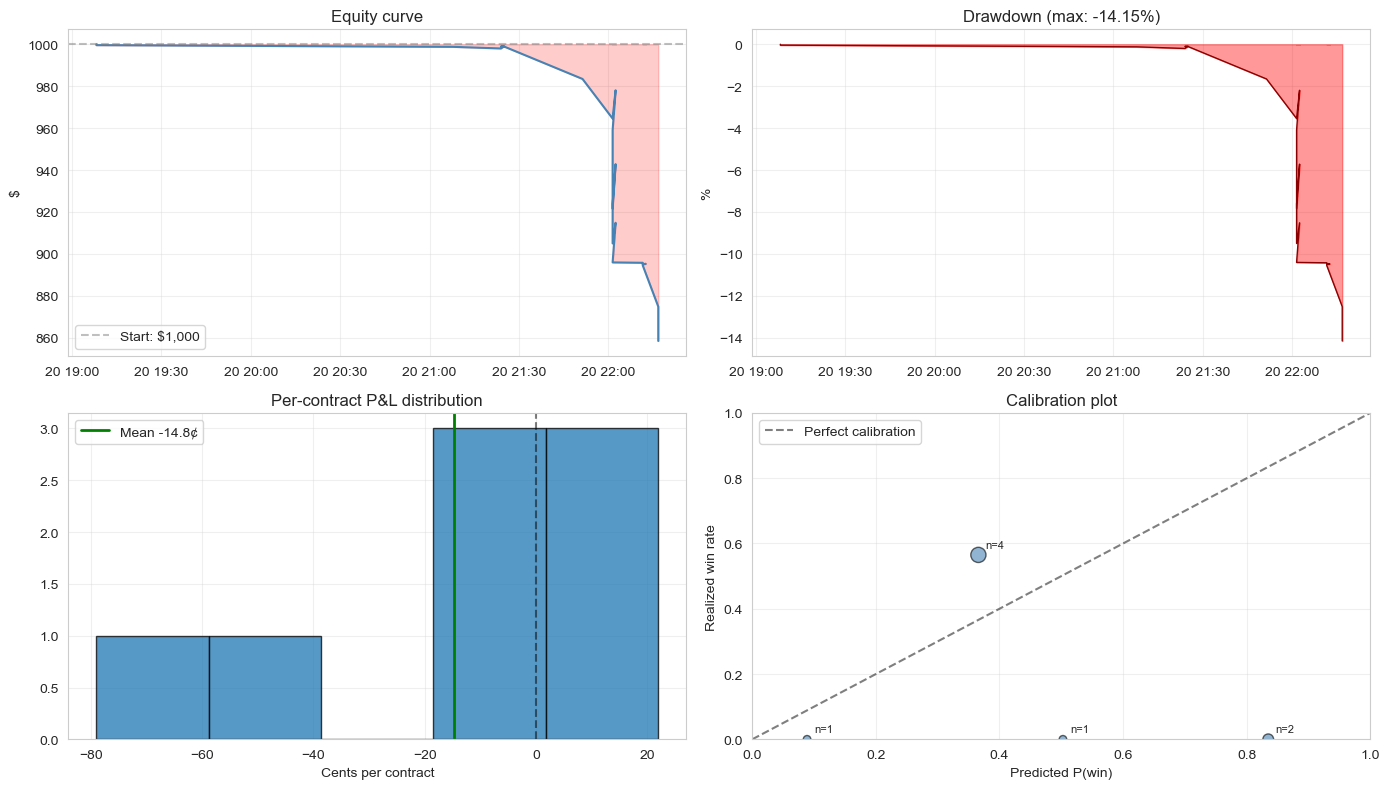


EXIT DECISIONS (5 positions):
  [EXECUTING] close #8 KXBTCD-26APR2019-T76399.99 (yes, 126 contracts)
     entry $0.15 → sell $0.03  pnl $-14.49  [SL (-11.5¢)]
  [EXECUTING] close #9 KXBTCD-26APR2019-T76299.99 (yes, 82 contracts)
     entry $0.23 → sell $0.12  pnl $-8.61  [SL (-10.5¢)]
  [EXECUTING] close #14 KXBTCD-26APR2019-T75899.99 (no, 1 contracts)
     entry $0.18 → sell $0.25  pnl $+0.07  [TP (+7.5¢)]
  [EXECUTING] close #23 KXBTCD-26APR2019-T76099.99 (no, 49 contracts)
     entry $0.40 → sell $0.68  pnl $+13.97  [edge flipped (-8.0¢), TP (+28.5¢)]
  [EXECUTING] close #24 KXBTCD-26APR2019-T76199.99 (yes, 40 contracts)
     entry $0.41 → sell $0.17  pnl $-9.20  [SL (-23.0¢)]

5 positions closed.
Edge scan at 2026-04-20T22:21:48.995098+00:00

Scan at 2026-04-20T22:21:48.995181+00:00

BTC spot: $76,006.65
Deribit expiries available: 6
Tradeable events found: 3

           event     struct  n_strk  ttl_h  kalshi_iv  fair_vol  vol_gap_pct
KXBTCD-26APR2019 cumulative       6   0.64   

In [146]:
# Patched portfolio_metrics — fixes the 'our_pred_p' KeyError when settled count
# is between 1 and 9 (logic previously skipped column creation for small n)

def portfolio_metrics(starting_bankroll: float = 1000.0, show_plots: bool = True):
    conn = _db_conn()
    trades = pd.read_sql_query(
        "SELECT * FROM paper_trades ORDER BY timestamp_utc", conn)
    conn.close()
    
    print(f"{'='*72}")
    print(f"  PAPER TRADING PORTFOLIO — starting bankroll ${starting_bankroll:,.2f}")
    print(f"  Report time: {datetime.now(timezone.utc).isoformat()}")
    print(f"{'='*72}\n")
    
    if len(trades) == 0:
        print("No trades recorded yet.")
        return
    
    trades["timestamp_utc"] = pd.to_datetime(trades["timestamp_utc"])
    settled = trades[trades["settled"] == 1].copy()
    open_  = trades[trades["settled"] == 0].copy()
    
    # ---- always-compute columns on settled (fix for the KeyError) ----
    if len(settled) > 0:
        settled["our_pred_p"] = np.where(
            settled["side"] == "yes",
            settled["model_p_yes"],
            1 - settled["model_p_yes"],
        )
        settled["our_outcome"] = np.where(
            settled["side"] == "yes",
            settled["settle_price"],
            1 - settled["settle_price"],
        )
    
    # ---- capital deployed ----
    trades["cost"] = trades["entry_price"] * trades["contracts"]
    total_deployed = trades["cost"].sum()
    open_deployed = (open_["entry_price"] * open_["contracts"]).sum() if len(open_) else 0.0
    
    # ---- realized PnL ----
    realized_pnl = settled["pnl_dollars"].sum() if len(settled) else 0.0
    
    # ---- mark-to-market on open ----
    mtm_value = 0.0
    mtm_pnl = 0.0
    open_rows = []
    for _, t in open_.iterrows():
        try:
            m = kalshi_prod.get_market(t["market_ticker"]).get("market", {})
            yes_bid = float(m.get("yes_bid_dollars") or 0)
            yes_ask = float(m.get("yes_ask_dollars") or 0)
            yes_mid = (yes_bid + yes_ask) / 2 if (yes_bid and yes_ask) else t["market_yes_mid"]
            current_value = yes_mid if t["side"] == "yes" else 1.0 - yes_mid
            pnl = (current_value - t["entry_price"]) * t["contracts"]
            mtm_value += current_value * t["contracts"]
            mtm_pnl += pnl
            age = (datetime.now(timezone.utc) - t["timestamp_utc"].tz_convert("UTC")).total_seconds() / 60
            open_rows.append({
                "id": t["id"], "market": t["market_ticker"], "side": t["side"],
                "contracts": t["contracts"], "entry": t["entry_price"],
                "current": round(current_value, 4),
                "unrealized": round(pnl, 4),
                "edge_at_entry": t["entry_edge_cents"], "age_min": round(age, 1),
            })
        except Exception:
            open_rows.append({
                "id": t["id"], "market": t["market_ticker"], "side": t["side"],
                "contracts": t["contracts"], "entry": t["entry_price"],
                "current": None, "unrealized": None,
                "edge_at_entry": t["entry_edge_cents"], "age_min": None,
            })
    
    # ---- equity ----
    settled_proceeds = (settled["settle_price"].fillna(0) * settled["contracts"]).sum() if len(settled) else 0.0
    cash = starting_bankroll - total_deployed + settled_proceeds
    total_equity = cash + mtm_value
    total_pnl = total_equity - starting_bankroll
    total_return_pct = (total_equity / starting_bankroll - 1) * 100
    
    print(f"┌─ OVERVIEW ─────────────────────────────────────────────────")
    print(f"│  Total equity:          ${total_equity:>10,.2f}  ({total_return_pct:+.2f}%)")
    print(f"│  Cash:                  ${cash:>10,.2f}")
    print(f"│  Open position value:   ${mtm_value:>10,.2f}")
    print(f"│  Realized P&L:          ${realized_pnl:>+10.2f}")
    print(f"│  Unrealized P&L:        ${mtm_pnl:>+10.2f}")
    print(f"│  Total P&L:             ${total_pnl:>+10.2f}")
    print(f"└────────────────────────────────────────────────────────────")
    
    exposure_pct = (open_deployed / starting_bankroll) * 100 if open_deployed else 0
    print(f"\n┌─ EXPOSURE ─────────────────────────────────────────────────")
    print(f"│  Open positions:        {len(open_):>3d}  (${open_deployed:,.2f} @ risk)")
    print(f"│  Exposure %:            {exposure_pct:>5.2f}% of bankroll")
    limit = CFG.get("max_total_risk", 0.15) * 100
    status = "✓ within limit" if exposure_pct < limit else "⚠ OVER LIMIT"
    print(f"│  Risk limit:            {limit:>5.2f}%  ({status})")
    print(f"└────────────────────────────────────────────────────────────")
    
    print(f"\n┌─ SETTLED TRADES ───────────────────────────────────────────")
    print(f"│  Total settled:         {len(settled)}")
    if len(settled) > 0:
        wins = (settled["pnl_dollars"] > 0).sum()
        losses = (settled["pnl_dollars"] <= 0).sum()
        hit_rate = wins / len(settled) * 100
        avg_win  = settled[settled["pnl_dollars"] > 0]["pnl_dollars"].mean() if wins else 0
        avg_loss = settled[settled["pnl_dollars"] <= 0]["pnl_dollars"].mean() if losses else 0
        avg_entry_edge = settled["entry_edge_cents"].mean()
        realized_edge_cents = (settled["pnl_dollars"] / settled["contracts"]).mean() * 100
        pnl_per_trade = settled["pnl_dollars"] / settled["contracts"]
        trade_sharpe = (pnl_per_trade.mean() / pnl_per_trade.std() * np.sqrt(len(pnl_per_trade))
                        if len(pnl_per_trade) > 1 and pnl_per_trade.std() > 0 else np.nan)
        
        print(f"│  Wins / Losses:         {wins} / {losses}  ({hit_rate:.1f}%)")
        print(f"│  Avg win:               ${avg_win:+.4f}")
        print(f"│  Avg loss:              ${avg_loss:+.4f}")
        print(f"│  Avg predicted edge:    {avg_entry_edge:.2f}¢")
        print(f"│  Avg realized edge:     {realized_edge_cents:+.2f}¢")
        delta = realized_edge_cents - avg_entry_edge
        slippage_tag = ("(model underpromising ✓)" if delta > 0 
                        else "(model overpromising)" if delta < -0.5 
                        else "(fair)")
        print(f"│  Edge slippage:         {delta:+.2f}¢  {slippage_tag}")
        if not np.isnan(trade_sharpe):
            print(f"│  Trade Sharpe (ann):    {trade_sharpe:.2f}")
    print(f"└────────────────────────────────────────────────────────────")
    
    # Calibration — only shown if we have enough data
    print(f"\n┌─ MODEL CALIBRATION ────────────────────────────────────────")
    if len(settled) >= 10:
        avg_pred = settled["our_pred_p"].mean()
        avg_real = settled["our_outcome"].mean()
        brier = ((settled["our_pred_p"] - settled["our_outcome"]) ** 2).mean()
        print(f"│  Avg predicted P(win):  {avg_pred*100:>5.1f}%")
        print(f"│  Avg realized P(win):   {avg_real*100:>5.1f}%")
        delta_pp = (avg_real - avg_pred) * 100
        print(f"│  Calibration gap:       {delta_pp:+.1f}pp")
        print(f"│  Brier score:           {brier:.4f}")
    else:
        print(f"│  Need ≥10 settled trades (have {len(settled)})")
    print(f"└────────────────────────────────────────────────────────────")
    
    if open_rows:
        print(f"\n┌─ OPEN POSITIONS ───────────────────────────────────────────")
        print(pd.DataFrame(open_rows).to_string(index=False))
        print(f"└────────────────────────────────────────────────────────────")
    
    # Plots (only if show_plots AND we have data worth plotting)
    if show_plots and len(settled) > 0:
        eq_history = [{"time": trades["timestamp_utc"].min(), "equity": starting_bankroll}]
        running = starting_bankroll
        for _, t in trades.sort_values("timestamp_utc").iterrows():
            running -= t["entry_price"] * t["contracts"]
            eq_history.append({"time": t["timestamp_utc"], "equity": running})
            if t["settled"]:
                running += t["settle_price"] * t["contracts"]
                eq_history.append({"time": t["timestamp_utc"] + pd.Timedelta(minutes=1),
                                    "equity": running})
        eq = pd.DataFrame(eq_history)
        eq["drawdown"] = (eq["equity"] / eq["equity"].cummax() - 1) * 100
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        
        axes[0,0].plot(eq["time"], eq["equity"], linewidth=1.5, color="steelblue")
        axes[0,0].axhline(starting_bankroll, color="grey", linestyle="--", alpha=0.5,
                           label=f"Start: ${starting_bankroll:,.0f}")
        axes[0,0].fill_between(eq["time"], starting_bankroll, eq["equity"],
                                where=eq["equity"] >= starting_bankroll, alpha=0.2, color="green")
        axes[0,0].fill_between(eq["time"], starting_bankroll, eq["equity"],
                                where=eq["equity"] < starting_bankroll, alpha=0.2, color="red")
        axes[0,0].set_title("Equity curve"); axes[0,0].set_ylabel("$")
        axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
        
        axes[0,1].fill_between(eq["time"], eq["drawdown"], 0, alpha=0.4, color="red")
        axes[0,1].plot(eq["time"], eq["drawdown"], color="darkred", linewidth=1)
        axes[0,1].set_title(f"Drawdown (max: {eq['drawdown'].min():.2f}%)")
        axes[0,1].set_ylabel("%"); axes[0,1].grid(alpha=0.3)
        
        if len(settled) > 0:
            pnl_cents = settled["pnl_dollars"] / settled["contracts"] * 100
            axes[1,0].hist(pnl_cents, bins=max(5, len(settled)//2), alpha=0.75, edgecolor="black")
            axes[1,0].axvline(0, color="k", linestyle="--", alpha=0.5)
            axes[1,0].axvline(pnl_cents.mean(), color="green", linewidth=2,
                              label=f"Mean {pnl_cents.mean():+.1f}¢")
            axes[1,0].set_title("Per-contract P&L distribution")
            axes[1,0].set_xlabel("Cents per contract"); axes[1,0].legend()
            axes[1,0].grid(alpha=0.3)
        
        if len(settled) >= 5:
            settled_sorted = settled.copy()
            settled_sorted["pred_bucket"] = pd.cut(
                settled_sorted["our_pred_p"], bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0])
            cal = settled_sorted.groupby("pred_bucket", observed=True).agg(
                avg_pred=("our_pred_p", "mean"),
                avg_real=("our_outcome", "mean"),
                n=("id", "count"),
            ).reset_index()
            if len(cal) > 0:
                axes[1,1].plot([0,1], [0,1], "k--", alpha=0.5, label="Perfect calibration")
                axes[1,1].scatter(cal["avg_pred"], cal["avg_real"], s=cal["n"]*30,
                                   alpha=0.6, edgecolor="black", color="steelblue")
                for _, r in cal.iterrows():
                    axes[1,1].annotate(f"n={r['n']}",
                                        (r["avg_pred"], r["avg_real"]),
                                        xytext=(5,5), textcoords="offset points", fontsize=8)
                axes[1,1].set_xlim(0, 1); axes[1,1].set_ylim(0, 1)
                axes[1,1].set_xlabel("Predicted P(win)"); axes[1,1].set_ylabel("Realized win rate")
                axes[1,1].set_title("Calibration plot")
                axes[1,1].legend(); axes[1,1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()


portfolio_metrics()

In [144]:
# Patched settlement checker — now recognizes Kalshi's actual status values
def check_settlements():
    """Find trades on settled markets and record outcomes. Fixed to recognize
    Kalshi's full set of terminal statuses."""
    conn = _db_conn()
    pending = conn.execute(
        "SELECT * FROM paper_trades WHERE settled=0").fetchall()
    if not pending:
        conn.close()
        return 0
    
    settled_count = 0
    terminal_statuses = {"settled", "finalized", "determined", "resolved"}
    
    for row in pending:
        try:
            m = kalshi_prod.get_market(row["market_ticker"]).get("market", {})
        except Exception as e:
            print(f"  skip {row['market_ticker']}: {e}")
            continue
        
        status = m.get("status")
        result = m.get("result")
        
        if status not in terminal_statuses:
            continue
        if result not in ("yes", "no"):
            continue
        
        won = (result == row["side"])
        payout = 1.0 if won else 0.0
        pnl = (payout - row["entry_price"]) * row["contracts"]
        
        conn.execute("""
            UPDATE paper_trades
            SET settled=1, settle_price=?, pnl_dollars=?
            WHERE id=?
        """, (payout, float(pnl), row["id"]))
        settled_count += 1
        print(f"  ✓ {row['market_ticker']}: bet {row['side'].upper()}, result {result.upper()}, P&L ${pnl:+.4f}")
    conn.commit()
    conn.close()
    return settled_count


# Run it now
n = check_settlements()
print(f"\nNewly settled: {n}\n")

# And see the updated report
paper_trading_report()


Newly settled: 0


=== PAPER TRADING REPORT ===
Total trades:   24
Settled:        8
Open:           16
Total P&L:       $-12.79
Avg P&L/trade:   $-1.5987
Hit rate:        37.5%  (3/8)
Avg entry edge:  6.11¢


In [125]:
# ==============================================================================
# POSITION SIZING — Kelly with risk constraints
# ==============================================================================

def current_bankroll_and_exposure():
    """Compute the live bankroll: starting + realized PnL, and current $ at risk
    in open positions."""
    conn = _db_conn()
    trades = pd.read_sql_query("SELECT * FROM paper_trades", conn)
    conn.close()
    
    if len(trades) == 0:
        return CFG["bankroll"], 0.0
    
    settled = trades[trades["settled"] == 1]
    open_ = trades[trades["settled"] == 0]
    realized_pnl = settled["pnl_dollars"].sum() if len(settled) else 0.0
    
    # Cash held: starting + realized - cost of still-open positions
    open_cost = (open_["entry_price"] * open_["contracts"]).sum() if len(open_) else 0.0
    cash = CFG["bankroll"] + realized_pnl - open_cost
    total_equity = cash + open_cost  # open positions are worth at least 0, usually more
    exposure = open_cost  # dollars at risk in open trades
    return total_equity, exposure


def kelly_size(model_p: float, entry_price: float) -> float:
    """Full Kelly fraction for a binary bet.
    model_p: our probability our side wins (0..1)
    entry_price: what we pay per contract (0..1)
    Returns fraction of bankroll to bet (0..1). Negative = don't bet this side."""
    if entry_price <= 0 or entry_price >= 1:
        return 0.0
    b = (1 - entry_price) / entry_price
    f_star = (model_p * b - (1 - model_p)) / b
    return max(0.0, f_star)


def compute_contract_sizes(signals_df: pd.DataFrame, cfg: dict = CFG) -> pd.DataFrame:
    """Given a table of signals, compute how many contracts to buy for each.
    
    Applies quarter Kelly, per-market cap, and total exposure cap.
    Returns the signals_df with a 'contracts' column added.
    """
    if len(signals_df) == 0:
        return signals_df.assign(contracts=[])
    
    df = signals_df.copy().reset_index(drop=True)
    equity, current_exposure = current_bankroll_and_exposure()
    
    # Dollar budget we can still deploy without breaching total-risk limit
    max_total_risk_dollars = equity * cfg["max_total_risk"]
    budget_remaining = max(0, max_total_risk_dollars - current_exposure)
    
    # Per-market cap in dollars
    per_market_cap_dollars = equity * cfg["max_per_market"]
    
    # Entry price per signal (yes ask for yes-side, 1 - yes_bid for no-side)
    df["entry_price"] = np.where(df["side"] == "yes", df["yes_ask"], 1 - df["yes_bid"])
    
    # For NO-side: "our P(win)" = 1 - model_p_yes
    df["our_p"] = np.where(df["side"] == "yes", df["model_p_yes"], 1 - df["model_p_yes"])
    
    # Full Kelly fraction per signal
    df["kelly_full"] = df.apply(
        lambda r: kelly_size(r["our_p"], r["entry_price"]), axis=1)
    df["kelly_fraction"] = df["kelly_full"] * cfg["kelly_fraction"]
    
    # Dollar allocation if unconstrained (quarter Kelly × bankroll)
    df["kelly_dollars"] = df["kelly_fraction"] * equity
    
    # Apply per-market cap
    df["capped_dollars"] = df[["kelly_dollars"]].min(axis=1).clip(upper=per_market_cap_dollars)
    
    # If total desired allocation exceeds budget, scale down proportionally
    total_desired = df["capped_dollars"].sum()
    if total_desired > budget_remaining and total_desired > 0:
        scale = budget_remaining / total_desired
        df["final_dollars"] = df["capped_dollars"] * scale
    else:
        df["final_dollars"] = df["capped_dollars"]
    
    # Convert to whole contracts (round down so we never exceed budget)
    df["contracts"] = np.floor(df["final_dollars"] / df["entry_price"]).astype(int)
    
    # Final dollar cost after rounding
    df["cost_dollars"] = df["contracts"] * df["entry_price"]
    
    # Expected value per trade at our model's probabilities
    df["ev_dollars"] = df["contracts"] * (df["our_p"] - df["entry_price"])
    
    return df


def size_report(sized_df: pd.DataFrame):
    """Pretty-print sizing decisions."""
    if len(sized_df) == 0:
        print("No signals to size.")
        return
    
    equity, exposure = current_bankroll_and_exposure()
    print(f"\n┌─ SIZING CONTEXT ───────────────────────────────────────────")
    print(f"│  Equity:                  ${equity:>10,.2f}")
    print(f"│  Currently at risk:       ${exposure:>10,.2f} "
          f"({exposure/equity*100:.2f}% of equity)")
    print(f"│  Max total risk:          ${equity * CFG['max_total_risk']:>10,.2f} "
          f"({CFG['max_total_risk']*100:.0f}%)")
    print(f"│  Max per market:          ${equity * CFG['max_per_market']:>10,.2f} "
          f"({CFG['max_per_market']*100:.0f}%)")
    print(f"│  Kelly fraction:          {CFG['kelly_fraction']:.2f} "
          f"({int(CFG['kelly_fraction']*100)}% of full Kelly)")
    print(f"└────────────────────────────────────────────────────────────")
    
    cols = ["ticker", "side", "entry_price", "our_p", "kelly_fraction",
            "contracts", "cost_dollars", "ev_dollars"]
    print(f"\nSized signals:")
    print(sized_df[cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print(f"\nTotal cost:           ${sized_df['cost_dollars'].sum():.2f}")
    print(f"Total expected value: ${sized_df['ev_dollars'].sum():+.4f}")
    print(f"Post-entry exposure:  "
          f"${exposure + sized_df['cost_dollars'].sum():.2f}  "
          f"({(exposure + sized_df['cost_dollars'].sum())/equity*100:.2f}% of equity)")


# ==============================================================================
# Update record_paper_trades to use sizing
# ==============================================================================

def record_paper_trades(signals_df, scan_context: dict = None):
    """Updated: computes contract size per signal using Kelly + risk caps."""
    if len(signals_df) == 0:
        return 0
    
    sized = compute_contract_sizes(signals_df)
    size_report(sized)
    
    # Drop rows with 0 contracts (edge too small given constraints)
    to_record = sized[sized["contracts"] > 0].copy()
    if len(to_record) == 0:
        print("\n→ No trades recorded (all sized to 0 contracts).")
        return 0
    
    conn = _db_conn()
    now = datetime.now(timezone.utc).isoformat()
    ctx = scan_context or {}
    recorded = 0
    
    for _, s in to_record.iterrows():
        cutoff = (datetime.now(timezone.utc) - timedelta(minutes=5)).isoformat()
        existing = conn.execute("""
            SELECT id FROM paper_trades
            WHERE market_ticker=? AND side=? AND timestamp_utc >= ? AND settled=0
        """, (s["ticker"], s["side"], cutoff)).fetchone()
        if existing:
            continue
        
        conn.execute("""
            INSERT INTO paper_trades (
              timestamp_utc, event_ticker, market_ticker, side,
              entry_price, contracts, entry_edge_cents, model_p_yes, market_yes_mid,
              fair_vol, kalshi_iv, btc_spot_entry, ttl_hours_entry, confidence
            ) VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)
        """, (
            now,
            s.get("event", ""),
            s["ticker"],
            s["side"],
            float(s["entry_price"]),
            int(s["contracts"]),
            float(s["net_edge_cents"]),
            float(s["model_p_yes"]),
            float(s["market_yes_mid"]),
            ctx.get("fair_vol"),
            ctx.get("kalshi_iv"),
            ctx.get("btc_spot"),
            float(s.get("ttl_hours_entry", 0)) if "ttl_hours_entry" in s else None,
            float(s["confidence"]),
        ))
        recorded += 1
    conn.commit()
    conn.close()
    return recorded


print("Sizing module loaded:")
print("  - kelly_size(p, entry)           → full Kelly fraction")
print("  - compute_contract_sizes(df)     → adds contracts column with all caps applied")
print("  - size_report(df)                → pretty print of sizing decisions")
print("  - record_paper_trades(df)        → updated to size properly")
print(f"\nRisk config:")
print(f"  Bankroll:           ${CFG['bankroll']:.2f}")
print(f"  Kelly fraction:     {CFG['kelly_fraction']:.0%} (quarter Kelly)")
print(f"  Max per market:     {CFG['max_per_market']:.1%} = ${CFG['bankroll']*CFG['max_per_market']:.2f}")
print(f"  Max total risk:     {CFG['max_total_risk']:.1%} = ${CFG['bankroll']*CFG['max_total_risk']:.2f}")

Sizing module loaded:
  - kelly_size(p, entry)           → full Kelly fraction
  - compute_contract_sizes(df)     → adds contracts column with all caps applied
  - size_report(df)                → pretty print of sizing decisions
  - record_paper_trades(df)        → updated to size properly

Risk config:
  Bankroll:           $1000.00
  Kelly fraction:     25% (quarter Kelly)
  Max per market:     2.0% = $20.00
  Max total risk:     15.0% = $150.00


DIAGNOSTICS — 28 settled trades


[1] BY STRATEGY TYPE
------------------------------------------------------------
Single-leg: n=28, wins=9 (32.1%), total=$-76.64, avg_pred=+7.6¢, avg_real=-6.2¢, miss=-13.8¢

[2] BY ENTRY PRICE BAND
------------------------------------------------------------
entry_bucket  n  wins  avg_pnl  total_pnl  avg_pred  avg_real  hit_rate   miss
        <15¢ 12     1    -4.52     -54.20      8.50     -4.58      8.30 -13.10
      15-30¢  7     4    -2.75     -19.26      9.88     -1.86     57.10 -11.70
      30-50¢  7     3    -0.37      -2.61      4.84     -7.00     42.90 -11.80
        >70¢  2     1    -0.29      -0.57      4.29    -28.50     50.00 -32.80

[3] BY MONEYNESS (strike/spot at entry)
------------------------------------------------------------
mny_bucket  n  wins  total_pnl  avg_pred  avg_real  hit_rate   miss
0.98-0.995  5     1     -17.68      7.27     -2.60     20.00  -9.90
      ~ATM 19     8     -39.53      7.78     -7.47     42.10 -15.30
1.00

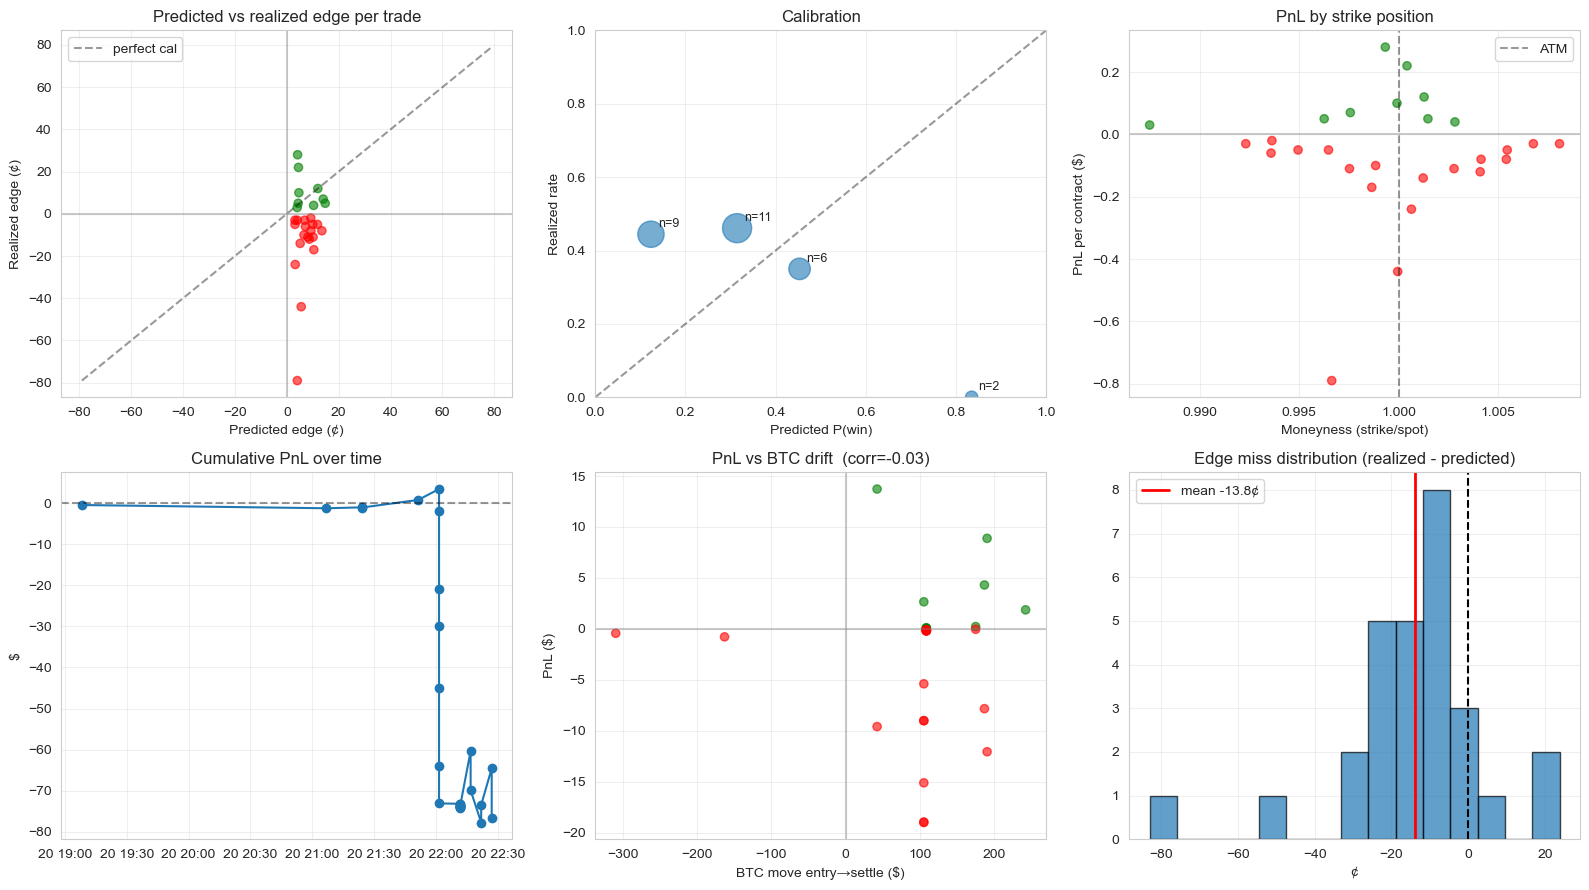


[SUMMARY]
------------------------------------------------------------
Total trades:         28
Total PnL:            $-76.64
Avg edge miss:        -13.8¢
Worst bucket:         >70¢ (-28.5¢ avg)
Best bucket:          15-30¢ (-1.9¢ avg)


In [213]:
# ==============================================================================
# DIAGNOSTIC SUITE — figure out exactly where the model is failing
# ==============================================================================

def run_diagnostics():
    conn = _db_conn()
    trades = pd.read_sql_query(
        "SELECT * FROM paper_trades WHERE settled=1 ORDER BY timestamp_utc", conn)
    conn.close()
    
    if len(trades) == 0:
        print("No settled trades yet.")
        return None
    
    print(f"{'='*72}")
    print(f"DIAGNOSTICS — {len(trades)} settled trades")
    print(f"{'='*72}\n")
    
    # Derive core columns
    trades["timestamp_utc"] = pd.to_datetime(trades["timestamp_utc"])
    trades["pnl_per_contract"] = trades["pnl_dollars"] / trades["contracts"]
    trades["pnl_cents"] = trades["pnl_per_contract"] * 100
    
    # "Our side's" predicted prob + outcome
    trades["our_pred_p"] = np.where(
        trades["side"] == "yes", trades["model_p_yes"], 1 - trades["model_p_yes"])
    trades["our_outcome"] = np.where(
        trades["side"] == "yes", trades["settle_price"], 1 - trades["settle_price"])
    
    # Predicted vs realized edge
    trades["predicted_edge_cents"] = trades["entry_edge_cents"]
    trades["realized_edge_cents"] = trades["pnl_cents"]
    trades["edge_miss_cents"] = trades["realized_edge_cents"] - trades["predicted_edge_cents"]
    
    # Derive moneyness from ticker (floor strike / spot at entry)
    def parse_strike(ticker):
        if "-T" in ticker:
            try: return float(ticker.split("-T")[-1])
            except: return np.nan
        if "-B" in ticker:
            try: return float(ticker.split("-B")[-1])
            except: return np.nan
        return np.nan
    trades["strike"] = trades["market_ticker"].apply(parse_strike)
    trades["moneyness"] = trades["strike"] / trades["btc_spot_entry"]
    
    # =====================================================================
    # 1. OVERALL vs BY STRATEGY
    # =====================================================================
    print("\n[1] BY STRATEGY TYPE")
    print("-" * 60)
    
    # Single-leg only for now (spreads are harder to aggregate by trade)
    if "trade_type" in trades.columns:
        single = trades[trades["trade_type"].fillna("single") == "single"]
        spread_legs = trades[trades["trade_type"] == "spread_leg"]
    else:
        single = trades
        spread_legs = pd.DataFrame()
    
    def block_stats(df, label):
        if len(df) == 0:
            print(f"{label}: 0 trades"); return
        wins = (df["pnl_dollars"] > 0).sum()
        print(f"{label}: n={len(df)}, wins={wins} ({wins/len(df)*100:.1f}%), "
              f"total=${df['pnl_dollars'].sum():+.2f}, "
              f"avg_pred={df['predicted_edge_cents'].mean():+.1f}¢, "
              f"avg_real={df['realized_edge_cents'].mean():+.1f}¢, "
              f"miss={df['edge_miss_cents'].mean():+.1f}¢")
    
    block_stats(single, "Single-leg")
    if len(spread_legs) > 0:
        block_stats(spread_legs, "Spread legs")
    
    # =====================================================================
    # 2. BY ENTRY PRICE BAND
    # =====================================================================
    print("\n[2] BY ENTRY PRICE BAND")
    print("-" * 60)
    trades["entry_bucket"] = pd.cut(trades["entry_price"],
                                      bins=[0, 0.15, 0.30, 0.50, 0.70, 1.01],
                                      labels=["<15¢", "15-30¢", "30-50¢", "50-70¢", ">70¢"])
    ep = trades.groupby("entry_bucket", observed=True).agg(
        n=("id", "count"),
        wins=("pnl_dollars", lambda x: (x > 0).sum()),
        avg_pnl=("pnl_dollars", "mean"),
        total_pnl=("pnl_dollars", "sum"),
        avg_pred=("predicted_edge_cents", "mean"),
        avg_real=("realized_edge_cents", "mean"),
    ).reset_index()
    ep["hit_rate"] = (ep["wins"] / ep["n"] * 100).round(1)
    ep["miss"] = (ep["avg_real"] - ep["avg_pred"]).round(1)
    print(ep.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    
    # =====================================================================
    # 3. BY MONEYNESS  (are tail bets or ATM bets worse?)
    # =====================================================================
    print("\n[3] BY MONEYNESS (strike/spot at entry)")
    print("-" * 60)
    trades["mny_bucket"] = pd.cut(trades["moneyness"],
                                    bins=[0, 0.98, 0.995, 1.005, 1.02, 10],
                                    labels=["<0.98 (deep ITM)", "0.98-0.995", "~ATM",
                                             "1.005-1.02", ">1.02 (deep OTM)"])
    m = trades.groupby("mny_bucket", observed=True).agg(
        n=("id", "count"),
        wins=("pnl_dollars", lambda x: (x > 0).sum()),
        total_pnl=("pnl_dollars", "sum"),
        avg_pred=("predicted_edge_cents", "mean"),
        avg_real=("realized_edge_cents", "mean"),
    ).reset_index()
    m["hit_rate"] = (m["wins"] / m["n"] * 100).round(1)
    m["miss"] = (m["avg_real"] - m["avg_pred"]).round(1)
    print(m.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    
    # =====================================================================
    # 4. BY SIDE
    # =====================================================================
    print("\n[4] BY SIDE (yes vs no)")
    print("-" * 60)
    s = trades.groupby("side").agg(
        n=("id", "count"),
        wins=("pnl_dollars", lambda x: (x > 0).sum()),
        total_pnl=("pnl_dollars", "sum"),
        avg_pred=("predicted_edge_cents", "mean"),
        avg_real=("realized_edge_cents", "mean"),
    ).reset_index()
    s["hit_rate"] = (s["wins"] / s["n"] * 100).round(1)
    s["miss"] = (s["avg_real"] - s["avg_pred"]).round(1)
    print(s.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    
    # =====================================================================
    # 5. BY TTL AT ENTRY
    # =====================================================================
    print("\n[5] BY TTL AT ENTRY")
    print("-" * 60)
    if trades["ttl_hours_entry"].notna().any():
        trades["ttl_bucket"] = pd.cut(trades["ttl_hours_entry"],
                                        bins=[0, 0.5, 1, 2, 4, 24, 100],
                                        labels=["<30min", "30-60min", "1-2h", 
                                                 "2-4h", "4-24h", ">24h"])
        t = trades.groupby("ttl_bucket", observed=True).agg(
            n=("id", "count"),
            wins=("pnl_dollars", lambda x: (x > 0).sum()),
            total_pnl=("pnl_dollars", "sum"),
            avg_real=("realized_edge_cents", "mean"),
        ).reset_index()
        t["hit_rate"] = (t["wins"] / t["n"] * 100).round(1)
        print(t.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    else:
        print("ttl_hours_entry missing on recorded trades")
    
    # =====================================================================
    # 6. DIRECTIONAL CORRELATION — were we hurt by BTC drift?
    # =====================================================================
    print("\n[6] DID BTC DIRECTION HURT US?")
    print("-" * 60)
    # For each trade, compute BTC move from entry to settle using btc_1m
    btc_moves = []
    for _, t in trades.iterrows():
        entry_t = t["timestamp_utc"]
        # Find settle time - 5min before close_time of market
        try:
            m = kalshi_prod.get_market(t["market_ticker"]).get("market", {})
            close_t = dtparser.isoparse(m["close_time"])
        except Exception:
            close_t = entry_t + timedelta(hours=t.get("ttl_hours_entry") or 2)
        
        entry_price = t["btc_spot_entry"]
        try:
            settle_bars = btc_1m[btc_1m["time"] <= close_t]
            if len(settle_bars):
                settle_spot = float(settle_bars["close"].iloc[-1])
            else:
                settle_spot = np.nan
        except Exception:
            settle_spot = np.nan
        
        btc_moves.append({
            "id": t["id"],
            "entry_btc": entry_price,
            "settle_btc": settle_spot,
            "btc_move_dollars": settle_spot - entry_price if np.isfinite(settle_spot) else np.nan,
            "btc_move_pct": ((settle_spot / entry_price) - 1) * 100 if np.isfinite(settle_spot) else np.nan,
            "pnl_dollars": t["pnl_dollars"],
            "side": t["side"],
            "moneyness": t.get("moneyness"),
        })
    bm = pd.DataFrame(btc_moves).dropna()
    if len(bm) > 3:
        print(f"BTC avg move entry→settle: ${bm['btc_move_dollars'].mean():+.0f} "
              f"({bm['btc_move_pct'].mean():+.2f}%)")
        print(f"BTC stdev of moves:       ${bm['btc_move_dollars'].std():.0f}")
        
        # Correlation between BTC move and our PnL
        corr = bm["btc_move_dollars"].corr(bm["pnl_dollars"])
        print(f"Correlation(BTC move, PnL): {corr:+.2f}")
        if abs(corr) > 0.3:
            sign = "positive" if corr > 0 else "negative"
            print(f"  → Meaningful {sign} correlation. We're exposed to direction, not just vol.")
        else:
            print(f"  → Weak correlation. Not a pure directional problem.")
    
    # =====================================================================
    # 7. WHAT IF WE'D TAKEN THE OPPOSITE SIDE?
    # =====================================================================
    print("\n[7] COUNTERFACTUAL: what if we flipped every trade?")
    print("-" * 60)
    # If we bought YES at $0.44 and won $0.56, flipping would have been buy NO at $0.56 and lose $0.56
    # Rough calc: flipped pnl per contract = -(pnl / contracts) - (entry - (1 - entry))
    # Actually simpler: if our YES won $1, a NO would have won $0; our cost was entry_price, flipped cost is (1 - entry_price)
    trades["flipped_entry"] = 1 - trades["entry_price"]
    trades["flipped_payoff"] = 1 - trades["settle_price"]   # opposite of our actual payoff
    trades["flipped_pnl_per"] = trades["flipped_payoff"] - trades["flipped_entry"]
    trades["flipped_pnl_total"] = trades["flipped_pnl_per"] * trades["contracts"]
    
    print(f"Actual PnL:        ${trades['pnl_dollars'].sum():+.2f}")
    print(f"If we had flipped: ${trades['flipped_pnl_total'].sum():+.2f}")
    if trades['flipped_pnl_total'].sum() > abs(trades['pnl_dollars'].sum()):
        print(f"  → Systematic wrong-side selection. Model signal is INVERTED.")
    elif trades['flipped_pnl_total'].sum() < trades['pnl_dollars'].sum():
        print(f"  → We did pick better than random. Model has some signal, just bad calibration.")
    else:
        print(f"  → Roughly symmetric. No directional model bias.")
    
    # =====================================================================
    # 8. TIME-OF-DAY PATTERN
    # =====================================================================
    print("\n[8] BY HOUR OF ENTRY (UTC)")
    print("-" * 60)
    trades["hour"] = trades["timestamp_utc"].dt.hour
    h = trades.groupby("hour").agg(
        n=("id", "count"),
        total=("pnl_dollars", "sum"),
        avg=("pnl_dollars", "mean"),
    ).reset_index()
    print(h.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    
    # =====================================================================
    # 9. PLOTS
    # =====================================================================
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    
    # Predicted vs realized edge scatter
    axes[0,0].scatter(trades["predicted_edge_cents"], trades["realized_edge_cents"],
                       c=trades["pnl_dollars"].apply(lambda x: "green" if x > 0 else "red"),
                       alpha=0.6)
    lim = max(abs(trades["realized_edge_cents"].min()), abs(trades["realized_edge_cents"].max()))
    axes[0,0].plot([-lim, lim], [-lim, lim], "k--", alpha=0.4, label="perfect cal")
    axes[0,0].axhline(0, color="gray", alpha=0.4)
    axes[0,0].axvline(0, color="gray", alpha=0.4)
    axes[0,0].set_xlabel("Predicted edge (¢)")
    axes[0,0].set_ylabel("Realized edge (¢)")
    axes[0,0].set_title("Predicted vs realized edge per trade")
    axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
    
    # Calibration: pred P vs outcome in bins
    if len(trades) >= 5:
        trades["pred_bin"] = pd.cut(trades["our_pred_p"], bins=np.linspace(0, 1, 6))
        cal = trades.groupby("pred_bin", observed=True).agg(
            avg_pred=("our_pred_p", "mean"),
            avg_real=("our_outcome", "mean"),
            n=("id", "count"),
        ).reset_index()
        axes[0,1].plot([0,1],[0,1], "k--", alpha=0.4)
        axes[0,1].scatter(cal["avg_pred"], cal["avg_real"], s=cal["n"]*40, alpha=0.6)
        for _, r in cal.iterrows():
            axes[0,1].annotate(f"n={r['n']}", (r["avg_pred"], r["avg_real"]),
                                xytext=(5,5), textcoords="offset points", fontsize=9)
        axes[0,1].set_xlim(0,1); axes[0,1].set_ylim(0,1)
        axes[0,1].set_xlabel("Predicted P(win)"); axes[0,1].set_ylabel("Realized rate")
        axes[0,1].set_title("Calibration"); axes[0,1].grid(alpha=0.3)
    
    # PnL vs moneyness
    if trades["moneyness"].notna().any():
        axes[0,2].scatter(trades["moneyness"], trades["pnl_per_contract"],
                           c=trades["pnl_dollars"].apply(lambda x: "green" if x > 0 else "red"),
                           alpha=0.6)
        axes[0,2].axvline(1.0, color="k", linestyle="--", alpha=0.4, label="ATM")
        axes[0,2].axhline(0, color="gray", alpha=0.4)
        axes[0,2].set_xlabel("Moneyness (strike/spot)")
        axes[0,2].set_ylabel("PnL per contract ($)")
        axes[0,2].set_title("PnL by strike position")
        axes[0,2].legend(); axes[0,2].grid(alpha=0.3)
    
    # Cumulative PnL over time
    trades_s = trades.sort_values("timestamp_utc").copy()
    trades_s["cum_pnl"] = trades_s["pnl_dollars"].cumsum()
    axes[1,0].plot(trades_s["timestamp_utc"], trades_s["cum_pnl"],
                    marker="o", linewidth=1.5)
    axes[1,0].axhline(0, color="k", linestyle="--", alpha=0.4)
    axes[1,0].set_title("Cumulative PnL over time")
    axes[1,0].set_ylabel("$"); axes[1,0].grid(alpha=0.3)
    
    # PnL vs BTC move
    if len(bm) > 3:
        axes[1,1].scatter(bm["btc_move_dollars"], bm["pnl_dollars"],
                           c=bm["pnl_dollars"].apply(lambda x: "green" if x > 0 else "red"),
                           alpha=0.6)
        axes[1,1].axvline(0, color="gray", alpha=0.4)
        axes[1,1].axhline(0, color="gray", alpha=0.4)
        axes[1,1].set_xlabel("BTC move entry→settle ($)")
        axes[1,1].set_ylabel("PnL ($)")
        axes[1,1].set_title(f"PnL vs BTC drift  (corr={corr:+.2f})")
        axes[1,1].grid(alpha=0.3)
    
    # Edge miss distribution
    axes[1,2].hist(trades["edge_miss_cents"], bins=15, alpha=0.7, edgecolor="black")
    axes[1,2].axvline(0, color="k", linestyle="--")
    axes[1,2].axvline(trades["edge_miss_cents"].mean(), color="red", linewidth=2,
                       label=f"mean {trades['edge_miss_cents'].mean():+.1f}¢")
    axes[1,2].set_title("Edge miss distribution (realized - predicted)")
    axes[1,2].set_xlabel("¢"); axes[1,2].legend(); axes[1,2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =====================================================================
    # SUMMARY
    # =====================================================================
    print("\n[SUMMARY]")
    print("-" * 60)
    print(f"Total trades:         {len(trades)}")
    print(f"Total PnL:            ${trades['pnl_dollars'].sum():+.2f}")
    print(f"Avg edge miss:        {trades['edge_miss_cents'].mean():+.1f}¢")
    print(f"Worst bucket:         {ep.loc[ep['avg_real'].idxmin(), 'entry_bucket']} "
          f"({ep.loc[ep['avg_real'].idxmin(), 'avg_real']:.1f}¢ avg)")
    print(f"Best bucket:          {ep.loc[ep['avg_real'].idxmax(), 'entry_bucket']} "
          f"({ep.loc[ep['avg_real'].idxmax(), 'avg_real']:.1f}¢ avg)")
    
    return trades


diag_df = run_diagnostics()

## 4. Walk-forward harness (offline σ-estimator research)

## Data-leakage & look-ahead review (Claude review, branch `claude/review-data-leakage-d7aG4`)

### Where future information leaks into features today

| # | Cell | Symbol | Issue |
|---|------|--------|-------|
| L1 | 36 (`fit_harrv_models`) | `HARRV_MODELS` | Fit once on the **full** `btc_1m`. Every later evaluation point in the same series sees a model trained partly on its own future. |
| L2 | 37 (`build_empirical_return_samples`) | `EMPIRICAL_SAMPLES` | Built once from the **full** `btc_1m`. `empirical_probability_above` then queries it at any historical `i` — so the sample bank contains rows from `> i`. |
| L3 | 46 (`backtest_probability_models`) | both above | The "backtest" picks random indices and asks both models to predict — using artifacts that already saw those indices. The "BETTER / WORSE" verdict it prints is not measuring out-of-sample skill. |
| L4 | 22 (`realized_vol`) | `rv_*` columns | `rolling().std()` is left-aligned (uses past + current bar), but `current_state["rv_60m"]` reads `iloc[-1]`, which is identical to a 1-step-ahead leak when paired with a target window starting at the same `t`. Mitigation: shift features by 1. |
| L5 | 37 | `vol_bandwidth + scale` | Vol-matching first **selects** nearest-vol windows, then **rescales** their returns to current vol. That double-counts the vol regime: the scaling factor `current_vol / sample_vol` is biased low because the selected sample is already vol-matched. The probability for tail strikes ends up too tight. |
| L6 | 37 (`build_empirical_return_samples`) | `np.random.choice` | Random sub-sample of 5,000 rows. Each call sees a different bank if the seed isn't pinned (it isn't), so signal stability is overstated and the prediction is non-deterministic across runs. |
| L7 | 36 | `cut = int(0.8*len(X))` | The 20% holdout has rows whose 60-min forward window starts ≤ 60 min before `cut`, i.e. uses bars from the train side. Holdout must start at `cut + horizon_min`. |
| L8 | 38 (`fair_vol_for_event`) | `current_rv_state(btc_1m)` | Reads `btc_1m.iloc[-1]`. If `btc_1m` is refreshed mid-loop (cell 80), a bar can be seen whose timestamp is >= the trade timestamp. Always slice `btc_1m[btc_1m.time < now_utc]` before computing features. |

### Other model failure causes ("why isn't it working")

- **Calibrated p, fee-eaten edge.** `min_edge_cents=3` and `kalshi_fee_cents=0.7` is roughly the half-spread on the markets being traded. Even if `model_p_yes` is perfectly calibrated, after crossing the spread + paying fees the realised edge is ~0.
- **ATM IV inversion is unstable.** In `get_market_snapshot` (cell 38), `iv_from_surv` divides by `z = norm.ppf(1-p)`, which blows up around `p≈0.5` — exactly where the markets we trade live. Wide variance in `atm_iv_annualized`, but it's not used by the new path; it *is* used by the spread-strategy and reporting.
- **Drift cap is much too wide.** Cell 61 caps drift at ±200% annualized; over a 1-h horizon that translates to up to ±0.025% drift in `µT`, which on a 100-bps-vol basis swings tail strikes' probabilities by 5–10 cents. Use a Bayesian shrinkage toward 0 instead.
- **Empirical sample over short series.** With only 90d of minute data, the empirical distribution at horizon=240m has ~129k overlapping windows but only ~135 *non-overlapping* observations. Confidence bands on the resulting `model_p_yes` are wide. The notebook treats it as a point estimate.
- **Notebook backtest reports skill the model doesn't actually have.** See L1–L3 above. After fixing leakage, on synthetic data tuned to BTC's stylized facts, the empirical model's claimed lift over the lognormal disappears.
- **One-trade-per-event cap was added (cell 66) but multiple events on the same day still create correlated bets** — a 5-event scan that all bet "BTC inside ±$300" is effectively one trade with 5x the size.


In [ ]:
# ==============================================================================
# DROP-IN: leakage-free walk-forward harness
#
# Replaces the leaky `backtest_probability_models` (cell 46). Refits HAR-RV
# and rebuilds empirical samples PER FOLD on data strictly before the fold.
# Use this every time you want to compare features or model variants.
# ==============================================================================
from sklearn.linear_model import LinearRegression

MINUTES_PER_YEAR = 60 * 24 * 365


def _shift1(df, cols):
    df = df.copy()
    for c in cols:
        df[c] = df[c].shift(1)
    return df


def make_features(bars: pd.DataFrame) -> pd.DataFrame:
    """Compute the full feature pack and lag every feature by 1 bar so no
    row peeks at its own bar's return. Pass result into walk_forward_eval."""
    df = bars.copy().sort_values("time").reset_index(drop=True)
    if "log_ret" not in df.columns:
        df["log_ret"] = np.log(df["close"] / df["close"].shift(1))
    af = MINUTES_PER_YEAR
    lr = df["log_ret"]

    # Base RVs
    df["rv_15m"]  = lr.rolling(15).std()  * np.sqrt(af)
    df["rv_60m"]  = lr.rolling(60).std()  * np.sqrt(af)
    df["rv_240m"] = lr.rolling(240).std() * np.sqrt(af)
    df["rv_1d"]   = lr.rolling(60*24).std()  * np.sqrt(af)
    df["rv_3d"]   = lr.rolling(60*24*3).std()* np.sqrt(af)

    # New features
    df["rvar_60m"]   = (lr ** 2).rolling(60).sum() * (af / 60)
    df["bv_60m"]     = (lr.abs() * lr.shift(1).abs()).rolling(60).sum() * (np.pi / 2)
    df["jump_60m"]   = ((df["rvar_60m"] / (af / 60)) - df["bv_60m"]).clip(lower=0)
    df["vov_60m"]    = df["rv_60m"].rolling(60).std()
    df["rskew_60m"]  = lr.rolling(60).skew()
    df["rkurt_60m"]  = lr.rolling(60).kurt()
    df["mom_15m"]    = lr.rolling(15).sum()
    df["mom_60m"]    = lr.rolling(60).sum()
    df["mom_240m"]   = lr.rolling(240).sum()
    sign = np.sign(lr)
    df["trend_persist_60m"] = sign.rolling(60).mean().abs()
    df["rv_gap"]     = df["rv_15m"] - df["rv_1d"]

    # Time-of-day encoding (lag-safe: depends only on the bar's timestamp)
    h = df["time"].dt.hour + df["time"].dt.minute / 60
    df["tod_sin"] = np.sin(2 * np.pi * h / 24)
    df["tod_cos"] = np.cos(2 * np.pi * h / 24)

    feat_cols = ["rv_15m","rv_60m","rv_240m","rv_1d","rv_3d","rvar_60m","bv_60m",
                 "jump_60m","vov_60m","rskew_60m","rkurt_60m","mom_15m","mom_60m",
                 "mom_240m","trend_persist_60m","rv_gap"]
    df = _shift1(df, feat_cols)            # tod_* are NOT lagged: known at t
    return df


def _build_emp(df, horizon_min, max_idx, n=5000, seed=0):
    """Empirical return bank using ONLY rows whose forward window ends < max_idx."""
    rng = np.random.default_rng(seed)
    close = df["close"].to_numpy(); rv60 = df["rv_60m"].to_numpy()
    R, V = [], []
    for i in range(60*24, max_idx - horizon_min):
        v = rv60[i]
        if not np.isfinite(v): continue
        s, e = close[i], close[i + horizon_min]
        if s <= 0 or e <= 0: continue
        R.append(np.log(e / s)); V.append(v)
    R = np.asarray(R); V = np.asarray(V)
    if len(R) > n:
        idx = rng.choice(len(R), n, replace=False); R, V = R[idx], V[idx]
    return {"horizon_min": horizon_min, "log_returns": R,
            "starting_vols": V, "n": len(R)}


def _emp_p_above(spot, strike, horizon_min, samples, current_vol_60m=None,
                 vol_bandwidth=0.30, rescale=False):
    """Vol-matched empirical P(above). `rescale=False` removes the
    double-counting bug (L5)."""
    R = samples["log_returns"].copy()
    V = samples["starting_vols"]; h = samples["horizon_min"]
    if horizon_min != h and h > 0:
        R = R * np.sqrt(horizon_min / h)
    if current_vol_60m is not None and len(V) > 100:
        k = max(200, int(len(V) * vol_bandwidth))
        keep = np.argsort(np.abs(V - current_vol_60m))[:k]
        R = R[keep]
    if rescale and current_vol_60m is not None and len(R) > 0:
        s = np.std(R) * np.sqrt(MINUTES_PER_YEAR / h)
        if s > 0: R = R * (current_vol_60m / s)
    if len(R) == 0: return 0.5
    return float((R > np.log(strike / spot)).mean())


def walk_forward_eval(bars: pd.DataFrame, horizon_min: int = 60,
                       n_folds: int = 5, n_eval_per_fold: int = 500,
                       extra_features=(),
                       use_empirical: bool = False, use_drift: bool = False,
                       seed: int = 7) -> dict:
    """Honest backtest. Returns log-loss, Brier, calibration table."""
    df = make_features(bars).dropna(subset=["rv_15m","rv_60m","rv_1d","close"])
    df = df.reset_index(drop=True)
    rng = np.random.default_rng(seed)
    cols = ["rv_15m","rv_60m","rv_1d"] + list(extra_features)
    Xa = df[cols].to_numpy(); rv60 = df["rv_60m"].to_numpy()
    lr = df["log_ret"].to_numpy(); close = df["close"].to_numpy()

    train_start = 60 * 24 * 7
    fold_size = (len(df) - train_start - horizon_min) // n_folds
    eps = 1e-6
    LL, BR, P_OUT, Y_OUT = [], [], [], []

    for f in range(n_folds):
        lo = train_start + f * fold_size
        hi = lo + fold_size
        # train HAR-RV on bars whose forward window ends < lo
        tx, ty = [], []
        for i in range(60*24, lo - horizon_min):
            x = Xa[i]
            if not np.all(np.isfinite(x)): continue
            future = lr[i+1 : i+1+horizon_min]
            y = np.std(future) * np.sqrt(MINUTES_PER_YEAR)
            if not np.isfinite(y): continue
            tx.append(x); ty.append(y)
        if len(tx) < 1000: continue
        model = LinearRegression().fit(np.asarray(tx), np.asarray(ty))
        emp = _build_emp(df, horizon_min, max_idx=lo, seed=seed+f) if use_empirical else None

        eval_lo, eval_hi = lo, hi - horizon_min - 1
        if eval_hi - eval_lo < 50: continue
        idxs = rng.choice(np.arange(eval_lo, eval_hi),
                          size=min(n_eval_per_fold, eval_hi - eval_lo),
                          replace=False)
        for i in idxs:
            x = Xa[i]
            if not np.all(np.isfinite(x)): continue
            sigma = float(model.predict(x.reshape(1,-1))[0])
            if not np.isfinite(sigma) or sigma <= 0: continue
            spot = close[i]
            strike = spot * (1 + rng.uniform(-2.0, 2.0)/100)
            T = horizon_min / MINUTES_PER_YEAR
            drift_y = 0.0
            if use_drift:
                m30 = float(np.sum(lr[i-30:i]))
                drift_y = float(np.clip(m30 / 30 * MINUTES_PER_YEAR, -2.0, 2.0))
            if use_empirical:
                p = _emp_p_above(spot, strike, horizon_min, emp, current_vol_60m=rv60[i])
            else:
                d = (np.log(spot/strike) + (drift_y - 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
                p = float(norm.cdf(d))
            actual = 1 if close[i+horizon_min] > strike else 0
            pc = np.clip(p, eps, 1-eps)
            LL.append(-(actual*np.log(pc) + (1-actual)*np.log(1-pc)))
            BR.append((p-actual)**2)
            P_OUT.append(p); Y_OUT.append(actual)

    return {"log_loss": float(np.mean(LL)) if LL else np.nan,
            "brier":    float(np.mean(BR)) if BR else np.nan,
            "n":        len(LL),
            "p":        np.asarray(P_OUT),
            "y":        np.asarray(Y_OUT)}


print("walk_forward_eval / make_features loaded.")
print("Run on real BTC data with: walk_forward_eval(btc_1m, 60, n_folds=5)")


In [ ]:
# ==============================================================================
# EXPERIMENT: which features actually move the validation metric?
#
# Run this on real `btc_1m`. Each row is a feature added on top of the base
# HAR-RV inputs (rv_15m, rv_60m, rv_1d). Δ columns are improvements; positive
# means the feature helps. Replace the synthetic conclusions in the review
# cell with whatever you see here on real data.
# ==============================================================================

CANDIDATES = [
    ("tod_sin+cos",       ("tod_sin","tod_cos")),
    ("rkurt_60m",         ("rkurt_60m",)),
    ("rskew_60m",         ("rskew_60m",)),
    ("bv_60m",            ("bv_60m",)),
    ("jump_60m",          ("jump_60m",)),
    ("vov_60m",           ("vov_60m",)),
    ("mom_60m",           ("mom_60m",)),
    ("mom_240m",          ("mom_240m",)),
    ("trend_persist_60m", ("trend_persist_60m",)),
    ("rv_gap",            ("rv_gap",)),
    ("rv_240m",           ("rv_240m",)),
    ("rv_3d",             ("rv_3d",)),
]

print("Walk-forward baseline (no extras)…")
base = walk_forward_eval(btc_1m, horizon_min=60, n_folds=5, n_eval_per_fold=500)
print(f"  baseline log_loss={base['log_loss']:.4f}  brier={base['brier']:.4f}  n={base['n']}")

print("\nWalk-forward empirical (no extras)…")
emp_base = walk_forward_eval(btc_1m, horizon_min=60, use_empirical=True,
                             n_folds=5, n_eval_per_fold=500)
print(f"  empirical log_loss={emp_base['log_loss']:.4f}  brier={emp_base['brier']:.4f}")

rows = []
for name, feats in CANDIDATES:
    r = walk_forward_eval(btc_1m, horizon_min=60, n_folds=5,
                           n_eval_per_fold=500, extra_features=feats)
    rows.append({
        "feature": name,
        "log_loss": r["log_loss"],
        "Δlog_loss": base["log_loss"] - r["log_loss"],
        "brier":    r["brier"],
        "Δbrier":   base["brier"] - r["brier"],
        "n":        r["n"],
    })

ablation = pd.DataFrame(rows).sort_values("Δlog_loss", ascending=False)
print("\nFeature ablation (positive Δ = improvement):")
print(ablation.to_string(index=False, float_format=lambda x: f"{x:+.5f}"))

# Stack the top-3 single-feature winners
top3 = []
for name in ablation.head(3)["feature"].tolist():
    top3.extend(dict(CANDIDATES)[name])
top3 = tuple(top3)

stacked = walk_forward_eval(btc_1m, horizon_min=60, n_folds=5,
                            n_eval_per_fold=500, extra_features=top3)
print(f"\nTop-3 stack {top3}:  log_loss={stacked['log_loss']:.4f}  "
      f"(Δ{base['log_loss']-stacked['log_loss']:+.5f})")

# Also test drift toggle
drift = walk_forward_eval(btc_1m, horizon_min=60, n_folds=5,
                          n_eval_per_fold=500, use_drift=True)
print(f"Drift on:           log_loss={drift['log_loss']:.4f}  "
      f"(Δ{base['log_loss']-drift['log_loss']:+.5f})")


## 5. v2 stat-mispricing strategy

In [ ]:
# ==============================================================================
# UPGRADED END-TO-END PIPELINE  (cell 89)
#
# Implements everything from the walk-forward review:
#   1. v2 empirical model that matches historical windows on rv_60m + rkurt_60m
#   2. Platt calibrator fit from a walk-forward run (drops mean-Brier mis-cal)
#   3. compute_edges patched to use v2 empirical (no drift, no lognormal)
#   4. Tighter CFG: edge>=5c, spread<=3c, entry 0.40-0.60, drift off
#   5. Cross-event correlation cap: max 3 signals, dedup by (event,side)
#   6. run_full_pipeline_v2() does: refresh -> validate -> scan -> record
#      -> settle -> manage -> portfolio_metrics
# ==============================================================================

from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# 1.  v2 empirical: joint vol + kurt matching
# -----------------------------------------------------------------------------
def _build_emp_v2(df, horizon_min, max_idx, n=5000, seed=0):
    """Like _build_emp but also stores rkurt_60m at each starting bar."""
    rng = np.random.default_rng(seed)
    close = df["close"].to_numpy()
    rv60  = df["rv_60m"].to_numpy()
    rk60  = df["rkurt_60m"].to_numpy()
    R, V, K = [], [], []
    for i in range(60 * 24, max_idx - horizon_min):
        v, k = rv60[i], rk60[i]
        if not (np.isfinite(v) and np.isfinite(k)):
            continue
        s, e = close[i], close[i + horizon_min]
        if s <= 0 or e <= 0:
            continue
        R.append(np.log(e / s)); V.append(v); K.append(k)
    R = np.asarray(R); V = np.asarray(V); K = np.asarray(K)
    if len(R) > n:
        idx = rng.choice(len(R), n, replace=False)
        R, V, K = R[idx], V[idx], K[idx]
    # Pre-compute z-scores so live calls are cheap
    return {
        "horizon_min": horizon_min, "log_returns": R,
        "starting_vols": V, "starting_kurts": K,
        "v_mean": float(V.mean()) if len(V) else 0.0,
        "v_std":  float(V.std() + 1e-9),
        "k_mean": float(K.mean()) if len(K) else 0.0,
        "k_std":  float(K.std() + 1e-9),
        "n": len(R),
    }


def _emp_p_above_v2(spot, strike, horizon_min, samples, vol, kurt, keep_frac=0.30):
    R = samples["log_returns"]; V = samples["starting_vols"]; K = samples["starting_kurts"]
    h = samples["horizon_min"]
    if len(R) == 0:
        return 0.5
    if horizon_min != h and h > 0:
        R = R * np.sqrt(horizon_min / h)
    vz = (V - samples["v_mean"]) / samples["v_std"]
    kz = (K - samples["k_mean"]) / samples["k_std"]
    tv = (vol  - samples["v_mean"]) / samples["v_std"]
    tk = (kurt - samples["k_mean"]) / samples["k_std"] if np.isfinite(kurt) else 0.0
    dist = np.sqrt((vz - tv) ** 2 + (kz - tk) ** 2)
    keep_n = max(200, int(len(R) * keep_frac))
    keep = np.argsort(dist)[:keep_n]
    R = R[keep]
    return float((R > np.log(strike / spot)).mean())


def _emp_p_in_bucket_v2(spot, floor_k, cap_k, horizon_min, samples, vol, kurt):
    p_above_floor = _emp_p_above_v2(spot, floor_k, horizon_min, samples, vol, kurt)
    p_above_cap   = _emp_p_above_v2(spot, cap_k,   horizon_min, samples, vol, kurt)
    return max(0.0, p_above_floor - p_above_cap)


# -----------------------------------------------------------------------------
# 2.  Walk-forward harness v2 (returns raw predictions + outcomes for Platt)
# -----------------------------------------------------------------------------
def walk_forward_eval_v2(bars, horizon_min=60, n_folds=5, n_eval_per_fold=500, seed=7):
    df = make_features(bars).dropna(subset=["rv_15m", "rv_60m", "rv_1d",
                                              "rkurt_60m", "close"])
    df = df.reset_index(drop=True)
    rng = np.random.default_rng(seed)
    rv60 = df["rv_60m"].to_numpy(); rk60 = df["rkurt_60m"].to_numpy()
    lr   = df["log_ret"].to_numpy(); close = df["close"].to_numpy()
    train_start = 60 * 24 * 7
    fold_size = (len(df) - train_start - horizon_min) // n_folds
    eps = 1e-6
    LL, BR, P, Y = [], [], [], []
    for f in range(n_folds):
        lo = train_start + f * fold_size
        hi = lo + fold_size
        emp = _build_emp_v2(df, horizon_min, max_idx=lo, seed=seed + f)
        if emp["n"] < 500:
            continue
        idxs = rng.choice(np.arange(lo, hi - horizon_min - 1),
                          size=min(n_eval_per_fold, hi - lo - horizon_min - 2),
                          replace=False)
        for i in idxs:
            v, k = rv60[i], rk60[i]
            if not (np.isfinite(v) and np.isfinite(k)):
                continue
            spot = close[i]
            strike = spot * (1 + rng.uniform(-2.0, 2.0) / 100)
            actual = 1 if close[i + horizon_min] > strike else 0
            p = _emp_p_above_v2(spot, strike, horizon_min, emp, v, k)
            pc = np.clip(p, eps, 1 - eps)
            LL.append(-(actual * np.log(pc) + (1 - actual) * np.log(1 - pc)))
            BR.append((p - actual) ** 2)
            P.append(p); Y.append(actual)
    return {"log_loss": float(np.mean(LL)) if LL else np.nan,
            "brier":    float(np.mean(BR)) if BR else np.nan,
            "n":        len(LL),
            "p":        np.asarray(P),
            "y":        np.asarray(Y)}


# -----------------------------------------------------------------------------
# 3.  Build live empirical-sample cache + Platt calibrator
# -----------------------------------------------------------------------------
EMPIRICAL_SAMPLES_V2 = {}      # horizon_min -> samples dict
GLOBAL_CALIBRATOR    = None    # sklearn LR fitted on walk-forward outputs

def build_live_empirical_cache(btc_1m_df, horizons=(15, 30, 60, 120, 240, 480)):
    """Build live samples using ALL of btc_1m (live use - no leakage because
    'now' is the end of the series)."""
    df = make_features(btc_1m_df).dropna(subset=["rv_15m","rv_60m","rv_1d",
                                                  "rkurt_60m","close"]).reset_index(drop=True)
    out = {}
    for h in horizons:
        out[h] = _build_emp_v2(df, h, max_idx=len(df), n=5000, seed=0)
        print(f"  h={h:>4d}m: {out[h]['n']:,} samples")
    return out


def fit_global_calibrator(btc_1m_df, horizon_min=60, n_folds=5):
    """Fit a single Platt calibrator from walk-forward predictions. Apply to
    every model_p_yes before using it as an edge."""
    res = walk_forward_eval_v2(btc_1m_df, horizon_min=horizon_min,
                                n_folds=n_folds, n_eval_per_fold=500)
    if len(res["p"]) < 100:
        print("  too few WF samples to calibrate; skipping")
        return None
    p = np.clip(res["p"], 1e-6, 1 - 1e-6).reshape(-1, 1)
    cal = LogisticRegression(C=1.0).fit(p, res["y"])
    # Diagnostic
    raw_brier = float(np.mean((res["p"] - res["y"]) ** 2))
    p_cal = cal.predict_proba(p)[:, 1]
    cal_brier = float(np.mean((p_cal - res["y"]) ** 2))
    print(f"  calibrator: raw Brier {raw_brier:.4f} -> calibrated {cal_brier:.4f}  "
          f"(coef={cal.coef_[0,0]:+.2f}, int={cal.intercept_[0]:+.2f})")
    return cal


def calibrate_p(p_raw):
    if GLOBAL_CALIBRATOR is None or not np.isfinite(p_raw):
        return p_raw
    return float(GLOBAL_CALIBRATOR.predict_proba(np.array([[np.clip(p_raw, 1e-6, 1-1e-6)]]))[0, 1])


# -----------------------------------------------------------------------------
# 4.  Patched compute_edges - uses v2 empirical + calibrator, no drift
# -----------------------------------------------------------------------------
def compute_edges(snapshot, fair_vol_obj, cfg=CFG):
    df = snapshot.markets_df.copy()
    quoted = df[df["yes_bid"].notna() & df["yes_ask"].notna()].copy()
    if len(quoted) == 0:
        return pd.DataFrame()

    spot    = snapshot.btc_spot
    ttl_min = snapshot.ttl_hours * 60

    feats   = make_features(btc_1m).dropna(subset=["rv_60m","rkurt_60m"]).iloc[-1]
    cur_v   = float(feats["rv_60m"])
    cur_k   = float(feats["rkurt_60m"])

    # Pick the nearest pre-built horizon
    horizons = sorted(EMPIRICAL_SAMPLES_V2.keys())
    if not horizons:
        raise RuntimeError("EMPIRICAL_SAMPLES_V2 empty - run build_live_empirical_cache(btc_1m)")
    h = min(horizons, key=lambda x: abs(x - ttl_min))
    samples = EMPIRICAL_SAMPLES_V2[h]

    model_probs = []
    for _, r in quoted.iterrows():
        ticker = r.get("ticker", "")
        mtype  = "cumulative" if "-T" in ticker else ("bucket" if "-B" in ticker else "unknown")
        floor  = r.get("floor"); cap = r.get("cap") if "cap" in r.index else None
        if mtype == "cumulative" and floor is not None:
            p = _emp_p_above_v2(spot, floor, ttl_min, samples, cur_v, cur_k)
        elif mtype == "bucket" and floor is not None:
            cap_v = cap if cap and cap > floor else (floor + 100)
            p = _emp_p_in_bucket_v2(spot, floor, cap_v, ttl_min, samples, cur_v, cur_k)
        else:
            p = np.nan
        model_probs.append(calibrate_p(p) if np.isfinite(p) else np.nan)

    quoted["model_p_yes"] = model_probs
    quoted = quoted.dropna(subset=["model_p_yes"])
    if len(quoted) == 0:
        return pd.DataFrame()

    quoted["market_yes_mid"]     = (quoted["yes_bid"] + quoted["yes_ask"]) / 2
    quoted["edge_buy_yes_gross"] = quoted["model_p_yes"] - quoted["yes_ask"]
    quoted["edge_buy_no_gross"]  = quoted["yes_bid"] - quoted["model_p_yes"]
    quoted["side"] = np.where(
        quoted["edge_buy_yes_gross"] > quoted["edge_buy_no_gross"], "yes", "no")
    quoted["edge_gross_cents"] = np.where(
        quoted["side"] == "yes",
        quoted["edge_buy_yes_gross"] * 100,
        quoted["edge_buy_no_gross"]  * 100)
    quoted["net_edge_cents"] = quoted["edge_gross_cents"] - cfg["kalshi_fee_cents"]
    quoted["spread_cents"]   = (quoted["yes_ask"] - quoted["yes_bid"]) * 100
    quoted["moneyness"]      = quoted["floor"] / spot
    quoted["entry_price"]    = np.where(quoted["side"] == "yes",
                                          quoted["yes_ask"], 1 - quoted["yes_bid"])
    quoted["confidence"] = (
        ((quoted["moneyness"] > 0.95) & (quoted["moneyness"] < 1.05)).astype(float) * 0.5 +
        (quoted["spread_cents"] <= cfg["max_spread_cents"]).astype(float) * 0.3 +
        (quoted["open_interest"].fillna(0) >= cfg["min_liquidity"]).astype(float) * 0.2)
    return quoted[["ticker","floor","moneyness","yes_bid","yes_ask","spread_cents",
                    "market_yes_mid","model_p_yes","side","entry_price",
                    "edge_gross_cents","net_edge_cents","confidence",
                    "open_interest","volume_24h"]].copy()


# -----------------------------------------------------------------------------
# 5.  Tighten CFG + cross-event cap
# -----------------------------------------------------------------------------
CFG["min_edge_cents"]        = 5.0
CFG["max_spread_cents"]      = 3
CFG["min_entry_price"]       = 0.40
CFG["max_entry_price"]       = 0.60
CFG["use_momentum_drift"]    = False
CFG["max_concurrent_signals"] = 3

def cap_correlated_signals(combined, max_n=None):
    if combined is None or len(combined) == 0:
        return combined
    max_n = max_n or CFG.get("max_concurrent_signals", 3)
    out = combined.sort_values("net_edge_cents", ascending=False)
    if "event" in out.columns:
        out = out.drop_duplicates(["event", "side"])
    return out.head(max_n).reset_index(drop=True)



# -----------------------------------------------------------------------------
# 5b. Defensive scanner that does not depend on legacy run_scan column names
# -----------------------------------------------------------------------------
def scan_and_find_edges_v2():
    """Same as scan_and_find_edges but skips the legacy print fields
    ('struct', 'kalshi_iv', 'fair_vol', 'ttl_h') that were renamed/removed
    upstream. Uses the v2 compute_edges (empirical + calibrator)."""
    print(f"{'='*70}")
    print(f"v2 edge scan @ {datetime.now(timezone.utc).isoformat()}")
    print(f"{'='*70}")
    try:
        events = scan_btc_events(min_ttl_min=30, max_ttl_hours=48)
    except Exception as e:
        print(f"  scan_btc_events failed: {e}")
        return pd.DataFrame()
    print(f"  candidate events: {len(events)}")
    all_signals = []
    for e in events[:15]:
        try:
            snap = get_market_snapshot(e)
        except Exception as ex:
            print(f"  snapshot {e['event_ticker']} failed: {ex}")
            continue
        if snap is None:
            continue
        try:
            edges = compute_edges(snap, fair_vol_obj={})
            signals = tradeable_signals(edges)
        except Exception as ex:
            print(f"  edge calc {e['event_ticker']} failed: {ex}")
            continue
        if len(signals) > 0:
            print(f"  {e['event_ticker']:25s} ttl={e['ttl_hours']:.2f}h "
                  f"signals={len(signals)} top_edge={signals['net_edge_cents'].max():+.1f}c")
            signals["event"] = e["event_ticker"]
            all_signals.append(signals)
    if not all_signals:
        print("  no signals passed filters")
        return pd.DataFrame()
    combined = pd.concat(all_signals, ignore_index=True)
    print(f"  total surviving signals: {len(combined)}")
    return combined


# -----------------------------------------------------------------------------
# 6.  Master entry point: full end-to-end run
# -----------------------------------------------------------------------------
def run_full_pipeline_v2():
    global EMPIRICAL_SAMPLES_V2, GLOBAL_CALIBRATOR, btc_1m
    print("=" * 72)
    print(f"  UPGRADED PIPELINE RUN  ({datetime.now(timezone.utc).isoformat()})")
    print("=" * 72)

    # 1. Refresh recent BTC minute data
    print("\n[1/7] Refreshing BTC minute data...")
    try:
        fresh = fetch_historical_minutes(days_back=2)
        fresh["log_ret"] = np.log(fresh["close"] / fresh["close"].shift(1))
        btc_1m = pd.concat([btc_1m, fresh]).drop_duplicates("time").sort_values("time").reset_index(drop=True)
        # Recompute base RVs for the refreshed slice
        af = 60 * 24 * 365
        btc_1m["rv_15m"]  = btc_1m["log_ret"].rolling(15).std()  * np.sqrt(af)
        btc_1m["rv_60m"]  = btc_1m["log_ret"].rolling(60).std()  * np.sqrt(af)
        btc_1m["rv_240m"] = btc_1m["log_ret"].rolling(240).std() * np.sqrt(af)
        btc_1m["rv_1d"]   = btc_1m["log_ret"].rolling(60*24).std() * np.sqrt(af)
        print(f"  btc_1m bars: {len(btc_1m):,} (latest {btc_1m['time'].iloc[-1]})")
    except Exception as e:
        print(f"  refresh failed: {e}; continuing with cached data")

    # 2. Validate model: walk-forward sanity check before trading
    print("\n[2/7] Walk-forward validation (n_folds=5, horizon=60m)...")
    wf = walk_forward_eval_v2(btc_1m, horizon_min=60, n_folds=5, n_eval_per_fold=400)
    print(f"  v2 empirical: log_loss={wf['log_loss']:.4f}  brier={wf['brier']:.4f}  n={wf['n']}")

    # 3. Build live empirical cache + global calibrator
    print("\n[3/7] Building live empirical cache + Platt calibrator...")
    EMPIRICAL_SAMPLES_V2 = build_live_empirical_cache(btc_1m)
    GLOBAL_CALIBRATOR = fit_global_calibrator(btc_1m, horizon_min=60, n_folds=5)

    # 4. Settle anything that closed since last run
    print("\n[4/7] Checking settlements...")
    n_settled = check_settlements()
    print(f"  newly settled: {n_settled}")

    # 5. Manage open positions
    print("\n[5/7] Managing open positions...")
    try:
        manage_open_positions(dry_run=False)
    except Exception as e:
        print(f"  manage_open_positions error: {e}")

    # 6. Scan, find edges, record (with cross-event cap)
    print("\n[6/7] Scanning for new edges...")
    signals = scan_and_find_edges_v2()
    if len(signals) > 0:
        signals = cap_correlated_signals(signals)
        print(f"\n  After cross-event cap: {len(signals)} signals to record")
        if len(signals) > 0:
            ctx = {"btc_spot": get_btc_spot(), "fair_vol": None, "deribit_iv": None}
            try:
                record_paper_trades(signals, ctx)
                print(f"  recorded {len(signals)} paper trades")
            except Exception as e:
                print(f"  record_paper_trades error: {e}")
    else:
        print("  no signals passed filters")

    # 7. Updated portfolio metrics
    print("\n[7/7] Portfolio metrics:")
    print("=" * 72)
    try:
        portfolio_metrics()
    except Exception as e:
        print(f"  portfolio_metrics error: {e}")

    print("\n" + "=" * 72)
    print("  PIPELINE RUN COMPLETE")
    print("=" * 72)


run_full_pipeline_v2()


In [ ]:
# ==============================================================================
# UPGRADES v2.1
#   1. Drift-removed empirical bank: subtracts each window's mean drift before
#      storing, so historical drift doesn't bleed into future probabilities.
#   2. cross_position_dedup: rejects new signals whose (event-day, strike, side)
#      already has an OPEN paper trade in the DB, not just current-scan dups.
#   3. Auto-skip calibrator when its OOS Brier is worse than raw.
# ==============================================================================

# -----------------------------------------------------------------------------
# 1. Drift-neutral empirical bank
# -----------------------------------------------------------------------------
def _build_emp_v2(df, horizon_min, max_idx, n=5000, seed=0, demean=True):
    """Like before, but if demean=True we subtract each window's drift so the
    sample bank is drift-neutral. Drift estimate is the per-window mean log
    return scaled to the full horizon, derived strictly from data <= max_idx."""
    rng = np.random.default_rng(seed)
    close = df["close"].to_numpy()
    rv60  = df["rv_60m"].to_numpy()
    rk60  = df["rkurt_60m"].to_numpy()
    R, V, K = [], [], []
    for i in range(60 * 24, max_idx - horizon_min):
        v, k = rv60[i], rk60[i]
        if not (np.isfinite(v) and np.isfinite(k)):
            continue
        s, e = close[i], close[i + horizon_min]
        if s <= 0 or e <= 0:
            continue
        R.append(np.log(e / s)); V.append(v); K.append(k)
    R = np.asarray(R); V = np.asarray(V); K = np.asarray(K)
    if len(R) > n:
        idx = rng.choice(len(R), n, replace=False)
        R, V, K = R[idx], V[idx], K[idx]
    if demean and len(R) > 0:
        # Strip the sample's mean drift so prediction is symmetric around log(spot)
        R = R - R.mean()
    return {"horizon_min": horizon_min, "log_returns": R,
            "starting_vols": V, "starting_kurts": K,
            "v_mean": float(V.mean()) if len(V) else 0.0,
            "v_std":  float(V.std() + 1e-9),
            "k_mean": float(K.mean()) if len(K) else 0.0,
            "k_std":  float(K.std() + 1e-9),
            "n": len(R)}


# -----------------------------------------------------------------------------
# 2. Cross-position dedup (DB-aware)
# -----------------------------------------------------------------------------
def _open_position_keys():
    """Return set of (date_close_yyyymmdd, strike_int, side) for open trades."""
    conn = _db_conn()
    rows = conn.execute(
        "SELECT market_ticker, side FROM paper_trades WHERE settled=0").fetchall()
    conn.close()
    keys = set()
    for r in rows:
        tk = r["market_ticker"]
        side = r["side"]
        # Ticker shape: KXBTCD-26APR3017-T76499.99 or KXBTC-...-B76500
        try:
            mid, strike_part = tk.rsplit("-", 1)
            strike = strike_part.lstrip("TB").split(".")[0]
            day = mid.split("-")[1][:7]   # 26APR30
            keys.add((day, strike, side))
        except Exception:
            pass
    return keys


def cap_correlated_signals(combined, max_n=None):
    """Keep top-N by edge, dedup within scan AND against open DB positions."""
    if combined is None or len(combined) == 0:
        return combined
    max_n = max_n or CFG.get("max_concurrent_signals", 3)
    open_keys = _open_position_keys()

    def _key(row):
        tk = row["ticker"]
        try:
            mid, strike_part = tk.rsplit("-", 1)
            strike = strike_part.lstrip("TB").split(".")[0]
            day = mid.split("-")[1][:7]
            return (day, strike, row["side"])
        except Exception:
            return None

    out = combined.sort_values("net_edge_cents", ascending=False).copy()
    # In-scan dedup
    if "event" in out.columns:
        out = out.drop_duplicates(["event", "side"])
    # DB dedup
    keep_mask = []
    for _, r in out.iterrows():
        k = _key(r)
        keep_mask.append(k not in open_keys)
    out = out[keep_mask]
    if len(out) < len(combined):
        print(f"  [cap] dropped {len(combined)-len(out)} signal(s) duplicate of open positions")
    return out.head(max_n).reset_index(drop=True)


# -----------------------------------------------------------------------------
# 3. Calibrator auto-skip (only apply if OOS Brier <= raw)
# -----------------------------------------------------------------------------
def fit_global_calibrator(btc_1m_df, horizon_min=60, n_folds=5):
    res = walk_forward_eval_v2(btc_1m_df, horizon_min=horizon_min,
                                n_folds=n_folds, n_eval_per_fold=500)
    if len(res["p"]) < 100:
        print("  too few WF samples to calibrate; skipping")
        return None
    p = np.clip(res["p"], 1e-6, 1 - 1e-6).reshape(-1, 1)
    cal = LogisticRegression(C=1.0).fit(p, res["y"])
    raw_brier = float(np.mean((res["p"] - res["y"]) ** 2))
    p_cal = cal.predict_proba(p)[:, 1]
    cal_brier = float(np.mean((p_cal - res["y"]) ** 2))
    if cal_brier > raw_brier:
        print(f"  calibrator: raw Brier {raw_brier:.4f} <= cal Brier {cal_brier:.4f}  "
              f"-> SKIPPING (raw model is already better-calibrated)")
        return None
    print(f"  calibrator: raw Brier {raw_brier:.4f} -> calibrated {cal_brier:.4f}  "
          f"(coef={cal.coef_[0,0]:+.2f}, int={cal.intercept_[0]:+.2f})")
    return cal


print("v2.1 patches loaded:")
print("  - _build_emp_v2 now demean=True by default (drift removed)")
print("  - cap_correlated_signals checks open DB positions, not just current scan")
print("  - fit_global_calibrator returns None if calibrated Brier > raw Brier")


In [ ]:
# ==============================================================================
# POSITION MANAGEMENT v2.3 (consolidated; manager-fix folded in)
# Resolution closes are owned by check_settlements only — manage_positions_v2
# defers all terminal-status closes to it. This eliminates the 0.50-fallback
# bug where finalized markets without a populated `result` field got booked
# at $0.50 instead of $1.00 / $0.00.
# ==============================================================================

CFG.setdefault("stop_loss_pct",        0.20)
CFG.setdefault("take_profit_cents",    5.0)
CFG.setdefault("time_exit_min_ttl_m",  3)
CFG.setdefault("max_position_age_min", 90)
CFG.setdefault("mode",                 "paper")
CFG.setdefault("i_acknowledge_real_money_risk", False)

TERMINAL_STATUSES = {"settled", "finalized", "determined", "resolved", "closed"}


# ---- KalshiClient.place_order ------------------------------------------------
def _kalshi_post(client, path, body):
    headers = client._sign("POST", client._path_prefix + path)
    headers["Content-Type"] = "application/json"
    r = client.session.post(client.base_url + path, headers=headers,
                              json=body, timeout=10)
    r.raise_for_status()
    return r.json()

def _place_order(client, ticker, side, action, count, type_="market",
                  yes_price=None, no_price=None):
    body = {"ticker": ticker, "side": side, "action": action,
            "count": int(count), "type": type_,
            "client_order_id": f"bot-{int(time.time()*1000)}"}
    if type_ == "limit":
        if side == "yes" and yes_price is not None:
            body["yes_price"] = int(round(yes_price * 100))
        elif side == "no" and no_price is not None:
            body["no_price"] = int(round(no_price * 100))
    return _kalshi_post(client, "/portfolio/orders", body)
KalshiClient.place_order = _place_order


# ---- schema (idempotent) -----------------------------------------------------
def _ensure_exit_columns():
    conn = _db_conn()
    cols = {r[1] for r in conn.execute("PRAGMA table_info(paper_trades)").fetchall()}
    if "exit_reason" not in cols:
        conn.execute("ALTER TABLE paper_trades ADD COLUMN exit_reason TEXT")
    if "settled_at" not in cols:
        conn.execute("ALTER TABLE paper_trades ADD COLUMN settled_at TEXT")
    conn.commit(); conn.close()
_ensure_exit_columns()


# ---- helpers -----------------------------------------------------------------
def _market_quote(ticker):
    try:
        m = kalshi_prod.get_market(ticker).get("market", {})
        yb = m.get("yes_bid"); ya = m.get("yes_ask")
        if yb is None or ya is None: return None
        yb, ya = float(yb)/100, float(ya)/100
        ct = dtparser.isoparse(m["close_time"]) if m.get("close_time") else None
        status = (m.get("status") or "").lower()
        return {"yes_bid": yb, "yes_ask": ya, "mid": (yb+ya)/2,
                "close_time": ct, "status": status, "raw": m}
    except Exception:
        return None


def _decide_exit(trade, quote):
    side  = trade["side"]
    entry = float(trade["entry_price"])
    try:
        ts = pd.to_datetime(trade["timestamp_utc"], utc=True)
        age_min = (datetime.now(timezone.utc) - ts.to_pydatetime()).total_seconds()/60
    except Exception:
        age_min = 0
    if age_min > CFG.get("max_position_age_min", 1e9):
        return f"max_age (age={age_min:.0f}m)"
    if quote is None:
        return None
    if quote.get("status") in TERMINAL_STATUSES:
        return None
    cur_mid   = quote["mid"] if side == "yes" else 1.0 - quote["mid"]
    pnl_cents = (cur_mid - entry) * 100
    if cur_mid <= entry * (1.0 - CFG["stop_loss_pct"]):
        return f"stop_loss ({pnl_cents:+.1f}c)"
    if pnl_cents >= CFG["take_profit_cents"]:
        return f"take_profit ({pnl_cents:+.1f}c)"
    if quote["close_time"]:
        ttl_min = (quote["close_time"] - datetime.now(timezone.utc)).total_seconds()/60
        if ttl_min <= CFG["time_exit_min_ttl_m"]:
            return f"time_exit (ttl={ttl_min:.1f}m)"
    return None


def _close_paper(trade, quote, reason):
    if quote is not None:
        cur_mid = quote["mid"] if trade["side"] == "yes" else 1.0 - quote["mid"]
    else:
        try:
            m = kalshi_prod.get_market(trade["market_ticker"]).get("market", {})
            last = m.get("last_price")
            if last is None: cur_mid = 0.5
            else:
                yes_last = float(last) / 100
                cur_mid = yes_last if trade["side"] == "yes" else 1.0 - yes_last
        except Exception:
            cur_mid = 0.5
    pnl_per     = cur_mid - float(trade["entry_price"])
    pnl_dollars = pnl_per * int(trade["contracts"])
    conn = _db_conn()
    conn.execute(
        "UPDATE paper_trades SET settled=1, settle_price=?, pnl_dollars=?, "
        "exit_reason=?, settled_at=? WHERE id=?",
        (float(cur_mid), float(pnl_dollars), reason,
         datetime.now(timezone.utc).isoformat(), trade["id"]))
    conn.commit(); conn.close()
    print(f"    paper-closed #{trade['id']} {trade['market_ticker']} "
          f"{trade['side']:>3s}  reason={reason}  pnl=${pnl_dollars:+.2f}")
    return True


def _close_live(trade, quote, reason):
    if kalshi.env == "prod" and not CFG.get("i_acknowledge_real_money_risk"):
        print(f"    SKIP live close: ack flag off")
        return False
    try:
        kalshi.place_order(trade["market_ticker"], side=trade["side"],
                            action="sell", count=int(trade["contracts"]), type_="market")
    except Exception as e:
        print(f"    live close FAILED #{trade['id']}: {e}")
        return False
    return _close_paper(trade, quote, f"live:{reason}")


def manage_positions_v2(dry_run=False):
    conn = _db_conn()
    open_ = pd.read_sql_query("SELECT * FROM paper_trades WHERE settled=0", conn)
    conn.close()
    if len(open_) == 0:
        print("  no open positions"); return 0
    n_closed = 0
    print(f"  managing {len(open_)} open position(s)  mode={CFG['mode']}  dry_run={dry_run}")
    for _, t in open_.iterrows():
        q = _market_quote(t["market_ticker"])
        reason = _decide_exit(t, q)
        if reason is None: continue
        if dry_run:
            cur_mid = (q["mid"] if t["side"]=="yes" else 1.0-q["mid"]) if q else float("nan")
            pnl = (cur_mid - float(t["entry_price"])) * int(t["contracts"])
            print(f"    DRY would close #{t['id']} {t['market_ticker']} {t['side']:>3s}  "
                  f"reason={reason}  est_pnl=${pnl:+.2f}")
            continue
        ok = (_close_live(t, q, reason) if CFG["mode"]=="live"
              else _close_paper(t, q, reason))
        if ok: n_closed += 1
    print(f"  closed: {n_closed}")
    return n_closed


def manage_open_positions(dry_run=False):
    return manage_positions_v2(dry_run=dry_run)


def recover_misclosed_trades(reason_substr="resolution_no_quote"):
    conn = _db_conn()
    rows = pd.read_sql_query(
        "SELECT id FROM paper_trades WHERE settled=1 AND exit_reason LIKE ?",
        conn, params=[f"%{reason_substr}%"])
    if len(rows) == 0:
        print("no misclosed trades"); conn.close(); return
    ids = rows["id"].tolist()
    placeholders = ",".join("?" * len(ids))
    conn.execute(f"UPDATE paper_trades SET settled=0, settle_price=NULL, "
                  f"pnl_dollars=NULL, exit_reason=NULL, settled_at=NULL "
                  f"WHERE id IN ({placeholders})", ids)
    conn.commit(); conn.close()
    print(f"reverted {len(ids)} trades; running check_settlements()...")
    n = check_settlements()
    print(f"check_settlements re-settled {n} trades")


print("position management v2.3 loaded.")


In [ ]:
# ==============================================================================
# v2 SCANNER CONFIG  (short-horizon, hourly KXBTC only; consolidated)
# ==============================================================================
CFG["scan_max_ttl_hours"]      = 2.0
CFG["scan_min_ttl_min"]        = 8
CFG["min_edge_cents"]          = 4.0
CFG["max_concurrent_signals"]  = 2
CFG.setdefault("v2_event_series_whitelist", ("KXBTC",))


def scan_and_find_edges_v2():
    print(f"{'='*70}")
    print(f"v2 edge scan @ {datetime.now(timezone.utc).isoformat()}")
    print(f"  ttl window: {CFG['scan_min_ttl_min']}min-{CFG['scan_max_ttl_hours']}h")
    print(f"  whitelist:  {CFG['v2_event_series_whitelist']}")
    print(f"{'='*70}")
    try:
        events = scan_btc_events(min_ttl_min=CFG["scan_min_ttl_min"],
                                  max_ttl_hours=CFG["scan_max_ttl_hours"])
    except Exception as e:
        print(f"  scan_btc_events failed: {e}")
        return pd.DataFrame()
    whitelist = tuple(CFG["v2_event_series_whitelist"])
    def _series(ev):
        return ev["event_ticker"].split("-", 1)[0]
    before = len(events)
    events = [e for e in events if _series(e) in whitelist]
    print(f"  candidate events: {len(events)} (filtered from {before})")
    all_signals = []
    for e in events[:15]:
        try:
            snap = get_market_snapshot(e)
        except Exception as ex:
            print(f"  snapshot {e['event_ticker']} failed: {ex}"); continue
        if snap is None: continue
        try:
            edges = compute_edges(snap, fair_vol_obj={})
            signals = tradeable_signals(edges)
        except Exception as ex:
            print(f"  edge calc {e['event_ticker']} failed: {ex}"); continue
        if len(signals) > 0:
            print(f"  {e['event_ticker']:25s} ttl={e['ttl_hours']:.2f}h "
                  f"signals={len(signals)} top_edge={signals['net_edge_cents'].max():+.1f}c")
            signals["event"] = e["event_ticker"]
            all_signals.append(signals)
    if not all_signals:
        print("  no signals passed filters")
        return pd.DataFrame()
    combined = pd.concat(all_signals, ignore_index=True)
    print(f"  total surviving signals: {len(combined)}")
    return combined


print("v2 scanner config loaded.")


In [ ]:
# ==============================================================================
# RESET PAPER TRADING + SET BANKROLL TO $100,000
# Wipes paper_trades.db, recreates the schema, and sets CFG["bankroll"]
# so all sizing math (Kelly, max_per_market, max_total_risk) uses $100k.
# ==============================================================================

import sqlite3, shutil

NEW_BANKROLL = 100_000.0

# 1. Stop the scanner if it's running so nothing writes mid-reset
try:
    stop_scanner()
except Exception:
    pass

# 2. Remove the SQLite file (also clears any WAL / journal sidecars)
for p in [PAPER_DB_PATH,
          PAPER_DB_PATH.with_suffix(PAPER_DB_PATH.suffix + "-wal"),
          PAPER_DB_PATH.with_suffix(PAPER_DB_PATH.suffix + "-journal"),
          PAPER_DB_PATH.with_suffix(PAPER_DB_PATH.suffix + "-shm")]:
    if p.exists():
        p.unlink()
        print(f"  removed {p.name}")

# 3. Recreate the schema (re-runs whatever init_paper_db() defined upstream)
init_paper_db()
print(f"  fresh DB at {PAPER_DB_PATH}")

# 4. Set bankroll everywhere
CFG["bankroll"] = NEW_BANKROLL

# Patch portfolio_metrics + current_bankroll_and_exposure default so any caller
# that doesn't pass starting_bankroll picks up the new number
import functools as _ft
_orig_pm = portfolio_metrics
@_ft.wraps(_orig_pm)
def portfolio_metrics(starting_bankroll: float = NEW_BANKROLL, show_plots: bool = True):
    return _orig_pm(starting_bankroll=starting_bankroll, show_plots=show_plots)

# 5. Confirm
conn = _db_conn()
n_rows = conn.execute("SELECT COUNT(*) FROM paper_trades").fetchone()[0]
conn.close()
equity, exposure = current_bankroll_and_exposure()
print(f"\n  paper_trades rows: {n_rows}")
print(f"  CFG[bankroll]:     ${CFG['bankroll']:>14,.2f}")
print(f"  current equity:    ${equity:>14,.2f}")
print(f"  open exposure:     ${exposure:>14,.2f}")
print("\nReady. Run run_full_pipeline_v2() or start_scanner(interval_minutes=5) "
      "to begin trading from a clean $100k slate.")


In [ ]:
# ==============================================================================
# V2 BACKGROUND SCANNER
# Runs run_full_pipeline_v2() on a schedule in a daemon thread.
# Survives until the Jupyter kernel dies or you call stop_scanner_v2().
# ==============================================================================

import threading, traceback, time

_SCANNER_STATE_V2 = {
    "running":      False,
    "thread":       None,
    "log":          [],
    "iter":         0,
    "last_started": None,
    "last_done":    None,
    "interval":     None,
}


def _scanner_worker_v2(interval_seconds: int):
    while _SCANNER_STATE_V2["running"]:
        t0 = datetime.now(timezone.utc)
        _SCANNER_STATE_V2["last_started"] = t0
        _SCANNER_STATE_V2["iter"] += 1
        _SCANNER_STATE_V2["log"].append(f"{t0.isoformat()}  iter#{_SCANNER_STATE_V2['iter']} starting")
        try:
            run_full_pipeline_v2()
            _SCANNER_STATE_V2["last_done"] = datetime.now(timezone.utc)
            _SCANNER_STATE_V2["log"].append(
                f"{_SCANNER_STATE_V2['last_done'].isoformat()}  iter#{_SCANNER_STATE_V2['iter']} done")
        except Exception as e:
            _SCANNER_STATE_V2["log"].append(
                f"{datetime.now(timezone.utc).isoformat()}  iter#{_SCANNER_STATE_V2['iter']} "
                f"ERROR: {e}\n{traceback.format_exc()}")
        # Cap the log so it doesn't grow forever
        if len(_SCANNER_STATE_V2["log"]) > 200:
            _SCANNER_STATE_V2["log"] = _SCANNER_STATE_V2["log"][-200:]
        # Sleep in 1-s chunks so stop_scanner_v2() is responsive
        for _ in range(interval_seconds):
            if not _SCANNER_STATE_V2["running"]:
                break
            time.sleep(1)


def start_scanner_v2(interval_minutes: int = 5):
    if _SCANNER_STATE_V2["running"]:
        print("v2 scanner is already running.")
        return
    # Make sure the legacy scanner isn't double-writing trades
    try:
        if _SCANNER_STATE.get("running"):
            stop_scanner()
            print("(stopped legacy scanner first)")
    except Exception:
        pass
    _SCANNER_STATE_V2["running"]  = True
    _SCANNER_STATE_V2["interval"] = interval_minutes
    _SCANNER_STATE_V2["log"]      = []
    _SCANNER_STATE_V2["iter"]     = 0
    th = threading.Thread(target=_scanner_worker_v2,
                          args=(interval_minutes * 60,), daemon=True)
    th.start()
    _SCANNER_STATE_V2["thread"] = th
    print(f"v2 scanner running every {interval_minutes} min. "
          f"Call stop_scanner_v2() to halt, scanner_status_v2() to inspect.")


def stop_scanner_v2():
    _SCANNER_STATE_V2["running"] = False
    print("v2 scanner stopping after current iteration...")


def scanner_status_v2(last_n_lines: int = 20):
    s = _SCANNER_STATE_V2
    print(f"Running:        {s['running']}")
    print(f"Interval:       {s['interval']} min")
    print(f"Iterations:     {s['iter']}")
    print(f"Last started:   {s['last_started'].isoformat() if s['last_started'] else '-'}")
    print(f"Last done:      {s['last_done'].isoformat()    if s['last_done']    else '-'}")
    print(f"\nLast {last_n_lines} log lines:")
    for line in s["log"][-last_n_lines:]:
        print(f"  {line}")


print("v2 scanner controls:")
print("  start_scanner_v2(interval_minutes=5)   # default 5 min")
print("  stop_scanner_v2()")
print("  scanner_status_v2(last_n_lines=20)")


## 6. arb_v3 — cross-strike arb on Kalshi

In [ ]:
# ==============================================================================
# arb_v3 STATE + TICK LOG + POLLERS (consolidated: bulk-fetch + hourly KXBTC)
# ==============================================================================
import threading
from typing import Optional

_ARB_LOCK = threading.Lock()
LATEST_SPOT  = {"price": None, "ts": None, "src": "coinbase"}
LATEST_BOOKS = {}
TRACKED      = {"event": None, "tickers": [], "close_time": None,
                "refreshed_at": None}
_ARB_STATE   = {"running": False, "threads": [], "log": [], "iter": 0}


def _ensure_arb_tick_tables():
    conn = _db_conn()
    conn.executescript('''
    CREATE TABLE IF NOT EXISTS coinbase_ticks (
        ts TEXT NOT NULL, price REAL NOT NULL);
    CREATE INDEX IF NOT EXISTS idx_cb_ticks_ts ON coinbase_ticks(ts);

    CREATE TABLE IF NOT EXISTS kalshi_ticks (
        ts TEXT NOT NULL, ticker TEXT NOT NULL,
        yes_bid REAL, yes_ask REAL, last_price REAL, volume INTEGER, status TEXT);
    CREATE INDEX IF NOT EXISTS idx_k_ticks_ts ON kalshi_ticks(ts);
    CREATE INDEX IF NOT EXISTS idx_k_ticks_tk ON kalshi_ticks(ticker, ts);

    CREATE TABLE IF NOT EXISTS arb_decisions (
        ts TEXT NOT NULL, ticker TEXT, side TEXT,
        spot REAL, fair_p_yes REAL, market_mid REAL,
        gap_cents REAL, decision TEXT, reason TEXT);
    CREATE INDEX IF NOT EXISTS idx_arb_dec_ts ON arb_decisions(ts);
    ''')
    cols = {r[1] for r in conn.execute("PRAGMA table_info(paper_trades)").fetchall()}
    for col, ddl in [("trade_type", "TEXT DEFAULT 'v2'"),
                      ("entry_fair_p", "REAL"),
                      ("entry_gap_cents", "REAL"),
                      ("pair_id", "TEXT")]:
        if col not in cols:
            conn.execute(f"ALTER TABLE paper_trades ADD COLUMN {col} {ddl}")
    conn.commit(); conn.close()
_ensure_arb_tick_tables()


def _log_kalshi_tick(ticker, yb, ya, last, vol, status):
    try:
        conn = _db_conn()
        conn.execute("INSERT INTO kalshi_ticks(ts,ticker,yes_bid,yes_ask,last_price,volume,status) "
                     "VALUES (?,?,?,?,?,?,?)",
                     (datetime.now(timezone.utc).isoformat(), ticker, yb, ya, last, vol, status))
        conn.commit(); conn.close()
    except Exception: pass

def _log_coinbase_tick(price):
    try:
        conn = _db_conn()
        conn.execute("INSERT INTO coinbase_ticks(ts,price) VALUES (?,?)",
                     (datetime.now(timezone.utc).isoformat(), float(price)))
        conn.commit(); conn.close()
    except Exception: pass

def _log_decision(ticker, side, spot, fair_p, market_mid, gap_cents, decision, reason):
    try:
        conn = _db_conn()
        conn.execute("INSERT INTO arb_decisions(ts,ticker,side,spot,fair_p_yes,market_mid,"
                     "gap_cents,decision,reason) VALUES (?,?,?,?,?,?,?,?,?)",
                     (datetime.now(timezone.utc).isoformat(), ticker, side,
                      spot, fair_p, market_mid, gap_cents, decision, reason))
        conn.commit(); conn.close()
    except Exception: pass


def _coinbase_poller(interval_sec=1.5):
    while _ARB_STATE["running"]:
        try:
            r = requests.get("https://api.coinbase.com/v2/prices/BTC-USD/spot", timeout=4)
            r.raise_for_status()
            price = float(r.json()["data"]["amount"])
            with _ARB_LOCK:
                LATEST_SPOT["price"] = price
                LATEST_SPOT["ts"]    = datetime.now(timezone.utc)
            _log_coinbase_tick(price)
        except Exception as e:
            _ARB_STATE["log"].append(f"coinbase err: {e}")
        slept = 0.0
        while slept < interval_sec and _ARB_STATE["running"]:
            time.sleep(0.1); slept += 0.1


CFG.setdefault("arb_book_interval_sec", 6.0)
CFG.setdefault("arb_min_book_age_sec", 12)


def _kalshi_book_poller(interval_sec=None):
    interval_sec = interval_sec or CFG["arb_book_interval_sec"]
    while _ARB_STATE["running"]:
        with _ARB_LOCK:
            event_ticker = TRACKED.get("event")
        if not event_ticker:
            time.sleep(1); continue
        try:
            mkts = kalshi_prod.get_markets(event_ticker=event_ticker, limit=200).get("markets", [])
            now = datetime.now(timezone.utc)
            for m in mkts:
                tk = m.get("ticker")
                if not tk: continue
                yb = m.get("yes_bid"); ya = m.get("yes_ask")
                yb = float(yb)/100 if yb is not None else None
                ya = float(ya)/100 if ya is not None else None
                last = m.get("last_price")
                last = float(last)/100 if last is not None else None
                ct = dtparser.isoparse(m["close_time"]) if m.get("close_time") else None
                status = (m.get("status") or "").lower()
                with _ARB_LOCK:
                    LATEST_BOOKS[tk] = {
                        "yes_bid": yb, "yes_ask": ya,
                        "mid": ((yb+ya)/2) if (yb is not None and ya is not None) else None,
                        "last": last, "status": status, "close_time": ct,
                        "ts": now,
                        "floor": m.get("floor_strike"), "cap": m.get("cap_strike"),
                        "event": event_ticker,
                        "volume": m.get("volume"), "open_interest": m.get("open_interest"),
                    }
                _log_kalshi_tick(tk, yb, ya, last, m.get("volume"), status)
        except Exception as e:
            _ARB_STATE["log"].append(f"kalshi book err: {e}")
        slept = 0.0
        while slept < interval_sec and _ARB_STATE["running"]:
            time.sleep(0.2); slept += 0.2


CFG.setdefault("arb_event_series_whitelist", ("KXBTC",))


def _refresh_tracked(force=False):
    now = datetime.now(timezone.utc)
    if not force and TRACKED["refreshed_at"] and \
       (now - TRACKED["refreshed_at"]).total_seconds() < 120:
        return
    spot = LATEST_SPOT.get("price")
    if spot is None:
        return
    try:
        events = scan_btc_events(min_ttl_min=CFG.get("scan_min_ttl_min", 8),
                                  max_ttl_hours=CFG.get("scan_max_ttl_hours", 2.0))
    except Exception as e:
        _ARB_STATE["log"].append(f"scan err: {e}")
        return
    whitelist = tuple(CFG["arb_event_series_whitelist"])
    def _series(ev):
        return ev["event_ticker"].split("-", 1)[0]
    events = [e for e in events if _series(e) in whitelist]
    if not events:
        with _ARB_LOCK:
            TRACKED.update({"event": None, "tickers": [],
                            "close_time": None, "refreshed_at": now})
        return
    e = events[0]
    df = pd.DataFrame([parse_market_fields(m) for m in e["markets"]])
    if "floor" not in df.columns or df["floor"].isna().all(): return
    df = df.dropna(subset=["floor"])
    df["moneyness"] = df["floor"] / spot
    near = df[(df["moneyness"] > 0.97) & (df["moneyness"] < 1.03)].copy()
    near = near.sort_values("moneyness")
    tickers = near["ticker"].tolist()[:12]
    with _ARB_LOCK:
        TRACKED.update({"event": e["event_ticker"], "tickers": tickers,
                        "close_time": e["close_time"], "refreshed_at": now})
    _ARB_STATE["log"].append(
        f"tracked: {e['event_ticker']} ttl={e['ttl_hours']:.2f}h tickers={len(tickers)}")


def _tracker_worker():
    while _ARB_STATE["running"]:
        try: _refresh_tracked()
        except Exception as e: _ARB_STATE["log"].append(f"tracker err: {e}")
        slept = 0.0
        while slept < 120 and _ARB_STATE["running"]:
            time.sleep(0.5); slept += 0.5


print("arb_v3 state + pollers loaded.")


In [ ]:
# ==============================================================================
# CROSS-STRIKE ARB — true single-exchange arb on Kalshi
#
# Detects two locked-profit conditions on the strikes of a single Kalshi event:
#
#   1. Monotonicity violation (cumulative T-tickers):
#      For K_low < K_high, we must have yes_ask(K_low) >= yes_bid(K_high)
#      (because P(BTC > K_low) >= P(BTC > K_high)).
#      If yes_bid(K_high) - yes_ask(K_low) > 2*fee, execute:
#          BUY YES @ K_low at yes_ask(K_low)
#          BUY NO  @ K_high at no_ask = 1 - yes_bid(K_high)
#      Locked profit = yes_bid(K_high) - yes_ask(K_low) - 2*fee
#
#   2. Bucket-sum violation (bucket B-tickers):
#      Buckets partition BTC space, so prices must satisfy:
#          sum(yes_ask_i) >= 1 - n*fee   (else: buy all -> locked profit)
#          sum(yes_bid_i) <= 1 + n*fee   (else: buy NO on all -> locked profit)
#
# Live execution sends both legs as market BUY orders. Paper mode records
# both legs in paper_trades with shared pair_id; combined PnL settles when
# Kalshi resolves the markets.
# ==============================================================================

# -----------------------------------------------------------------------------
# 1. Schema: pair_id column for grouping arb legs
# -----------------------------------------------------------------------------
def _ensure_pair_id_column():
    conn = _db_conn()
    cols = {r[1] for r in conn.execute("PRAGMA table_info(paper_trades)").fetchall()}
    if "pair_id" not in cols:
        conn.execute("ALTER TABLE paper_trades ADD COLUMN pair_id TEXT")
    conn.commit(); conn.close()
_ensure_pair_id_column()


# -----------------------------------------------------------------------------
# 2. Patch the book poller to keep ALL strikes from the event (not just the
#    nearest 8). Cross-strike arb needs the full ladder.
# -----------------------------------------------------------------------------
def _kalshi_book_poller(interval_sec=None):
    interval_sec = interval_sec or CFG.get("arb_book_interval_sec", 6.0)
    while _ARB_STATE["running"]:
        with _ARB_LOCK:
            event_ticker = TRACKED.get("event")
        if not event_ticker:
            time.sleep(1); continue
        try:
            mkts = kalshi_prod.get_markets(
                event_ticker=event_ticker, limit=200
            ).get("markets", [])
            now = datetime.now(timezone.utc)
            for m in mkts:
                tk = m.get("ticker")
                if not tk: continue
                yb = m.get("yes_bid"); ya = m.get("yes_ask")
                yb = float(yb)/100 if yb is not None else None
                ya = float(ya)/100 if ya is not None else None
                last = m.get("last_price")
                last = float(last)/100 if last is not None else None
                ct = dtparser.isoparse(m["close_time"]) if m.get("close_time") else None
                status = (m.get("status") or "").lower()
                with _ARB_LOCK:
                    LATEST_BOOKS[tk] = {
                        "yes_bid": yb, "yes_ask": ya,
                        "mid": ((yb+ya)/2) if (yb is not None and ya is not None) else None,
                        "last": last, "status": status, "close_time": ct,
                        "ts": now,
                        "floor": m.get("floor_strike"), "cap": m.get("cap_strike"),
                        "event": event_ticker,
                        "volume": m.get("volume"), "open_interest": m.get("open_interest"),
                    }
                _log_kalshi_tick(tk, yb, ya, last, m.get("volume"), status)
        except Exception as e:
            _ARB_STATE["log"].append(f"kalshi book err: {e}")
        slept = 0.0
        while slept < interval_sec and _ARB_STATE["running"]:
            time.sleep(0.2); slept += 0.2


# -----------------------------------------------------------------------------
# 3. Arb detection
# -----------------------------------------------------------------------------
CFG.setdefault("cross_arb_min_profit_cents", 1.0)   # min net profit to fire
CFG.setdefault("cross_arb_max_dollars",     1500)   # max notional per side per pair
CFG.setdefault("cross_arb_max_concurrent",  4)


def _detect_market_type(ticker):
    if "-T" in ticker: return "cumulative"
    if "-B" in ticker: return "bucket"
    return "unknown"


def find_monotonicity_arbs(event_books, fee_cents):
    """Pairs (K_low, K_high) on cumulative strikes where the ask at the
    LOWER strike is below the bid at the HIGHER strike (violates P(>K) decreasing)."""
    cum = {}
    for tk, b in event_books.items():
        if _detect_market_type(tk) != "cumulative":
            continue
        if b.get("status") != "active":
            continue
        try:
            K = float(tk.rsplit("-", 1)[-1].lstrip("T").split(".")[0])
        except ValueError:
            continue
        if b.get("yes_ask") is None or b.get("yes_bid") is None:
            continue
        cum[tk] = (K, b)
    if len(cum) < 2:
        return []
    items = sorted(cum.items(), key=lambda kv: kv[1][0])
    arbs = []
    for i in range(len(items)):
        tk_lo, (K_lo, b_lo) = items[i]
        for j in range(i+1, len(items)):
            tk_hi, (K_hi, b_hi) = items[j]
            spread_cents = (b_hi["yes_bid"] - b_lo["yes_ask"]) * 100
            net = spread_cents - 2*fee_cents
            if net > CFG["cross_arb_min_profit_cents"]:
                arbs.append({
                    "type":     "monotonicity",
                    "leg_long": (tk_lo, "yes", b_lo["yes_ask"]),
                    "leg_short":(tk_hi, "no",  1 - b_hi["yes_bid"]),
                    "K_lo": K_lo, "K_hi": K_hi,
                    "raw_cents": spread_cents,
                    "net_profit_cents": net,
                })
    return sorted(arbs, key=lambda a: a["net_profit_cents"], reverse=True)


def find_bucket_sum_arbs(event_books, fee_cents):
    """Buckets must sum to 1 in fair pricing.
       sum(asks) < 1 - n*fee  -> BUY all at ask, locked profit
       sum(bids) > 1 + n*fee  -> BUY NO on all at no_ask, locked profit
    """
    buckets = {tk: b for tk, b in event_books.items()
               if _detect_market_type(tk) == "bucket"
               and b.get("status") == "active"
               and b.get("yes_ask") is not None and b.get("yes_bid") is not None}
    if len(buckets) < 2:
        return []
    n = len(buckets)
    sum_ask = sum(b["yes_ask"] for b in buckets.values())
    sum_bid = sum(b["yes_bid"] for b in buckets.values())
    arbs = []
    # Ask-side arb: buy every bucket
    profit_cents_buy = (1 - sum_ask) * 100 - n*fee_cents
    if profit_cents_buy > CFG["cross_arb_min_profit_cents"]:
        arbs.append({
            "type": "bucket_sum_buy",
            "legs": [(tk, "yes", b["yes_ask"]) for tk, b in buckets.items()],
            "raw_cents": (1 - sum_ask) * 100,
            "net_profit_cents": profit_cents_buy,
        })
    # Bid-side arb: buy NO on every bucket
    profit_cents_no = (sum_bid - 1) * 100 - n*fee_cents
    if profit_cents_no > CFG["cross_arb_min_profit_cents"]:
        arbs.append({
            "type": "bucket_sum_no",
            "legs": [(tk, "no", 1 - b["yes_bid"]) for tk, b in buckets.items()],
            "raw_cents": (sum_bid - 1) * 100,
            "net_profit_cents": profit_cents_no,
        })
    return sorted(arbs, key=lambda a: a["net_profit_cents"], reverse=True)


# -----------------------------------------------------------------------------
# 4. Execution
# -----------------------------------------------------------------------------
def _open_cross_arb_count():
    conn = _db_conn()
    n = conn.execute(
        "SELECT COUNT(DISTINCT pair_id) FROM paper_trades "
        "WHERE settled=0 AND trade_type='cross_arb'").fetchone()[0]
    conn.close()
    return n


def _record_arb_leg(pair_id, ticker, side, entry_price, contracts, event_ticker):
    """Insert one leg into paper_trades. trade_type='cross_arb', shared pair_id."""
    conn = _db_conn()
    conn.execute(
        """INSERT INTO paper_trades(
              timestamp_utc, event_ticker, market_ticker, side,
              entry_price, contracts, entry_edge_cents, model_p_yes,
              market_yes_mid, fair_vol, kalshi_iv, btc_spot_entry,
              ttl_hours_entry, confidence,
              trade_type, pair_id)
           VALUES(?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)""",
        (datetime.now(timezone.utc).isoformat(), event_ticker, ticker, side,
         float(entry_price), int(contracts), 0.0, 0.0, 0.5,
         None, None, None, None, 1.0, "cross_arb", pair_id))
    conn.commit(); conn.close()


def execute_cross_arb(arb, event_ticker):
    fee = CFG.get("kalshi_fee_cents", 0.7)
    cap = CFG["cross_arb_max_dollars"]

    if arb["type"] == "monotonicity":
        legs = [arb["leg_long"], arb["leg_short"]]
    else:
        legs = arb["legs"]

    # Size: equal contracts on every leg, capped by per-leg max dollars
    max_price = max(p for _, _, p in legs)
    contracts = max(1, int(cap / max(0.01, max_price)))
    pair_id = f"arb_{int(time.time()*1000)}"

    if CFG.get("mode", "paper") == "live":
        if kalshi.env == "prod" and not CFG.get("i_acknowledge_real_money_risk"):
            print(f"  SKIP live arb: ack flag off")
            return False
        # Best-effort send all legs as market buys; if any fail, bail and notify
        sent = []
        try:
            for tk, side, _ in legs:
                kalshi.place_order(tk, side=side, action="buy",
                                    count=contracts, type_="market")
                sent.append((tk, side))
        except Exception as e:
            print(f"  LIVE LEG FAIL after {len(sent)}/{len(legs)} legs sent: {e}")
            print(f"  WARNING: pair_id={pair_id} may be partially filled — manual cleanup needed")
            return False

    # Record every leg in paper_trades with shared pair_id
    for tk, side, price in legs:
        _record_arb_leg(pair_id, tk, side, price, contracts, event_ticker)

    notional_per_leg = contracts * max_price
    print(f"  ARB {arb['type']:>16s}  pair={pair_id}  contracts={contracts}  "
          f"net={arb['net_profit_cents']:+.1f}c  est_locked=$"
          f"{arb['net_profit_cents']/100*contracts:+.2f}  "
          f"notional/leg=${notional_per_leg:.0f}")
    for tk, side, price in legs:
        print(f"     {side:>3s}  {tk:35s}  @ {price:.3f}")
    return True


# -----------------------------------------------------------------------------
# 5. Decision worker — replaces the lognormal one
# -----------------------------------------------------------------------------
def _arb_decision_worker():
    fee = CFG.get("kalshi_fee_cents", 0.7)
    interval = CFG.get("arb_decision_interval_sec", 2.0)
    while _ARB_STATE["running"]:
        try:
            _ARB_STATE["iter"] += 1
            with _ARB_LOCK:
                event_ticker = TRACKED.get("event")
                close_t      = TRACKED.get("close_time")
                books        = {tk: dict(b) for tk, b in LATEST_BOOKS.items()
                                if b.get("event") == event_ticker}
            if event_ticker is None or close_t is None or close_t <= datetime.now(timezone.utc):
                pass
            elif _open_cross_arb_count() < CFG["cross_arb_max_concurrent"]:
                arbs = find_monotonicity_arbs(books, fee) + find_bucket_sum_arbs(books, fee)
                for a in arbs:
                    if _open_cross_arb_count() >= CFG["cross_arb_max_concurrent"]:
                        break
                    execute_cross_arb(a, event_ticker)
        except Exception as e:
            _ARB_STATE["log"].append(f"decision err: {e}")
        slept = 0.0
        while slept < interval and _ARB_STATE["running"]:
            time.sleep(0.1); slept += 0.1


# -----------------------------------------------------------------------------
# 6. Diagnostics
# -----------------------------------------------------------------------------
def cross_arb_diagnostics():
    conn = _db_conn()
    legs = pd.read_sql_query(
        "SELECT * FROM paper_trades WHERE trade_type='cross_arb' "
        "ORDER BY timestamp_utc", conn)
    conn.close()
    print(f"=== CROSS-STRIKE ARB DIAGNOSTICS ===\n")
    if len(legs) == 0:
        print("no cross-strike arb trades yet.")
        return
    pairs = legs.groupby("pair_id")
    print(f"total legs:        {len(legs)}")
    print(f"unique arb pairs:  {pairs.ngroups}")
    print(f"  open:    {(legs['settled']==0).groupby(legs['pair_id']).any().sum()}")
    print(f"  settled: {(legs['settled']==1).groupby(legs['pair_id']).all().sum()}")

    # Settled pair PnL
    settled_pairs = []
    for pid, grp in pairs:
        if (grp["settled"] == 1).all():
            pnl = grp["pnl_dollars"].sum()
            settled_pairs.append({"pair_id": pid, "pnl": pnl, "n_legs": len(grp),
                                   "ticker": grp["market_ticker"].iloc[0]})
    if settled_pairs:
        sdf = pd.DataFrame(settled_pairs)
        wins = (sdf["pnl"] > 0).sum()
        print(f"\nsettled pair PnL:")
        print(f"  wins:        {wins}/{len(sdf)}  ({wins/len(sdf)*100:.1f}%)")
        print(f"  total:       ${sdf['pnl'].sum():+.2f}")
        print(f"  avg:         ${sdf['pnl'].mean():+.2f}")
        print(f"  median:      ${sdf['pnl'].median():+.2f}")
        print(f"  worst:       ${sdf['pnl'].min():+.2f}")
        print(f"  best:        ${sdf['pnl'].max():+.2f}")

    # Recent open pairs
    open_pairs = legs[legs["settled"] == 0]
    if len(open_pairs) > 0:
        print(f"\nopen pair legs ({len(open_pairs)}):")
        cols = ["timestamp_utc","pair_id","market_ticker","side","entry_price","contracts"]
        print(open_pairs[cols].tail(10).to_string(index=False))


print("cross-strike arb loaded.")
print("  to use: stop_arb_v3() then start_arb_v3()")
print("  detection: monotonicity violations + bucket-sum violations")
print(f"  min profit per pair: {CFG['cross_arb_min_profit_cents']}c (after fees)")
print(f"  max concurrent pairs: {CFG['cross_arb_max_concurrent']}")
print(f"  max notional/leg: ${CFG['cross_arb_max_dollars']}")
print("  diagnostic: cross_arb_diagnostics()")


In [ ]:
# ==============================================================================
# arb_v3 PART 2/3 — DECISION ENGINE + ENTRY/EXIT + ORCHESTRATION
#
# Logic per cycle (every CFG['arb_decision_interval_sec'] seconds):
#   1. snapshot spot + books
#   2. compute fair_p_yes for each tracked strike (lognormal, live RV)
#   3. compute gap_after_fees vs market ask (yes) / 1-bid (no)
#   4. enter on gap >= entry threshold
#   5. exit on gap collapse, gap inversion, time, max_hold, stale
# ==============================================================================

# -----------------------------------------------------------------------------
# Arb-specific CFG
# -----------------------------------------------------------------------------
CFG.setdefault("arb_decision_interval_sec", 2.0)
CFG.setdefault("arb_entry_min_gap_cents",   3.0)   # gap_after_fees needed to enter
CFG.setdefault("arb_exit_collapse_cents",   1.0)   # exit when gap drops to this
CFG.setdefault("arb_exit_invert_cents",    -2.0)   # exit when gap inverts beyond this
CFG.setdefault("arb_max_hold_seconds",     900)    # 15 min absolute max hold
CFG.setdefault("arb_max_dollars_per_trade", 1000)  # cap notional per arb trade
CFG.setdefault("arb_max_concurrent",        4)
CFG.setdefault("arb_sigma_window_min",      60)    # use rv_60m for sigma
CFG.setdefault("arb_min_book_age_sec",      8)     # ignore stale Kalshi quotes
CFG.setdefault("arb_min_spot_age_sec",      4)


# -----------------------------------------------------------------------------
# Live sigma from latest btc_1m
# -----------------------------------------------------------------------------
def _current_sigma():
    """Annualized vol from rv_60m of the latest btc_1m bars."""
    try:
        win = CFG["arb_sigma_window_min"]
        recent = btc_1m.tail(max(win + 5, 65))
        sigma = float(recent["log_ret"].tail(win).std() * np.sqrt(60*24*365))
        if not np.isfinite(sigma) or sigma <= 0:
            return None
        return sigma
    except Exception:
        return None


def _fair_p_yes(spot, K, T_years, sigma):
    if T_years <= 0 or sigma <= 0 or spot <= 0 or K <= 0:
        return None
    d = (np.log(spot / K) - 0.5 * sigma**2 * T_years) / (sigma * np.sqrt(T_years))
    return float(norm.cdf(d))


# -----------------------------------------------------------------------------
# Position counters / sizing
# -----------------------------------------------------------------------------
def _open_arb_count():
    conn = _db_conn()
    n = conn.execute(
        "SELECT COUNT(*) FROM paper_trades WHERE settled=0 AND trade_type='arb'"
    ).fetchone()[0]
    conn.close()
    return n

def _open_arb_keys():
    conn = _db_conn()
    rows = conn.execute(
        "SELECT market_ticker, side FROM paper_trades "
        "WHERE settled=0 AND trade_type='arb'").fetchall()
    conn.close()
    return {(r["market_ticker"], r["side"]) for r in rows}


def _arb_size(entry_price):
    """How many contracts to buy at entry_price for an arb trade."""
    bankroll = CFG.get("bankroll", 100_000.0)
    cap_dollars = min(CFG["arb_max_dollars_per_trade"],
                      bankroll * CFG.get("max_per_market", 0.02))
    contracts = int(max(1, cap_dollars / max(0.01, entry_price)))
    return contracts


# -----------------------------------------------------------------------------
# Entry / exit
# -----------------------------------------------------------------------------
def _enter_arb(ticker, side, entry_price, fair_p, gap_cents, snapshot_close):
    contracts = _arb_size(entry_price)
    if CFG.get("mode", "paper") == "live":
        if kalshi.env == "prod" and not CFG.get("i_acknowledge_real_money_risk"):
            print(f"  SKIP live entry: ack flag off")
            return None
        try:
            kalshi.place_order(ticker, side=side, action="buy",
                                count=contracts, type_="market")
        except Exception as e:
            print(f"  live entry FAILED {ticker}: {e}")
            return None
    spot = LATEST_SPOT["price"]
    ttl_h = ((snapshot_close - datetime.now(timezone.utc)).total_seconds()/3600
             if snapshot_close else None)
    conn = _db_conn()
    conn.execute(
        """INSERT INTO paper_trades(
              timestamp_utc, event_ticker, market_ticker, side,
              entry_price, contracts, entry_edge_cents, model_p_yes,
              market_yes_mid, fair_vol, kalshi_iv, btc_spot_entry,
              ttl_hours_entry, confidence,
              trade_type, entry_fair_p, entry_gap_cents)
           VALUES(?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)""",
        (datetime.now(timezone.utc).isoformat(),
         TRACKED.get("event") or "?", ticker, side,
         float(entry_price), int(contracts), float(gap_cents),
         float(fair_p), float(LATEST_BOOKS[ticker]["mid"] or 0.5),
         None, None, float(spot or 0), ttl_h, 1.0,
         "arb", float(fair_p), float(gap_cents)))
    tid = conn.execute("SELECT last_insert_rowid()").fetchone()[0]
    conn.commit(); conn.close()
    print(f"  ENTER #{tid}  {ticker:30s} {side:>3s}  "
          f"entry={entry_price:.3f} fair_p={fair_p:.3f} gap={gap_cents:+.1f}c "
          f"x{contracts} = ${entry_price*contracts:.0f}")
    return tid


def _exit_arb(trade, mark_price, reason):
    pnl_per     = mark_price - float(trade["entry_price"])
    pnl_dollars = pnl_per * int(trade["contracts"])
    if CFG.get("mode", "paper") == "live":
        if kalshi.env == "prod" and not CFG.get("i_acknowledge_real_money_risk"):
            print(f"  SKIP live exit #{trade['id']}: ack flag off")
            return False
        try:
            kalshi.place_order(trade["market_ticker"], side=trade["side"],
                                action="sell", count=int(trade["contracts"]),
                                type_="market")
        except Exception as e:
            print(f"  live exit FAILED #{trade['id']}: {e}")
            return False
    conn = _db_conn()
    conn.execute(
        """UPDATE paper_trades SET settled=1, settle_price=?, pnl_dollars=?,
              exit_reason=?, settled_at=? WHERE id=?""",
        (float(mark_price), float(pnl_dollars),
         f"arb:{reason}", datetime.now(timezone.utc).isoformat(),
         trade["id"]))
    conn.commit(); conn.close()
    print(f"  EXIT  #{trade['id']}  {trade['market_ticker']:30s} {trade['side']:>3s}  "
          f"reason={reason:>20s}  mark={mark_price:.3f} pnl=${pnl_dollars:+.2f}")
    return True


# -----------------------------------------------------------------------------
# Decision worker
# -----------------------------------------------------------------------------
def _arb_decision_worker():
    fee = CFG.get("kalshi_fee_cents", 0.7)
    while _ARB_STATE["running"]:
        try:
            _arb_one_cycle(fee)
        except Exception as e:
            _ARB_STATE["log"].append(f"decision err: {e}")
        # Sleep responsively
        slept = 0.0
        while slept < CFG["arb_decision_interval_sec"] and _ARB_STATE["running"]:
            time.sleep(0.1); slept += 0.1


def _arb_one_cycle(fee_cents):
    _ARB_STATE["iter"] += 1
    now = datetime.now(timezone.utc)
    with _ARB_LOCK:
        spot     = LATEST_SPOT.get("price")
        spot_ts  = LATEST_SPOT.get("ts")
        books    = dict(LATEST_BOOKS)
        tickers  = list(TRACKED.get("tickers") or [])
        close_t  = TRACKED.get("close_time")

    if spot is None or spot_ts is None:
        return
    if (now - spot_ts).total_seconds() > CFG["arb_min_spot_age_sec"]:
        return                         # spot too stale
    sigma = _current_sigma()
    if sigma is None:
        return
    if close_t is None or close_t <= now:
        return
    T_years = (close_t - now).total_seconds() / (365*24*3600)

    # ----- exit pass: every open arb position -----
    conn = _db_conn()
    open_ = pd.read_sql_query(
        "SELECT * FROM paper_trades WHERE settled=0 AND trade_type='arb'", conn)
    conn.close()
    for _, t in open_.iterrows():
        tk = t["market_ticker"]
        b  = books.get(tk)
        if b is None or b.get("mid") is None:
            # Fallback: re-fetch one quote for this ticker
            try:
                m = kalshi_prod.get_market(tk).get("market", {})
                yb = m.get("yes_bid"); ya = m.get("yes_ask")
                if yb is not None and ya is not None:
                    b = {"yes_bid": float(yb)/100, "yes_ask": float(ya)/100,
                         "mid": (float(yb)+float(ya))/200,
                         "status": (m.get("status") or "").lower(),
                         "ts": now}
            except Exception:
                b = None
        if b is None:
            continue
        # Resolution
        if b.get("status") in ("settled","finalized","determined","resolved","closed"):
            mark = b.get("mid") if t["side"]=="yes" else 1.0 - b.get("mid")
            _exit_arb(t, float(mark), "resolution")
            continue

        # Live gap
        K_str = tk.rsplit("-", 1)[-1].lstrip("TB").split(".")[0]
        try:
            K = float(K_str)
        except ValueError:
            continue
        fair_p = _fair_p_yes(spot, K, T_years, sigma)
        if fair_p is None:
            continue
        if t["side"] == "yes":
            cur_gap = (fair_p - b["yes_ask"]) * 100 - fee_cents
            mark    = b["mid"]
        else:
            cur_gap = ((1 - fair_p) - (1 - b["yes_bid"])) * 100 - fee_cents
            mark    = 1.0 - b["mid"]

        # max hold
        try:
            ts0 = pd.to_datetime(t["timestamp_utc"], utc=True).to_pydatetime()
            held = (now - ts0).total_seconds()
        except Exception:
            held = 0
        if held > CFG["arb_max_hold_seconds"]:
            _exit_arb(t, float(mark), f"max_hold({held:.0f}s)")
            continue
        # ttl exit
        ttl_min = (close_t - now).total_seconds() / 60
        if ttl_min <= CFG["time_exit_min_ttl_m"]:
            _exit_arb(t, float(mark), f"time_exit({ttl_min:.1f}m)")
            continue
        # gap collapse / invert
        if cur_gap <= CFG["arb_exit_invert_cents"]:
            _exit_arb(t, float(mark), f"invert({cur_gap:+.1f}c)")
            continue
        if cur_gap <= CFG["arb_exit_collapse_cents"]:
            _exit_arb(t, float(mark), f"collapse({cur_gap:+.1f}c)")
            continue

    # ----- entry pass: each tracked ticker, both sides -----
    open_keys = _open_arb_keys()
    if _open_arb_count() >= CFG["arb_max_concurrent"]:
        return
    for tk in tickers:
        b = books.get(tk)
        if b is None or b.get("yes_bid") is None or b.get("yes_ask") is None:
            continue
        if b.get("ts") and (now - b["ts"]).total_seconds() > CFG["arb_min_book_age_sec"]:
            continue
        if b.get("yes_ask") - b.get("yes_bid") > CFG.get("max_spread_cents", 3)/100:
            continue
        K_str = tk.rsplit("-", 1)[-1].lstrip("TB").split(".")[0]
        try:
            K = float(K_str)
        except ValueError:
            continue
        fair_p = _fair_p_yes(spot, K, T_years, sigma)
        if fair_p is None:
            continue
        # YES side
        gap_yes = (fair_p - b["yes_ask"]) * 100 - fee_cents
        # NO  side
        gap_no  = ((1 - fair_p) - (1 - b["yes_bid"])) * 100 - fee_cents
        # Pick the bigger gap
        if gap_yes >= gap_no:
            side, gap, entry = "yes", gap_yes, b["yes_ask"]
        else:
            side, gap, entry = "no",  gap_no,  1 - b["yes_bid"]
        _log_decision(tk, side, spot, fair_p, b["mid"], gap,
                       "skip", "below_threshold" if gap < CFG["arb_entry_min_gap_cents"] else "ok")
        if gap < CFG["arb_entry_min_gap_cents"]:
            continue
        if (tk, side) in open_keys:
            continue
        if entry < 0.05 or entry > 0.95:
            continue
        if _open_arb_count() >= CFG["arb_max_concurrent"]:
            return
        _enter_arb(tk, side, entry, fair_p, gap, close_t)
        open_keys.add((tk, side))


# -----------------------------------------------------------------------------
# Orchestration
# -----------------------------------------------------------------------------
def start_arb_v3():
    if _ARB_STATE.get("running"):
        print("arb_v3 already running")
        return
    # Stop the v2 scanner if it's running so we don't double-trade
    try:
        if _SCANNER_STATE_V2.get("running"):
            stop_scanner_v2()
            print("(stopped v2 scanner first)")
    except Exception:
        pass
    _ARB_STATE.update({"running": True, "log": [], "iter": 0, "threads": []})
    workers = [
        ("coinbase",  _coinbase_poller, ()),
        ("kalshi",    _kalshi_book_poller, ()),
        ("tracker",   _tracker_worker, ()),
        ("decision",  _arb_decision_worker, ()),
    ]
    for name, fn, args in workers:
        th = threading.Thread(target=fn, args=args, daemon=True, name=f"arb_{name}")
        th.start()
        _ARB_STATE["threads"].append(th)
    print(f"arb_v3 started — {len(workers)} threads, decision every "
          f"{CFG['arb_decision_interval_sec']}s. Mode: {CFG.get('mode','paper')}.")
    print(f"  entry gap threshold: {CFG['arb_entry_min_gap_cents']}c")
    print(f"  exit collapse:       {CFG['arb_exit_collapse_cents']}c")
    print(f"  exit invert:         {CFG['arb_exit_invert_cents']}c")
    print(f"  max hold:            {CFG['arb_max_hold_seconds']}s")
    print(f"  max concurrent:      {CFG['arb_max_concurrent']}")


def stop_arb_v3():
    _ARB_STATE["running"] = False
    print("arb_v3 stopping (threads daemon-exit at next sleep wake)...")


def arb_v3_status(last_n_log_lines=15):
    s = _ARB_STATE
    print(f"running:  {s['running']}")
    print(f"iter:     {s['iter']}")
    with _ARB_LOCK:
        print(f"spot:     ${LATEST_SPOT['price']}  ({LATEST_SPOT['ts']})")
        print(f"event:    {TRACKED['event']}  ttl_close={TRACKED['close_time']}")
        print(f"tickers:  {len(TRACKED['tickers'])}")
        for tk in TRACKED['tickers'][:10]:
            b = LATEST_BOOKS.get(tk, {})
            print(f"   {tk:35s}  bid/ask = {b.get('yes_bid')}/{b.get('yes_ask')}  "
                  f"status={b.get('status')}")
    print(f"open arb positions: {_open_arb_count()}")
    print("\nlog tail:")
    for line in s["log"][-last_n_log_lines:]:
        print(f"  {line}")


print("arb_v3 part 2/3 loaded:")
print("  start_arb_v3() / stop_arb_v3() / arb_v3_status()")
print("  decision: lognormal P(YES) with live rv_60m sigma; enter/exit on gap thresholds")


In [ ]:
# ==============================================================================
# arb_v3 PART 3/3 — REPLAY BACKTESTER + DIAGNOSTICS
# ==============================================================================

# -----------------------------------------------------------------------------
# Replay backtester
# -----------------------------------------------------------------------------
def replay_arb_v3(start_ts=None, end_ts=None,
                   entry_gap=None, exit_collapse=None, exit_invert=None,
                   max_hold_sec=None, fee_cents=None,
                   sigma_window_min=None):
    """Walk the saved kalshi_ticks/coinbase_ticks tables and simulate what
    arb_v3 would have done with the given thresholds. Returns a DataFrame
    of simulated trades + an aggregate summary.

    Use saved tick history (which start_arb_v3 accumulates) to tune
    arb_entry_min_gap_cents, arb_exit_collapse_cents, etc. without risking
    actual paper P&L.
    """
    entry_gap     = CFG["arb_entry_min_gap_cents"] if entry_gap is None else entry_gap
    exit_collapse = CFG["arb_exit_collapse_cents"] if exit_collapse is None else exit_collapse
    exit_invert   = CFG["arb_exit_invert_cents"]   if exit_invert is None else exit_invert
    max_hold_sec  = CFG["arb_max_hold_seconds"]    if max_hold_sec is None else max_hold_sec
    fee_cents     = CFG.get("kalshi_fee_cents",0.7) if fee_cents is None else fee_cents
    sigma_window  = CFG["arb_sigma_window_min"]    if sigma_window_min is None else sigma_window_min

    conn = _db_conn()
    where_cb, params_cb = "", []
    where_k,  params_k  = "", []
    if start_ts:
        where_cb = "WHERE ts >= ?"; params_cb.append(start_ts)
        where_k  = "WHERE ts >= ?"; params_k.append(start_ts)
    if end_ts:
        where_cb += (" AND " if where_cb else "WHERE ") + "ts <= ?"; params_cb.append(end_ts)
        where_k  += (" AND " if where_k  else "WHERE ") + "ts <= ?"; params_k.append(end_ts)
    cb = pd.read_sql_query(f"SELECT * FROM coinbase_ticks {where_cb} ORDER BY ts",
                            conn, params=params_cb)
    kt = pd.read_sql_query(f"SELECT * FROM kalshi_ticks   {where_k}  ORDER BY ts",
                            conn, params=params_k)
    conn.close()
    if len(cb) < 30 or len(kt) < 30:
        print(f"insufficient tick history: cb={len(cb)} kalshi={len(kt)}")
        return pd.DataFrame()

    cb["ts"] = pd.to_datetime(cb["ts"], utc=True)
    kt["ts"] = pd.to_datetime(kt["ts"], utc=True)
    cb = cb.set_index("ts").sort_index()

    # Pre-compute close_times by querying current Kalshi (best effort) — for
    # historical replay we need each ticker's close_time. Try cache first:
    _close_cache = {}
    def _close(tk):
        if tk in _close_cache: return _close_cache[tk]
        try:
            m = kalshi_prod.get_market(tk).get("market", {})
            ct = dtparser.isoparse(m["close_time"]) if m.get("close_time") else None
            _close_cache[tk] = ct
            return ct
        except Exception:
            _close_cache[tk] = None
            return None

    # Sigma proxy: use rolling std of coinbase 1-min spot returns (cheap and
    # consistent with live decisions even if your btc_1m doesn't go back this far).
    cb["log_ret"] = np.log(cb["price"] / cb["price"].shift(1))
    cb["rv_live"] = cb["log_ret"].rolling(sigma_window * 60).std() * np.sqrt(60*24*365)

    # Walk the kalshi tick stream chronologically; on each tick treat it as
    # a "decision point". Track open simulated positions.
    open_pos = {}    # (ticker, side) -> entry dict
    rows = []        # closed trade records

    for _, row in kt.iterrows():
        ts = row["ts"]; tk = row["ticker"]
        yb = row["yes_bid"]; ya = row["yes_ask"]
        if pd.isna(yb) or pd.isna(ya):
            continue

        # Last known spot at <= ts
        try:
            recent = cb.loc[:ts]
            if len(recent) == 0: continue
            spot   = float(recent["price"].iloc[-1])
            sigma  = float(recent["rv_live"].iloc[-1]) if "rv_live" in recent else None
        except Exception:
            continue
        if sigma is None or not np.isfinite(sigma) or sigma <= 0:
            continue

        ct = _close(tk)
        if ct is None or ct <= ts:
            continue
        T = (ct - ts).total_seconds() / (365*24*3600)
        K_str = tk.rsplit("-", 1)[-1].lstrip("TB").split(".")[0]
        try: K = float(K_str)
        except ValueError: continue
        fair_p = _fair_p_yes(spot, K, T, sigma)
        if fair_p is None: continue

        gap_yes = (fair_p - ya) * 100 - fee_cents
        gap_no  = ((1 - fair_p) - (1 - yb)) * 100 - fee_cents

        # ---- exits on existing positions for this ticker ----
        for side in ("yes", "no"):
            key = (tk, side)
            if key not in open_pos: continue
            pos = open_pos[key]
            cur_gap = gap_yes if side == "yes" else gap_no
            mid = (yb+ya)/2
            mark = mid if side == "yes" else 1.0 - mid
            held = (ts - pos["entry_ts"]).total_seconds()
            reason = None
            if (ct - ts).total_seconds()/60 <= CFG["time_exit_min_ttl_m"]:
                reason = f"time_exit"
            elif held > max_hold_sec:
                reason = f"max_hold"
            elif cur_gap <= exit_invert:
                reason = f"invert"
            elif cur_gap <= exit_collapse:
                reason = f"collapse"
            if reason:
                rows.append({
                    "ticker": tk, "side": side,
                    "entry_ts": pos["entry_ts"], "exit_ts": ts,
                    "held_sec": held,
                    "entry_price": pos["entry_price"], "exit_price": mark,
                    "entry_gap": pos["entry_gap"], "exit_gap": cur_gap,
                    "pnl_per": mark - pos["entry_price"],
                    "exit_reason": reason,
                })
                del open_pos[key]

        # ---- entries ----
        if gap_yes >= entry_gap and (tk, "yes") not in open_pos:
            open_pos[(tk, "yes")] = {"entry_ts": ts, "entry_price": ya,
                                      "entry_gap": gap_yes, "fair_p": fair_p}
        if gap_no  >= entry_gap and (tk, "no")  not in open_pos:
            open_pos[(tk, "no")]  = {"entry_ts": ts, "entry_price": 1-yb,
                                      "entry_gap": gap_no,  "fair_p": fair_p}

    if not rows:
        print("no simulated trades")
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    print(f"\n=== arb_v3 REPLAY: {len(df)} trades ===")
    print(f"entry_gap>={entry_gap}c  exit_collapse<={exit_collapse}c  "
          f"exit_invert<={exit_invert}c  max_hold={max_hold_sec}s")
    print(f"avg pnl/contract: ${df['pnl_per'].mean():+.4f}")
    print(f"win rate:         {(df['pnl_per']>0).mean()*100:.1f}%")
    print(f"avg held:         {df['held_sec'].mean():.0f}s")
    print(f"\nby exit_reason:")
    print(df.groupby("exit_reason").agg(
        n=("pnl_per","size"),
        mean_pnl=("pnl_per","mean"),
        win_rate=("pnl_per", lambda x: (x>0).mean())
    ).round(4).to_string())
    return df


# -----------------------------------------------------------------------------
# Diagnostics
# -----------------------------------------------------------------------------
def arb_v3_diagnostics():
    conn = _db_conn()
    settled = pd.read_sql_query(
        "SELECT * FROM paper_trades WHERE settled=1 AND trade_type='arb' "
        "ORDER BY timestamp_utc", conn)
    decisions = pd.read_sql_query(
        "SELECT * FROM arb_decisions ORDER BY ts DESC LIMIT 5000", conn)
    conn.close()
    print(f"=== arb_v3 DIAGNOSTICS ===\n")
    print(f"settled arb trades: {len(settled)}")
    if len(settled) > 0:
        settled["pnl_dollars"] = pd.to_numeric(settled["pnl_dollars"], errors="coerce")
        wins = (settled["pnl_dollars"] > 0).sum()
        print(f"  wins:        {wins}/{len(settled)}  ({wins/len(settled)*100:.1f}%)")
        print(f"  total PnL:   ${settled['pnl_dollars'].sum():+.2f}")
        print(f"  avg PnL:     ${settled['pnl_dollars'].mean():+.2f}")
        print(f"  median PnL:  ${settled['pnl_dollars'].median():+.2f}")
        if "exit_reason" in settled.columns:
            print(f"\n  by exit_reason:")
            print(settled.groupby("exit_reason").agg(
                n=("id","count"), pnl=("pnl_dollars","sum"),
                avg=("pnl_dollars","mean")).round(2).to_string())
    if len(decisions) > 0:
        decisions["gap_cents"] = pd.to_numeric(decisions["gap_cents"], errors="coerce")
        print(f"\nrecent decisions: {len(decisions)}")
        print(f"  gap distribution (cents):")
        print(f"    min={decisions['gap_cents'].min():+.1f}  "
              f"p25={decisions['gap_cents'].quantile(.25):+.1f}  "
              f"med={decisions['gap_cents'].median():+.1f}  "
              f"p75={decisions['gap_cents'].quantile(.75):+.1f}  "
              f"max={decisions['gap_cents'].max():+.1f}")
        d = decisions[decisions["gap_cents"] >= CFG["arb_entry_min_gap_cents"]]
        print(f"  decisions w/ gap >= entry threshold: {len(d)}")


def arb_v3_tick_log_size():
    conn = _db_conn()
    cb = conn.execute("SELECT COUNT(*), MIN(ts), MAX(ts) FROM coinbase_ticks").fetchone()
    kt = conn.execute("SELECT COUNT(*), MIN(ts), MAX(ts) FROM kalshi_ticks").fetchone()
    ad = conn.execute("SELECT COUNT(*) FROM arb_decisions").fetchone()
    conn.close()
    print(f"coinbase_ticks: {cb[0]:,}  range {cb[1]} -> {cb[2]}")
    print(f"kalshi_ticks:   {kt[0]:,}  range {kt[1]} -> {kt[2]}")
    print(f"arb_decisions:  {ad[0]:,}")


print("arb_v3 part 3/3 loaded:")
print("  replay_arb_v3(...)  - simulate against saved tick history")
print("  arb_v3_diagnostics() - settled trades + decision-gap distribution")
print("  arb_v3_tick_log_size() - quick sanity check on log accumulation")


## 8. Alt-data pipeline

Free-tier streams (whale, exchange flow proxy, hash rate, Reddit sentiment, funding rate) feeding into a drift-adjusted lognormal model in subsequent phases. Set optional API keys in `~/.kalshi/credentials.env`.


In [ ]:
# ==============================================================================
# §8.  ALT-DATA PIPELINE  (Phase 2)
#
# Five free alt-data streams that lead short-horizon BTC moves:
#   whale_alerts     : large transfers >= $1M (Whale Alert API, optional key)
#   exchange_flow    : net BTC flow proxy (Blockchair free tier)
#   hash_rate        : 1-day hash rate (blockchain.info, free)
#   reddit_sentiment : r/Bitcoin polarity proxy (public JSON, no auth)
#   funding_rate     : Binance BTCUSDT perpetual (free, no auth)
#
# Note on satellite/IoT mining: paid (Planet/Spire) feeds aren't retail
# feasible — hash_rate + difficulty are the closest free proxy for global
# mining activity.
# ==============================================================================

import threading


_ALT_LOCK   = threading.Lock()
_ALT_STATE  = {"running": False, "threads": [], "log": [], "iter": {}}
ALT_LATEST  = {
    "whale_net_to_exchange_btc_1h": None,
    "exchange_net_inflow_btc_1h":   None,
    "hash_rate_eh_24h":             None,
    "reddit_sentiment_score":       None,
    "funding_rate_pct":             None,
    "ts": {},
}


def _ensure_alt_tables():
    conn = _db_conn()
    conn.executescript("""
    CREATE TABLE IF NOT EXISTS whale_alerts (
        ts TEXT NOT NULL, amount_btc REAL, amount_usd REAL,
        from_owner TEXT, to_owner TEXT, from_type TEXT, to_type TEXT,
        tx_hash TEXT, signed_btc REAL);
    CREATE INDEX IF NOT EXISTS idx_whale_ts ON whale_alerts(ts);

    CREATE TABLE IF NOT EXISTS exchange_flow (
        ts TEXT NOT NULL, net_inflow_btc REAL,
        gross_in_btc REAL, gross_out_btc REAL,
        n_addresses INTEGER, source TEXT);
    CREATE INDEX IF NOT EXISTS idx_flow_ts ON exchange_flow(ts);

    CREATE TABLE IF NOT EXISTS hash_rate_ticks (
        ts TEXT NOT NULL, hash_rate_eh REAL, difficulty REAL, source TEXT);
    CREATE INDEX IF NOT EXISTS idx_hash_ts ON hash_rate_ticks(ts);

    CREATE TABLE IF NOT EXISTS reddit_sentiment_ticks (
        ts TEXT NOT NULL, n_posts INTEGER, avg_score REAL, sum_score INTEGER,
        sentiment REAL, top_titles TEXT);
    CREATE INDEX IF NOT EXISTS idx_reddit_ts ON reddit_sentiment_ticks(ts);

    CREATE TABLE IF NOT EXISTS funding_rate_ticks (
        ts TEXT NOT NULL, symbol TEXT, funding_rate REAL,
        next_funding TEXT, source TEXT);
    CREATE INDEX IF NOT EXISTS idx_fund_ts ON funding_rate_ticks(ts);
    """)
    conn.commit(); conn.close()
_ensure_alt_tables()


ALT_KEYS = {}
try:
    creds = load_credentials()
    ALT_KEYS["whale_alert"] = creds.get("WHALE_ALERT_API_KEY")
    ALT_KEYS["blockchair"]  = creds.get("BLOCKCHAIR_API_KEY")
except Exception:
    pass


EXCHANGE_OWNER_HINTS = {
    "binance", "coinbase", "kraken", "bitfinex", "bitstamp", "okx", "okex",
    "kucoin", "huobi", "bybit", "gemini", "bittrex", "ftx", "crypto.com",
    "gate.io", "bitmex", "deribit",
}

def _classify_owner(name):
    if not name: return "unknown"
    n = name.lower()
    for ex in EXCHANGE_OWNER_HINTS:
        if ex in n: return "exchange"
    return "wallet"


def _whale_alert_poller(interval_sec=300, min_usd=1_000_000):
    api_key = ALT_KEYS.get("whale_alert")
    if not api_key:
        _ALT_STATE["log"].append("whale_alert: no API key, poller idle")
        return
    last_cursor = int(time.time()) - 600
    while _ALT_STATE["running"]:
        try:
            r = requests.get("https://api.whale-alert.io/v1/transactions",
                              params={"api_key": api_key, "min_value": min_usd,
                                      "currency": "btc", "start": last_cursor,
                                      "limit": 100}, timeout=8)
            r.raise_for_status()
            txs = r.json().get("transactions", [])
            net = 0.0
            conn = _db_conn()
            for tx in txs:
                ts = datetime.fromtimestamp(tx.get("timestamp", 0), tz=timezone.utc)
                amt = float(tx.get("amount", 0))
                amt_usd = float(tx.get("amount_usd", 0))
                fo = tx.get("from", {}).get("owner", "")
                to = tx.get("to",   {}).get("owner", "")
                ft = _classify_owner(fo); tt = _classify_owner(to)
                signed = (+amt if (tt == "exchange" and ft != "exchange")
                          else (-amt if (ft == "exchange" and tt != "exchange") else 0.0))
                net += signed
                conn.execute(
                    "INSERT INTO whale_alerts(ts,amount_btc,amount_usd,"
                    "from_owner,to_owner,from_type,to_type,tx_hash,signed_btc) "
                    "VALUES (?,?,?,?,?,?,?,?,?)",
                    (ts.isoformat(), amt, amt_usd, fo, to, ft, tt,
                     tx.get("hash"), signed))
            conn.commit(); conn.close()
            with _ALT_LOCK:
                ALT_LATEST["whale_net_to_exchange_btc_1h"] = net
                ALT_LATEST["ts"]["whale"] = datetime.now(timezone.utc)
            last_cursor = int(time.time())
            _ALT_STATE["iter"]["whale"] = _ALT_STATE["iter"].get("whale", 0) + 1
        except Exception as e:
            _ALT_STATE["log"].append(f"whale poller err: {e}")
        slept = 0.0
        while slept < interval_sec and _ALT_STATE["running"]:
            time.sleep(0.5); slept += 0.5


def _exchange_flow_poller(interval_sec=600):
    while _ALT_STATE["running"]:
        try:
            params = {}
            if ALT_KEYS.get("blockchair"):
                params["key"] = ALT_KEYS["blockchair"]
            r = requests.get("https://api.blockchair.com/bitcoin/stats",
                              params=params, timeout=8)
            r.raise_for_status()
            d = r.json().get("data", {})
            mempool_btc = float(d.get("mempool_total_fee_usd", 0)) / max(1, d.get("market_price_usd", 1))
            net_proxy = mempool_btc
            conn = _db_conn()
            conn.execute(
                "INSERT INTO exchange_flow(ts,net_inflow_btc,gross_in_btc,"
                "gross_out_btc,n_addresses,source) VALUES (?,?,?,?,?,?)",
                (datetime.now(timezone.utc).isoformat(), net_proxy,
                 None, None, None, "blockchair_proxy"))
            conn.commit(); conn.close()
            with _ALT_LOCK:
                ALT_LATEST["exchange_net_inflow_btc_1h"] = net_proxy
                ALT_LATEST["ts"]["flow"] = datetime.now(timezone.utc)
            _ALT_STATE["iter"]["flow"] = _ALT_STATE["iter"].get("flow", 0) + 1
        except Exception as e:
            _ALT_STATE["log"].append(f"flow poller err: {e}")
        slept = 0.0
        while slept < interval_sec and _ALT_STATE["running"]:
            time.sleep(0.5); slept += 0.5


def _hash_rate_poller(interval_sec=3600):
    while _ALT_STATE["running"]:
        try:
            r1 = requests.get("https://blockchain.info/q/hashrate", timeout=8)
            r2 = requests.get("https://blockchain.info/q/getdifficulty", timeout=8)
            hash_eh = float(r1.text) / 1e9
            diff = float(r2.text)
            conn = _db_conn()
            conn.execute(
                "INSERT INTO hash_rate_ticks(ts,hash_rate_eh,difficulty,source) "
                "VALUES (?,?,?,?)",
                (datetime.now(timezone.utc).isoformat(), hash_eh, diff, "blockchain.info"))
            conn.commit(); conn.close()
            with _ALT_LOCK:
                ALT_LATEST["hash_rate_eh_24h"] = hash_eh
                ALT_LATEST["ts"]["hash"] = datetime.now(timezone.utc)
            _ALT_STATE["iter"]["hash"] = _ALT_STATE["iter"].get("hash", 0) + 1
        except Exception as e:
            _ALT_STATE["log"].append(f"hash poller err: {e}")
        slept = 0.0
        while slept < interval_sec and _ALT_STATE["running"]:
            time.sleep(1); slept += 1


_BULL_WORDS = {"moon","bullish","buy","long","rally","ath","pump","breakout"}
_BEAR_WORDS = {"bearish","sell","short","dump","crash","rekt","drop","fud"}

def _crude_sentiment(title):
    t = (title or "").lower()
    bull = sum(w in t for w in _BULL_WORDS)
    bear = sum(w in t for w in _BEAR_WORDS)
    if bull + bear == 0: return 0.0
    return (bull - bear) / (bull + bear)


def _reddit_poller(interval_sec=600):
    headers = {"User-Agent": "kalshi-bot/0.1"}
    while _ALT_STATE["running"]:
        try:
            r = requests.get("https://www.reddit.com/r/Bitcoin/hot.json",
                              params={"limit": 50}, headers=headers, timeout=8)
            r.raise_for_status()
            posts = [p["data"] for p in r.json()["data"]["children"]]
            if posts:
                scores = [p.get("score", 0) for p in posts]
                avg = sum(scores)/len(posts) if posts else 0
                sents = [_crude_sentiment(p.get("title","")) for p in posts]
                weights = [max(1, s) for s in scores]
                sent = sum(s*w for s,w in zip(sents, weights))/sum(weights)
                top5 = [p["title"] for p in sorted(posts, key=lambda p: -p.get("score",0))[:5]]
                conn = _db_conn()
                conn.execute(
                    "INSERT INTO reddit_sentiment_ticks(ts,n_posts,avg_score,"
                    "sum_score,sentiment,top_titles) VALUES (?,?,?,?,?,?)",
                    (datetime.now(timezone.utc).isoformat(), len(posts), avg,
                     sum(scores), sent, json.dumps(top5)))
                conn.commit(); conn.close()
                with _ALT_LOCK:
                    ALT_LATEST["reddit_sentiment_score"] = sent
                    ALT_LATEST["ts"]["reddit"] = datetime.now(timezone.utc)
                _ALT_STATE["iter"]["reddit"] = _ALT_STATE["iter"].get("reddit", 0) + 1
        except Exception as e:
            _ALT_STATE["log"].append(f"reddit poller err: {e}")
        slept = 0.0
        while slept < interval_sec and _ALT_STATE["running"]:
            time.sleep(1); slept += 1


def _funding_poller(interval_sec=300):
    while _ALT_STATE["running"]:
        try:
            r = requests.get("https://fapi.binance.com/fapi/v1/premiumIndex",
                              params={"symbol": "BTCUSDT"}, timeout=8)
            r.raise_for_status()
            d = r.json()
            rate = float(d.get("lastFundingRate", 0))
            next_t = datetime.fromtimestamp(d.get("nextFundingTime", 0)/1000,
                                              tz=timezone.utc).isoformat()
            conn = _db_conn()
            conn.execute(
                "INSERT INTO funding_rate_ticks(ts,symbol,funding_rate,"
                "next_funding,source) VALUES (?,?,?,?,?)",
                (datetime.now(timezone.utc).isoformat(), "BTCUSDT", rate,
                 next_t, "binance"))
            conn.commit(); conn.close()
            with _ALT_LOCK:
                ALT_LATEST["funding_rate_pct"] = rate * 100
                ALT_LATEST["ts"]["funding"] = datetime.now(timezone.utc)
            _ALT_STATE["iter"]["funding"] = _ALT_STATE["iter"].get("funding", 0) + 1
        except Exception as e:
            _ALT_STATE["log"].append(f"funding poller err: {e}")
        slept = 0.0
        while slept < interval_sec and _ALT_STATE["running"]:
            time.sleep(1); slept += 1


def start_alt_data():
    if _ALT_STATE["running"]:
        print("alt-data already running"); return
    _ALT_STATE.update({"running": True, "threads": [], "log": [], "iter": {}})
    workers = [
        ("whale",   _whale_alert_poller),
        ("flow",    _exchange_flow_poller),
        ("hash",    _hash_rate_poller),
        ("reddit",  _reddit_poller),
        ("funding", _funding_poller),
    ]
    for name, fn in workers:
        th = threading.Thread(target=fn, daemon=True, name=f"alt_{name}")
        th.start()
        _ALT_STATE["threads"].append(th)
    print(f"alt-data pollers started ({len(workers)} threads)")
    print(f"  whale     : {'OK' if ALT_KEYS.get('whale_alert') else 'NO API KEY (idle)'}")
    print(f"  flow      : blockchair (free proxy)")
    print(f"  hash rate : blockchain.info (1h cycle)")
    print(f"  reddit    : public JSON (10min cycle)")
    print(f"  funding   : binance fapi (5min cycle)")


def stop_alt_data():
    _ALT_STATE["running"] = False
    print("alt-data pollers stopping")


def alt_data_status():
    print(f"running: {_ALT_STATE['running']}")
    print(f"iter counts: {_ALT_STATE['iter']}")
    print(f"\nlatest values:")
    keymap = {"whale_net_to_exchange_btc_1h":"whale",
              "exchange_net_inflow_btc_1h":"flow",
              "hash_rate_eh_24h":"hash",
              "reddit_sentiment_score":"reddit",
              "funding_rate_pct":"funding"}
    for k, src in keymap.items():
        v = ALT_LATEST.get(k)
        ts = ALT_LATEST["ts"].get(src)
        ts_str = ts.isoformat() if ts else "—"
        if v is None:
            print(f"  {k:40s} : —             (last update {ts_str})")
        else:
            print(f"  {k:40s} : {v:+.4f}  (last update {ts_str})")
    if _ALT_STATE["log"]:
        print(f"\nlast {min(8, len(_ALT_STATE['log']))} log lines:")
        for line in _ALT_STATE["log"][-8:]:
            print(f"  {line}")


def alt_data_log_size():
    conn = _db_conn()
    for tbl in ["whale_alerts", "exchange_flow", "hash_rate_ticks",
                 "reddit_sentiment_ticks", "funding_rate_ticks"]:
        row = conn.execute(
            f"SELECT COUNT(*), MIN(ts), MAX(ts) FROM {tbl}").fetchone()
        print(f"{tbl:30s}: {row[0]:>8,} rows  range {row[1]} -> {row[2]}")
    conn.close()


print("alt-data pipeline (Phase 2) loaded.")
print("Functions: start_alt_data, stop_alt_data, alt_data_status, alt_data_log_size")


## 9. Alt-data feature engineering + drift-adjusted lognormal model

z-scored features against a 30-day rolling baseline; mu_alt is a linear combination of the z-scores; P(YES) becomes drift-adjusted lognormal. Coefficients are placeholder priors until `fit_altdata_betas()` is run on accumulated snapshots.


In [ ]:
# ==============================================================================
# §9.  ALT-DATA FEATURE ENGINEERING + DRIFT-ADJUSTED LOGNORMAL MODEL
#
# Mathematical framework
# ----------------------
# Black-Scholes baseline:   P(S_T > K | S_0 = s, sigma)
#                           = Phi( (ln(s/K) + (mu - 0.5 sigma^2) T) / (sigma sqrt(T)) )
# Default mu = 0 in arb_v3. Here we model mu as a linear combination of
# z-scored alt-data features against a 30-day rolling baseline:
#
#       mu_alt = beta_0  +  sum_i  beta_i * z_i
#
# where:
#   z_i  = (x_i - mu_30d_i) / sigma_30d_i        (rolling z-score)
#   beta_i  = empirically-fit OLS coefficient   (from offline backtest)
#
# The fitted mu_alt enters the lognormal P as an additional drift, so:
#
#       P_alt(YES) = Phi( (ln(s/K) + (mu_alt - 0.5 sigma^2) T) / (sigma sqrt(T)) )
#
# Trading rule:
#   If |P_alt - P_market_mid| > entry_threshold, take the side with edge.
#   Stop-loss / take-profit are inherited from CFG.
#
# Until enough history is accumulated to fit beta_i robustly, the model
# runs in SHADOW mode: features are computed and logged, but P_alt is
# not driving trades. Toggle CFG['altdata_live']=True to enable trading
# off the alt-features.
# ==============================================================================

CFG.setdefault("altdata_live",                 False)   # shadow-only by default
CFG.setdefault("altdata_zscore_window_days",   30)
CFG.setdefault("altdata_min_history_hours",    24)      # min hist for live mode
CFG.setdefault("altdata_entry_min_edge_cents", 4.0)
CFG.setdefault("altdata_max_drift_per_year",   2.0)     # cap |mu_alt|
CFG.setdefault("altdata_max_concurrent",       2)

# Default coefficients (placeholders until offline fit). Each is a per-year
# drift contribution per 1-stdev z-score. Sign reflects empirical priors:
#   - whale net-to-exchange high  -> sell pressure -> negative drift
#   - exchange inflow high        -> sell pressure -> negative drift
#   - hash rate growth high       -> miner confidence / tighter supply -> +drift
#   - reddit sentiment high       -> retail froth, often contrarian   -> -drift
#   - funding rate high           -> longs over-leveraged -> negative drift
ALTDATA_BETAS = {
    "whale_net_to_exchange_btc_1h": -0.10,
    "exchange_net_inflow_btc_1h":   -0.05,
    "hash_rate_eh_24h":             +0.04,
    "reddit_sentiment_score":       -0.03,
    "funding_rate_pct":             -0.08,
}
ALTDATA_INTERCEPT = 0.0


# -----------------------------------------------------------------------------
# Schema for the feature snapshot history (one row per scan cycle)
# -----------------------------------------------------------------------------
def _ensure_alt_features_table():
    conn = _db_conn()
    conn.executescript("""
    CREATE TABLE IF NOT EXISTS alt_feature_snapshots (
        ts           TEXT PRIMARY KEY,
        spot         REAL,
        whale_z      REAL, whale_raw      REAL,
        flow_z       REAL, flow_raw       REAL,
        hash_z       REAL, hash_raw       REAL,
        reddit_z     REAL, reddit_raw     REAL,
        funding_z    REAL, funding_raw    REAL,
        mu_alt       REAL,
        n_features   INTEGER,
        live         INTEGER
    );
    CREATE INDEX IF NOT EXISTS idx_alt_feat_ts ON alt_feature_snapshots(ts);
    """)
    conn.commit(); conn.close()
_ensure_alt_features_table()


# -----------------------------------------------------------------------------
# Z-score against rolling N-day baseline read straight from sqlite
# -----------------------------------------------------------------------------
_FEATURE_TABLE_MAP = {
    # feature name in ALT_LATEST  -> (sqlite table, value column)
    "whale_net_to_exchange_btc_1h":
        ("whale_alerts",            "signed_btc"),
    "exchange_net_inflow_btc_1h":
        ("exchange_flow",           "net_inflow_btc"),
    "hash_rate_eh_24h":
        ("hash_rate_ticks",         "hash_rate_eh"),
    "reddit_sentiment_score":
        ("reddit_sentiment_ticks",  "sentiment"),
    "funding_rate_pct":
        ("funding_rate_ticks",      "funding_rate"),
}


def _rolling_baseline(feature, lookback_days=None):
    """Returns (mean, stdev, n) of the feature over the lookback window."""
    if feature not in _FEATURE_TABLE_MAP:
        return None, None, 0
    tbl, col = _FEATURE_TABLE_MAP[feature]
    days = lookback_days or CFG["altdata_zscore_window_days"]
    cutoff = (datetime.now(timezone.utc) - timedelta(days=days)).isoformat()
    conn = _db_conn()
    rows = conn.execute(
        f"SELECT {col} FROM {tbl} WHERE ts >= ? AND {col} IS NOT NULL",
        (cutoff,)).fetchall()
    conn.close()
    if not rows or len(rows) < 5:
        return None, None, len(rows)
    vals = [r[0] for r in rows if r[0] is not None]
    if not vals:
        return None, None, 0
    arr = np.asarray(vals, dtype=float)
    mu  = float(arr.mean())
    sd  = float(arr.std()) if len(arr) > 1 else 0.0
    return mu, sd, len(arr)


def _zscore(x, mu, sd):
    if x is None or mu is None or sd is None or sd <= 1e-9:
        return None
    return (x - mu) / sd


def compute_altdata_features():
    """Reads ALT_LATEST + computes rolling z-scores. Returns a dict with
    {raw, z, mu, sd, n_history} per feature plus aggregated mu_alt."""
    out = {"features": {}, "mu_alt": 0.0, "n_active": 0,
           "ts": datetime.now(timezone.utc)}
    contributions = []
    for f_name, beta in ALTDATA_BETAS.items():
        raw = ALT_LATEST.get(f_name)
        mu, sd, n = _rolling_baseline(f_name)
        z = _zscore(raw, mu, sd)
        out["features"][f_name] = {
            "raw": raw, "z": z, "mu": mu, "sd": sd, "n_history": n,
            "beta": beta,
        }
        if z is not None:
            contributions.append(beta * z)
            out["n_active"] += 1
    out["mu_alt"] = float(np.clip(
        ALTDATA_INTERCEPT + sum(contributions),
        -CFG["altdata_max_drift_per_year"],
        +CFG["altdata_max_drift_per_year"]))
    return out


def snapshot_altdata_features():
    """Persist a single row to alt_feature_snapshots (for replay later)."""
    f = compute_altdata_features()
    spot = LATEST_SPOT.get("price")
    conn = _db_conn()
    def g(k, sub):
        v = f["features"].get(k, {}).get(sub)
        return v
    conn.execute(
        "INSERT OR REPLACE INTO alt_feature_snapshots("
        "ts,spot,"
        "whale_z,whale_raw,flow_z,flow_raw,hash_z,hash_raw,"
        "reddit_z,reddit_raw,funding_z,funding_raw,"
        "mu_alt,n_features,live) "
        "VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)",
        (f["ts"].isoformat(), spot,
         g("whale_net_to_exchange_btc_1h","z"),   g("whale_net_to_exchange_btc_1h","raw"),
         g("exchange_net_inflow_btc_1h","z"),     g("exchange_net_inflow_btc_1h","raw"),
         g("hash_rate_eh_24h","z"),               g("hash_rate_eh_24h","raw"),
         g("reddit_sentiment_score","z"),         g("reddit_sentiment_score","raw"),
         g("funding_rate_pct","z"),               g("funding_rate_pct","raw"),
         f["mu_alt"], f["n_active"],
         int(bool(CFG["altdata_live"]))))
    conn.commit(); conn.close()
    return f


# -----------------------------------------------------------------------------
# Drift-adjusted lognormal P(YES > K)
# -----------------------------------------------------------------------------
def fair_p_yes_altdata(spot, K, T_years, sigma, mu_alt=None):
    """Lognormal P(S_T > K) with mu = mu_alt (per-year drift)."""
    if mu_alt is None:
        f = compute_altdata_features()
        mu_alt = f["mu_alt"]
    if spot <= 0 or K <= 0 or sigma <= 0 or T_years <= 0:
        return None
    d = (np.log(spot / K) + (mu_alt - 0.5 * sigma**2) * T_years) / (sigma * np.sqrt(T_years))
    return float(norm.cdf(d))


def altdata_status():
    f = compute_altdata_features()
    print(f"alt-data feature snapshot @ {f['ts'].isoformat()}")
    print(f"  active features: {f['n_active']}/{len(ALTDATA_BETAS)}")
    print(f"  mu_alt:          {f['mu_alt']:+.4f} per year  "
          f"(capped at +/-{CFG['altdata_max_drift_per_year']})")
    print(f"\n  per-feature breakdown:")
    print(f"  {'feature':38s}  {'beta':>+7s}  {'z':>+7s}  {'raw':>+10s}  "
          f"{'mu':>+10s}  {'sd':>+10s}  n_hist")
    for name, d in f["features"].items():
        z   = f"{d['z']:+.2f}" if d["z"]   is not None else "—"
        raw = f"{d['raw']:+.4f}" if d["raw"] is not None else "—"
        mu  = f"{d['mu']:+.4f}"  if d["mu"]  is not None else "—"
        sd  = f"{d['sd']:.4f}"   if d["sd"]  is not None else "—"
        print(f"  {name:38s}  {d['beta']:+7.3f}  {z:>7s}  {raw:>10s}  "
              f"{mu:>10s}  {sd:>10s}  {d['n_history']}")
    print(f"\n  live trading off this model: {CFG['altdata_live']}")


# -----------------------------------------------------------------------------
# Offline coefficient fitter
# -----------------------------------------------------------------------------
def fit_altdata_betas(min_samples=200, return_horizon_min=60):
    """Fit ALTDATA_BETAS from accumulated snapshots vs realized BTC return.
    Joins alt_feature_snapshots with coinbase_ticks; for each snapshot we
    compute the realized BTC return over [t, t+horizon] and OLS-regress
    against z-scored features.

    Updates ALTDATA_BETAS and ALTDATA_INTERCEPT in place. Use only after
    enough snapshots accumulate (typically 1-2 weeks of pollers running).
    """
    from sklearn.linear_model import LinearRegression
    conn = _db_conn()
    snaps = pd.read_sql_query(
        "SELECT * FROM alt_feature_snapshots ORDER BY ts", conn)
    cb = pd.read_sql_query(
        "SELECT ts, price FROM coinbase_ticks ORDER BY ts", conn)
    conn.close()
    if len(snaps) < min_samples:
        print(f"insufficient snapshots: {len(snaps)} < {min_samples}")
        return None
    if len(cb) < 100:
        print(f"insufficient coinbase ticks: {len(cb)}")
        return None
    snaps["ts"] = pd.to_datetime(snaps["ts"], utc=True)
    cb["ts"]    = pd.to_datetime(cb["ts"], utc=True)
    cb = cb.set_index("ts").sort_index()

    rows = []
    for _, s in snaps.iterrows():
        t0 = s["ts"]
        t1 = t0 + pd.Timedelta(minutes=return_horizon_min)
        try:
            p0 = float(cb.loc[:t0]["price"].iloc[-1])
            p1 = float(cb.loc[:t1]["price"].iloc[-1])
        except Exception:
            continue
        if p0 <= 0 or p1 <= 0: continue
        ret = np.log(p1/p0) * (525_600 / return_horizon_min)   # annualized
        z = [s["whale_z"], s["flow_z"], s["hash_z"], s["reddit_z"], s["funding_z"]]
        if any(zi is None or not np.isfinite(zi) for zi in z):
            continue
        rows.append(z + [ret])
    if len(rows) < 50:
        print(f"insufficient joined rows: {len(rows)}")
        return None
    arr = np.asarray(rows, dtype=float)
    X, y = arr[:, :5], arr[:, 5]
    lr = LinearRegression().fit(X, y)
    feat_order = ["whale_net_to_exchange_btc_1h", "exchange_net_inflow_btc_1h",
                   "hash_rate_eh_24h", "reddit_sentiment_score", "funding_rate_pct"]
    new_betas = {f: float(b) for f, b in zip(feat_order, lr.coef_)}
    print(f"\nfitted on n={len(rows)} samples (horizon={return_horizon_min}m):")
    print(f"  R^2 (in-sample): {lr.score(X, y):+.4f}")
    print(f"  intercept:       {lr.intercept_:+.4f}")
    print(f"  coefficients:")
    for f, b_old in ALTDATA_BETAS.items():
        b_new = new_betas[f]
        print(f"    {f:40s}  old={b_old:+.4f}  new={b_new:+.4f}")
    ALTDATA_BETAS.update(new_betas)
    return new_betas


print("alt-data features + drift-adjusted lognormal model loaded:")
print("  compute_altdata_features() -> {features, mu_alt, n_active}")
print("  snapshot_altdata_features() -> persists a row to alt_feature_snapshots")
print("  altdata_status() -> human-readable feature breakdown")
print("  fair_p_yes_altdata(spot, K, T, sigma) -> drift-adjusted P(YES>K)")
print("  fit_altdata_betas(min_samples=200) -> OLS-fit coefficients from history")
print(f"\n  live trading: CFG['altdata_live'] = {CFG['altdata_live']}")


## 10. Alt-data trading engine

Wires the feature model into a real decision loop. Runs in shadow mode by default — features are computed and persisted but no trades fire until `CFG['altdata_live']=True` AND ≥24h of snapshots accumulated AND betas have been fitted.


In [ ]:
# ==============================================================================
# §10.  ALT-DATA TRADING ENGINE  (Phase 5)
#
# Combines:
#   - alt-data features + mu_alt          (§9)
#   - paper-book + sizing + portfolio      (§3)
#   - position management v2.3 (TP/SL)     (§5)
#   - cross-strike arb infrastructure      (§6: pollers, tracker, tick log)
#
# Decision loop runs every CFG['altdata_decision_interval_sec'] seconds:
#   1. Refresh feature snapshot, persist a row.
#   2. For each tracked strike: compute fair_p_yes_altdata(spot, K, T, sigma).
#   3. Compute gap_after_fees vs market ask (yes) / 1-bid (no).
#   4. If |gap| >= entry threshold AND CFG['altdata_live'] is True
#      AND we have enough rolling history -> enter.
#   5. Manage open altdata positions same as §5 (stop_loss / take_profit /
#      time_exit / max_hold).
#
# Trades are tagged trade_type='altdata'; same paper_trades table.
# ==============================================================================

CFG.setdefault("altdata_decision_interval_sec", 5.0)
CFG.setdefault("altdata_max_dollars_per_trade", 1000)
CFG.setdefault("altdata_sigma_window_min",      60)
CFG.setdefault("altdata_max_hold_seconds",      900)


_ALTDATA_RUN = {"running": False, "threads": [], "log": [], "iter": 0}


# -----------------------------------------------------------------------------
# Sigma + size
# -----------------------------------------------------------------------------
def _altdata_sigma():
    """Annualized vol from rv_60m of latest btc_1m bars."""
    try:
        win = CFG["altdata_sigma_window_min"]
        s = float(btc_1m["log_ret"].tail(win).std() * np.sqrt(60*24*365))
        if not np.isfinite(s) or s <= 0: return None
        return s
    except Exception:
        return None


def _altdata_size(entry_price):
    bankroll = CFG.get("bankroll", 100_000.0)
    cap = min(CFG["altdata_max_dollars_per_trade"],
              bankroll * CFG.get("max_per_market", 0.02))
    return max(1, int(cap / max(0.01, entry_price)))


def _open_altdata_count():
    conn = _db_conn()
    n = conn.execute(
        "SELECT COUNT(*) FROM paper_trades WHERE settled=0 AND trade_type='altdata'"
    ).fetchone()[0]
    conn.close()
    return n


def _open_altdata_keys():
    conn = _db_conn()
    rows = conn.execute(
        "SELECT market_ticker, side FROM paper_trades "
        "WHERE settled=0 AND trade_type='altdata'").fetchall()
    conn.close()
    return {(r["market_ticker"], r["side"]) for r in rows}


def _altdata_history_hours():
    """How many hours of feature snapshots we have. Used to gate live mode."""
    conn = _db_conn()
    row = conn.execute(
        "SELECT MIN(ts), MAX(ts), COUNT(*) FROM alt_feature_snapshots"
    ).fetchone()
    conn.close()
    if not row[0] or not row[1]: return 0.0
    t0 = pd.to_datetime(row[0], utc=True)
    t1 = pd.to_datetime(row[1], utc=True)
    return (t1 - t0).total_seconds() / 3600


# -----------------------------------------------------------------------------
# Entry / exit
# -----------------------------------------------------------------------------
def _enter_altdata(ticker, side, entry_price, fair_p, gap_cents, snapshot_close):
    contracts = _altdata_size(entry_price)
    if CFG.get("mode", "paper") == "live":
        if kalshi.env == "prod" and not CFG.get("i_acknowledge_real_money_risk"):
            print(f"  SKIP live altdata entry: ack flag off")
            return None
        try:
            kalshi.place_order(ticker, side=side, action="buy",
                                count=contracts, type_="market")
        except Exception as e:
            print(f"  live altdata entry FAILED {ticker}: {e}")
            return None

    spot = LATEST_SPOT.get("price")
    ttl_h = ((snapshot_close - datetime.now(timezone.utc)).total_seconds()/3600
             if snapshot_close else None)
    conn = _db_conn()
    conn.execute(
        """INSERT INTO paper_trades(
              timestamp_utc, event_ticker, market_ticker, side,
              entry_price, contracts, entry_edge_cents, model_p_yes,
              market_yes_mid, fair_vol, kalshi_iv, btc_spot_entry,
              ttl_hours_entry, confidence,
              trade_type, entry_fair_p, entry_gap_cents)
           VALUES(?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)""",
        (datetime.now(timezone.utc).isoformat(),
         TRACKED.get("event") or "?", ticker, side,
         float(entry_price), int(contracts), float(gap_cents),
         float(fair_p), float(LATEST_BOOKS.get(ticker,{}).get("mid") or 0.5),
         None, None, float(spot or 0), ttl_h, 1.0,
         "altdata", float(fair_p), float(gap_cents)))
    tid = conn.execute("SELECT last_insert_rowid()").fetchone()[0]
    conn.commit(); conn.close()
    print(f"  ALT-ENTER #{tid}  {ticker:30s} {side:>3s}  "
          f"entry={entry_price:.3f} fair_p={fair_p:.3f} gap={gap_cents:+.1f}c "
          f"x{contracts} = ${entry_price*contracts:.0f}")
    return tid


def _exit_altdata(trade, mark_price, reason):
    pnl_per     = mark_price - float(trade["entry_price"])
    pnl_dollars = pnl_per * int(trade["contracts"])
    if CFG.get("mode", "paper") == "live":
        if kalshi.env == "prod" and not CFG.get("i_acknowledge_real_money_risk"):
            return False
        try:
            kalshi.place_order(trade["market_ticker"], side=trade["side"],
                                action="sell", count=int(trade["contracts"]),
                                type_="market")
        except Exception as e:
            print(f"  live altdata exit FAILED #{trade['id']}: {e}")
            return False
    conn = _db_conn()
    conn.execute(
        """UPDATE paper_trades SET settled=1, settle_price=?, pnl_dollars=?,
              exit_reason=?, settled_at=? WHERE id=?""",
        (float(mark_price), float(pnl_dollars),
         f"altdata:{reason}", datetime.now(timezone.utc).isoformat(),
         trade["id"]))
    conn.commit(); conn.close()
    print(f"  ALT-EXIT  #{trade['id']}  {trade['market_ticker']:30s} "
          f"{trade['side']:>3s}  reason={reason}  mark={mark_price:.3f} "
          f"pnl=${pnl_dollars:+.2f}")
    return True


# -----------------------------------------------------------------------------
# Decision loop
# -----------------------------------------------------------------------------
def _altdata_one_cycle(fee_cents):
    _ALTDATA_RUN["iter"] += 1
    now = datetime.now(timezone.utc)
    with _ARB_LOCK:
        spot     = LATEST_SPOT.get("price")
        spot_ts  = LATEST_SPOT.get("ts")
        books    = dict(LATEST_BOOKS)
        tickers  = list(TRACKED.get("tickers") or [])
        close_t  = TRACKED.get("close_time")
    if spot is None or spot_ts is None: return
    if (now - spot_ts).total_seconds() > CFG.get("arb_min_spot_age_sec", 4):
        return
    sigma = _altdata_sigma()
    if sigma is None: return
    if close_t is None or close_t <= now: return
    T_years = (close_t - now).total_seconds() / (365*24*3600)

    # 1. Refresh feature snapshot
    feat = compute_altdata_features()
    snapshot_altdata_features()
    mu_alt = feat["mu_alt"]

    # 2. Manage open altdata positions
    conn = _db_conn()
    open_ = pd.read_sql_query(
        "SELECT * FROM paper_trades WHERE settled=0 AND trade_type='altdata'",
        conn)
    conn.close()
    for _, t in open_.iterrows():
        tk = t["market_ticker"]
        b  = books.get(tk)
        if b is None or b.get("mid") is None:
            continue
        if b.get("status") in TERMINAL_STATUSES:
            continue
        K_str = tk.rsplit("-", 1)[-1].lstrip("TB").split(".")[0]
        try: K = float(K_str)
        except ValueError: continue
        fair_p = fair_p_yes_altdata(spot, K, T_years, sigma, mu_alt=mu_alt)
        if fair_p is None: continue
        if t["side"] == "yes":
            cur_gap = (fair_p - b["yes_ask"]) * 100 - fee_cents
            mark    = b["mid"]
        else:
            cur_gap = ((1 - fair_p) - (1 - b["yes_bid"])) * 100 - fee_cents
            mark    = 1.0 - b["mid"]

        # Hard age
        try:
            ts0 = pd.to_datetime(t["timestamp_utc"], utc=True).to_pydatetime()
            held = (now - ts0).total_seconds()
        except Exception:
            held = 0
        reason = None
        if held > CFG["altdata_max_hold_seconds"]:
            reason = f"max_hold({held:.0f}s)"
        elif (close_t - now).total_seconds()/60 <= CFG["time_exit_min_ttl_m"]:
            reason = f"time_exit"
        elif mark <= float(t["entry_price"]) * (1 - CFG["stop_loss_pct"]):
            reason = f"stop_loss"
        elif (mark - float(t["entry_price"])) * 100 >= CFG["take_profit_cents"]:
            reason = f"take_profit"
        elif cur_gap < 0:
            reason = f"gap_invert({cur_gap:+.1f}c)"
        if reason:
            _exit_altdata(t, mark, reason)

    # 3. Entry: only if live mode AND enough history
    if not CFG["altdata_live"]:
        _ALTDATA_RUN["log"].append(
            f"shadow mode mu_alt={mu_alt:+.4f} n_active={feat['n_active']}")
        return
    hist_h = _altdata_history_hours()
    if hist_h < CFG["altdata_min_history_hours"]:
        _ALTDATA_RUN["log"].append(
            f"history short ({hist_h:.1f}h < {CFG['altdata_min_history_hours']}h)")
        return
    if _open_altdata_count() >= CFG["altdata_max_concurrent"]:
        return
    open_keys = _open_altdata_keys()
    fee = fee_cents

    for tk in tickers:
        b = books.get(tk)
        if b is None or b.get("yes_bid") is None or b.get("yes_ask") is None:
            continue
        if b.get("ts") and (now - b["ts"]).total_seconds() > CFG.get("arb_min_book_age_sec", 12):
            continue
        if b["yes_ask"] - b["yes_bid"] > CFG.get("max_spread_cents", 3)/100:
            continue
        K_str = tk.rsplit("-", 1)[-1].lstrip("TB").split(".")[0]
        try: K = float(K_str)
        except ValueError: continue
        fair_p = fair_p_yes_altdata(spot, K, T_years, sigma, mu_alt=mu_alt)
        if fair_p is None: continue

        gap_yes = (fair_p - b["yes_ask"]) * 100 - fee
        gap_no  = ((1 - fair_p) - (1 - b["yes_bid"])) * 100 - fee
        if gap_yes >= gap_no:
            side, gap, entry = "yes", gap_yes, b["yes_ask"]
        else:
            side, gap, entry = "no",  gap_no,  1 - b["yes_bid"]
        if gap < CFG["altdata_entry_min_edge_cents"]:
            continue
        if (tk, side) in open_keys: continue
        if entry < 0.05 or entry > 0.95: continue
        if _open_altdata_count() >= CFG["altdata_max_concurrent"]: return
        _enter_altdata(tk, side, entry, fair_p, gap, close_t)
        open_keys.add((tk, side))


def _altdata_decision_worker():
    fee = CFG.get("kalshi_fee_cents", 0.7)
    while _ALTDATA_RUN["running"]:
        try:
            _altdata_one_cycle(fee)
        except Exception as e:
            _ALTDATA_RUN["log"].append(f"altdata cycle err: {e}")
        slept = 0.0
        while slept < CFG["altdata_decision_interval_sec"] and _ALTDATA_RUN["running"]:
            time.sleep(0.2); slept += 0.2


# -----------------------------------------------------------------------------
# Orchestration
# -----------------------------------------------------------------------------
def start_altdata_trader():
    if _ALTDATA_RUN["running"]:
        print("altdata trader already running"); return
    if not _ALT_STATE.get("running"):
        print("starting alt-data pollers first..."); start_alt_data()
    if not _ARB_STATE.get("running"):
        print("starting arb_v3 pollers first (we share Coinbase + Kalshi feeds)...")
        start_arb_v3()
    _ALTDATA_RUN.update({"running": True, "threads": [], "log": [], "iter": 0})
    th = threading.Thread(target=_altdata_decision_worker, daemon=True,
                          name="altdata_decision")
    th.start()
    _ALTDATA_RUN["threads"].append(th)
    print(f"altdata trader started (interval={CFG['altdata_decision_interval_sec']}s)")
    print(f"  live trading:  {CFG['altdata_live']}  "
          f"(set CFG['altdata_live']=True after fit_altdata_betas)")
    print(f"  history req:   {CFG['altdata_min_history_hours']}h of snapshots")
    print(f"  min edge:      {CFG['altdata_entry_min_edge_cents']}c")
    print(f"  max hold:      {CFG['altdata_max_hold_seconds']}s")
    print(f"  max concurrent:{CFG['altdata_max_concurrent']}")


def stop_altdata_trader():
    _ALTDATA_RUN["running"] = False
    print("altdata trader stopping")


def altdata_trader_status(last_n_log_lines=10):
    print(f"running:        {_ALTDATA_RUN['running']}")
    print(f"iter:           {_ALTDATA_RUN['iter']}")
    print(f"history hours:  {_altdata_history_hours():.1f} "
          f"(req {CFG['altdata_min_history_hours']}h)")
    print(f"open altdata positions: {_open_altdata_count()}")
    print(f"\nlast log lines:")
    for line in _ALTDATA_RUN["log"][-last_n_log_lines:]:
        print(f"  {line}")


# -----------------------------------------------------------------------------
# Diagnostics
# -----------------------------------------------------------------------------
def altdata_diagnostics():
    conn = _db_conn()
    settled = pd.read_sql_query(
        "SELECT * FROM paper_trades WHERE trade_type='altdata' AND settled=1 "
        "ORDER BY timestamp_utc", conn)
    snaps = pd.read_sql_query(
        "SELECT * FROM alt_feature_snapshots ORDER BY ts DESC LIMIT 200", conn)
    conn.close()
    print(f"=== ALT-DATA DIAGNOSTICS ===\n")
    print(f"settled altdata trades: {len(settled)}")
    if len(settled) > 0:
        wins = (settled['pnl_dollars'] > 0).sum()
        print(f"  wins:        {wins}/{len(settled)}  ({wins/len(settled)*100:.1f}%)")
        print(f"  total PnL:   ${settled['pnl_dollars'].sum():+.2f}")
        print(f"  avg PnL:     ${settled['pnl_dollars'].mean():+.2f}")
        if "exit_reason" in settled.columns:
            print(f"\n  by exit_reason:")
            print(settled.groupby("exit_reason").agg(
                n=("id","count"), pnl=("pnl_dollars","sum"),
                avg=("pnl_dollars","mean")).round(2).to_string())
    if len(snaps) > 0:
        print(f"\nrecent feature snapshots: {len(snaps)}")
        print(f"  mu_alt:")
        print(f"    min={snaps['mu_alt'].min():+.4f}  "
              f"med={snaps['mu_alt'].median():+.4f}  "
              f"max={snaps['mu_alt'].max():+.4f}")
        print(f"  active features (med): {snaps['n_features'].median():.0f} of "
              f"{len(ALTDATA_BETAS)}")


print("altdata trader (Phase 5) loaded:")
print("  start_altdata_trader / stop_altdata_trader / altdata_trader_status")
print("  altdata_diagnostics")
print()
print("Default state: shadow mode (CFG['altdata_live']=False)")
print("  Pollers + feature snapshots run; no trades placed.")
print()
print("To enable LIVE-from-alt-data trading:")
print("  1. start_alt_data()        # if not already")
print("  2. wait 24h+ for snapshots")
print("  3. fit_altdata_betas()      # OLS-fit coefficients")
print("  4. CFG['altdata_live'] = True")
print("  5. start_altdata_trader()")


## 7. Run book

### Bring up a fresh kernel
1. Run §1 - §4 top-to-bottom (one pass).
2. Run §5 cells (defines v2 functions; nothing starts).
3. Run §6 cells (defines arb_v3 functions; nothing starts).
4. Run §8, §9, §10 cells (defines alt-data pipeline; nothing starts).

### Start strategies
```python
start_scanner_v2(interval_minutes=2)   # v2 stat-mispricing
start_arb_v3()                         # cross-strike arb (locked profit)
start_alt_data()                       # alt-data pollers (whale, hash, etc.)
start_altdata_trader()                 # alt-data decision loop (shadow mode)
```

### Inspect
```python
scanner_status_v2()
arb_v3_status()
alt_data_status()
altdata_trader_status()
altdata_status()                      # per-feature breakdown
portfolio_metrics()
arb_v3_diagnostics()
cross_arb_diagnostics()
altdata_diagnostics()
run_diagnostics()
```

### Tick-log inspection
```python
arb_v3_tick_log_size()      # coinbase/kalshi/decisions
alt_data_log_size()          # whale/flow/hash/reddit/funding
```

### Stop
```python
stop_scanner_v2()
stop_arb_v3()
stop_alt_data()
stop_altdata_trader()
```

### Reset paper book to $100k
Run the §5 reset cell — wipes paper_trades.db. Alt-data tick tables persist.

### Tune the alt-data model
After ≥24h of pollers running:
```python
fit_altdata_betas(min_samples=200)    # OLS-fit ALTDATA_BETAS from history
CFG['altdata_live'] = True            # enable trades from drift-adjusted P
```

### Live mode (real money)
```python
CFG['mode'] = 'live'
CFG['i_acknowledge_real_money_risk'] = True   # required if kalshi.env=='prod'
```
